# 라이브러리 및 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

# Windows 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

from statsmodels.stats.proportion import proportions_ztest

In [2]:
from google.cloud import bigquery

PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"

client = bigquery.Client(project=PROJECT_ID)

In [3]:
# 전처리 수행 대상 테이블 호출
sql = f"""
    SELECT * 
    FROM `{PROJECT_ID}.{DATA_SET}.mart_user_activation`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

df.head()

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,user_id,signup_at,group_id,school_id,questionset_count,first_questionset_at,last_questionset_at,vote_count,first_vote_at,last_vote_at,selected_count,read_selected_count,first_selected_at,payment_count,first_payment_at,last_payment_at
0,850212,2023-04-28 13:59:13.140500+00:00,3950,271,12,2023-04-28 13:59:47+00:00,2023-05-29 12:12:23+00:00,79,2023-04-28 13:59:56+00:00,2023-05-29 11:32:15+00:00,12,12,2023-04-29 04:41:25+00:00,<NA>,NaT,NaT
1,855036,2023-04-29 15:44:35.276278+00:00,4811,2534,<NA>,NaT,NaT,<NA>,NaT,NaT,<NA>,<NA>,NaT,<NA>,NaT,NaT
2,856199,2023-04-30 01:05:25.945503+00:00,3956,2127,<NA>,NaT,NaT,<NA>,NaT,NaT,<NA>,<NA>,NaT,<NA>,NaT,NaT
3,893065,2023-05-06 04:23:43.645502+00:00,8897,302,<NA>,NaT,NaT,<NA>,NaT,NaT,<NA>,<NA>,NaT,<NA>,NaT,NaT
4,914337,2023-05-06 13:01:21.127729+00:00,17208,4587,<NA>,NaT,NaT,<NA>,NaT,NaT,<NA>,<NA>,NaT,<NA>,NaT,NaT


## 데이터 확인

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 677080 entries, 0 to 677079
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   user_id               677080 non-null  Int64              
 1   signup_at             677080 non-null  datetime64[us, UTC]
 2   group_id              677080 non-null  Int64              
 3   school_id             677080 non-null  Int64              
 4   questionset_count     4972 non-null    Int64              
 5   first_questionset_at  4972 non-null    datetime64[us, UTC]
 6   last_questionset_at   4972 non-null    datetime64[us, UTC]
 7   vote_count            4849 non-null    Int64              
 8   first_vote_at         4849 non-null    datetime64[us, UTC]
 9   last_vote_at          4849 non-null    datetime64[us, UTC]
 10  selected_count        15426 non-null   Int64              
 11  read_selected_count   15426 non-null   Int64              
 12 

## 결측 처리
- 날짜 데이터를 제외한 결측은 0으로 대체

In [5]:
count_cols = [
    'questionset_count',
    'vote_count',
    'selected_count',
    'read_selected_count',
    'payment_count'
]

df[count_cols] = df[count_cols].fillna(0)

In [6]:
# 결측 대체 적용 체크

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 677080 entries, 0 to 677079
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   user_id               677080 non-null  Int64              
 1   signup_at             677080 non-null  datetime64[us, UTC]
 2   group_id              677080 non-null  Int64              
 3   school_id             677080 non-null  Int64              
 4   questionset_count     677080 non-null  Int64              
 5   first_questionset_at  4972 non-null    datetime64[us, UTC]
 6   last_questionset_at   4972 non-null    datetime64[us, UTC]
 7   vote_count            677080 non-null  Int64              
 8   first_vote_at         4849 non-null    datetime64[us, UTC]
 9   last_vote_at          4849 non-null    datetime64[us, UTC]
 10  selected_count        677080 non-null  Int64              
 11  read_selected_count   677080 non-null  Int64              
 12 

In [7]:
df[df['signup_at'] < '2023-04-28']['vote_count'].value_counts()

vote_count
0       8591
256        1
41         1
166        1
10         1
273        1
2786       1
244        1
567        1
250        1
170        1
246        1
217        1
553        1
168        1
22         1
212        1
141        1
131        1
88         1
378        1
338        1
Name: count, dtype: Int64

In [8]:
pd.crosstab(
    df['questionset_count'] > 0,
    df['vote_count'] > 0,
    margins=True
)

vote_count,False,True,All
questionset_count,,,
False,672108,0,672108
True,123,4849,4972
All,672231,4849,677080


# 질문 및 투표참여 비율 파악

- 투표기록에 기록이 없고, 질문세트에도 기록이 없는 유저가 672,108명
- 질문 세트 없이 투표한 유저는 없음.
- 질문 세트는 열었지만 투표 기록에는 없는 유저가 123명
- 질문 세트를 열고 투표기록까지 남긴 유저가 4,849명

해당 내용을 해석해보자면 총 677,080명 중 투표가 기록된 유저 4,849명 약 0.7% 정도로 본다면 실제 투표 참여율은 가히 충격적인 수치..
또한, 투표한 모든 유저가 반드시 questionset 경험 기록을 가지고 있다고 보이며, 질문세트를 열고 투표한 기록이 투표기록 테이블에 적재가 되는 순서로 진행되는 것으로 보이며,
질문 세트를 열었지만 투표는 하지 않은 유저가 123명으로 투표 과정 중 이탈이라고 볼 수 있다.

반대로 해석해보자면 질문을 참여하기까지의 프로세스가 원활하지 않거나, 유저 개인의 성향으로 질문 투표를 하지 않는 등의 사유로 콘텐츠 이용이 원활하지않다고 볼 수 있다.
따라서, 해당 해석 결과를 토대로 콘텐츠 경험 이후 병목 보다, 콘텐츠 이용이 진행되지 않은 원인을 분석하는 것이 무엇보다 중요하다고 판단된다.


In [9]:
print("<포인트 구매 유저의 특성 확인>")

print(f"포인트 구매 경험이 있는 유저 : {df[(df['payment_count'] > 0)]['user_id'].nunique():,}")
print(f"질문 투표를 해보지 않고 포인트 구매한 유저 : {df[(df['payment_count'] > 0) & (df['vote_count'] == 0) & (df['questionset_count'] == 0)]['user_id'].nunique():,}")

print(f"투표 선택된 경험이 있는 유저 : {df[(df['selected_count'] > 0)]['user_id'].nunique():,}")
print(f"투표 선택된 경험이 있으면서 포인트를 구매한 유저 : {df[(df['selected_count'] > 0) & (df['payment_count'] > 0)]['user_id'].nunique():,}")

<포인트 구매 유저의 특성 확인>
포인트 구매 경험이 있는 유저 : 59,192
질문 투표를 해보지 않고 포인트 구매한 유저 : 58,782
투표 선택된 경험이 있는 유저 : 15,426
투표 선택된 경험이 있으면서 포인트를 구매한 유저 : 1,213


# 포인트를 구매한 유저 특성 파악
- 질문 투표를 경험한 유저가 약 4,800여명 정도이나, 포인트를 구매한 경험이 있는 유저가 59,192명

핵심 콘텐츠를 이용하지 않으면서 포인트를 결제한 유저가 다수 존재하며, 포인트 사용처가 대부분 투표를 보낸사람의 초성을 확인하거나, 채팅방을 여는 것에 사용하는 것으로 확인할 수 있었기 때문에 선행 조건인 투표를 받은 경험이 있는 유저가 포인트를 구매하는지 확인하기 위해 '투표를 받아본 경험이 있으면서, 포인트를 구매한 경험이 있는 유저'를 조건으로 확인한 결과 1,213명으로 예상과는 다르게 다른 이유로 결제한 유저가 더 많다는 것을 간접적으로 확인이 가능했다.

따라서, 투표에 선택된 경험이 포인트 구매에 미치는 영향이 크지 않다고 볼 수 있다.

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 677080 entries, 0 to 677079
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype              
---  ------                --------------   -----              
 0   user_id               677080 non-null  Int64              
 1   signup_at             677080 non-null  datetime64[us, UTC]
 2   group_id              677080 non-null  Int64              
 3   school_id             677080 non-null  Int64              
 4   questionset_count     677080 non-null  Int64              
 5   first_questionset_at  4972 non-null    datetime64[us, UTC]
 6   last_questionset_at   4972 non-null    datetime64[us, UTC]
 7   vote_count            677080 non-null  Int64              
 8   first_vote_at         4849 non-null    datetime64[us, UTC]
 9   last_vote_at          4849 non-null    datetime64[us, UTC]
 10  selected_count        677080 non-null  Int64              
 11  read_selected_count   677080 non-null  Int64              
 12 

In [11]:
df['school_id'].value_counts()

school_id
369     578
1719    551
4516    510
5372    507
5520    500
       ... 
5770      1
3660      1
5634      1
667       1
214       1
Name: count, Length: 5551, dtype: Int64

# 각 유저 가입 시점에 서비스 제한여부 확인

In [12]:
# 학교 아이디별 가입 순서 컬럼 생성

df['school_signup_order'] = (
    df.groupby('school_id')['signup_at']
      .rank(method='first')
)

In [13]:
# 학교별 가입 순서가 40번째인 학교 아이디와 40명이 충족된 시점 집계

school_unlock = (
    df[df['school_signup_order'] == 40]
    [['school_id', 'signup_at']]
    .rename(columns={'signup_at': 'school_unlock_at'})
)

school_unlock.head()

,school_id,school_unlock_at
183,4320,2023-05-29 11:10:36.854675+00:00
609,4743,2023-05-10 10:41:28.322758+00:00
882,141,2023-05-06 10:51:21.780555+00:00
1127,3466,2023-05-12 04:34:36.249905+00:00
1539,4829,2023-05-08 14:21:45.545147+00:00


In [14]:
# 그룹(학급)별 4번째 가입한 시점을 집계

df = df.sort_values('signup_at').copy()

df['group_signup_order'] = (
    df.groupby('group_id')
      .cumcount() + 1
)

group_unlock = (
    df[df['group_signup_order'] == 4]
    [['group_id', 'signup_at']]
    .rename(columns={'signup_at': 'group_unlock_at'})
)

group_unlock.head()

,group_id,group_unlock_at
539911,12,2023-03-29 13:20:46.429584+00:00
71140,1,2023-03-29 13:20:46.476550+00:00
141937,40,2023-03-31 16:36:32.784004+00:00
196974,42,2023-04-01 03:21:05.685892+00:00
533995,41,2023-04-02 01:22:17.883572+00:00


In [15]:
df = df.merge(
    school_unlock,
    on='school_id',
    how='left'
)

df = df.merge(
    group_unlock,
    on='group_id',
    how='left'
)

In [16]:
df[
    [
        'user_id',
        'signup_at',
        'school_id',
        'group_id',
        'school_unlock_at',
        'group_unlock_at'
    ]
].head()

,user_id,signup_at,school_id,group_id,school_unlock_at,group_unlock_at
0,831962,2023-03-29 05:18:56.162368+00:00,1,12,2023-04-29 23:56:29.729867+00:00,2023-03-29 13:20:46.429584+00:00
1,832151,2023-03-29 12:56:34.989468+00:00,1,1,2023-04-29 23:56:29.729867+00:00,2023-03-29 13:20:46.476550+00:00
2,832340,2023-03-29 12:56:35.020790+00:00,1,1,2023-04-29 23:56:29.729867+00:00,2023-03-29 13:20:46.476550+00:00
3,832520,2023-03-29 12:56:35.049311+00:00,1,12,2023-04-29 23:56:29.729867+00:00,2023-03-29 13:20:46.429584+00:00
4,832614,2023-03-29 12:56:35.064406+00:00,1,12,2023-04-29 23:56:29.729867+00:00,2023-03-29 13:20:46.429584+00:00


In [17]:
df[['school_unlock_at', 'group_unlock_at']].isna().sum()

school_unlock_at    21580
group_unlock_at     40487
dtype: int64

In [18]:
# 실제 이용이 가능했던 시점

df['service_available_at'] = (
    df[['school_unlock_at', 'group_unlock_at']]
    .max(axis=1, skipna=False)
)

In [19]:
# 결과 체크!

df[
    [
        'signup_at',
        'school_unlock_at',
        'group_unlock_at',
        'service_available_at'
    ]
].head()

,signup_at,school_unlock_at,group_unlock_at,service_available_at
0,2023-03-29 05:18:56.162368+00:00,2023-04-29 23:56:29.729867+00:00,2023-03-29 13:20:46.429584+00:00,2023-04-29 23:56:29.729867+00:00
1,2023-03-29 12:56:34.989468+00:00,2023-04-29 23:56:29.729867+00:00,2023-03-29 13:20:46.476550+00:00,2023-04-29 23:56:29.729867+00:00
2,2023-03-29 12:56:35.020790+00:00,2023-04-29 23:56:29.729867+00:00,2023-03-29 13:20:46.476550+00:00,2023-04-29 23:56:29.729867+00:00
3,2023-03-29 12:56:35.049311+00:00,2023-04-29 23:56:29.729867+00:00,2023-03-29 13:20:46.429584+00:00,2023-04-29 23:56:29.729867+00:00
4,2023-03-29 12:56:35.064406+00:00,2023-04-29 23:56:29.729867+00:00,2023-03-29 13:20:46.429584+00:00,2023-04-29 23:56:29.729867+00:00


In [20]:
# 유저별 그룹으로 분류
# 가임당시 이미 사용이 가능했던 유저, 가입 당시 이용이 불가했지만 충족으로 변경된 유저, 데이터 기간내에 계속 불가인 유저

conditions = [
    df['service_available_at'].isna(),
    df['signup_at'] >= df['service_available_at'],
    df['signup_at'] < df['service_available_at']
]

choices = [
    'unavailable',
    'available_at_signup',
    'available_later'
]

df['service_access_status'] = np.select(
    conditions,
    choices,
    default='unknown'
)

In [21]:
status_count = df['service_access_status'].value_counts()
status_pct = df['service_access_status'].value_counts(normalize=True).mul(100).round(2)

print(f"가입 즉시 이용 가능: {status_count['available_at_signup']:,}명 ({status_pct['available_at_signup']:.2f}%)")
print(f"가입 후 이용 가능: {status_count['available_later']:,}명 ({status_pct['available_later']:.2f}%)")
print(f"관측기간 내 이용 불가: {status_count['unavailable']:,}명 ({status_pct['unavailable']:.2f}%)")

가입 즉시 이용 가능: 410,441명 (60.62%)
가입 후 이용 가능: 215,915명 (31.89%)
관측기간 내 이용 불가: 50,724명 (7.49%)


## 서비스 제한 관련 해체 시점과 현황을 확인한 결과.

- 전체 가입자의 약 60.6%는 가입 시점부터 서비스 이용 조건을 이미 충족.
- 반면 약 31.9%는 가입 당시에는 인원 조건을 충족하지 못해 서비스를 바로 이용할 수 없었으며, 이후 학교·학급 인원이 증가하면서 이용 가능한 상태가 된 것으로 확인 됨.
- 관측기간 동안에도 조건을 충족하지 못한 유저는 약 **7.5%**

따라서, 질문 경험자가 약 5천 명에 불과한 현상을 단순히 학교·학급 인원 미달만으로 설명하기는 어렵다고 볼 수 있으며,
특히 410,441명(60.62%)은 가입 시점부터 인원 조건을 충족한 상태였음에도 전체 질문 경험자는 약 5천 명 수준으로 확인된다.

향후에는 다음과 같은 추가적인 Activation 병목이 존재하는지 확인할 필요가 있다.

**가입 -> 서비스 이용 조건 충족 -> 홈 진입 -> 질문 시작 -> 질문 세트 경험 -> 투표 -> 투표완료**

단, 가입당시 이용이 불가능 했으나 이후 이용 가능 그룹으로 전환된 215,915명은 별도로 어느정도 기간동안 기다려야했는지, 또는 실제로 이용 이력이 있는지 당시 이용불가로 이탈하지 않았는지 추가 분석이 필요하다.

In [22]:
df.head()

,user_id,signup_at,group_id,school_id,questionset_count,first_questionset_at,last_questionset_at,vote_count,first_vote_at,last_vote_at,...,first_selected_at,payment_count,first_payment_at,last_payment_at,school_signup_order,group_signup_order,school_unlock_at,group_unlock_at,service_available_at,service_access_status
0,831962,2023-03-29 05:18:56.162368+00:00,12,1,0,NaT,NaT,0,NaT,NaT,...,NaT,0,NaT,NaT,1.0,1,2023-04-29 23:56:29.729867+00:00,2023-03-29 13:20:46.429584+00:00,2023-04-29 23:56:29.729867+00:00,available_later
1,832151,2023-03-29 12:56:34.989468+00:00,1,1,0,NaT,NaT,0,NaT,NaT,...,NaT,0,NaT,NaT,2.0,1,2023-04-29 23:56:29.729867+00:00,2023-03-29 13:20:46.476550+00:00,2023-04-29 23:56:29.729867+00:00,available_later
2,832340,2023-03-29 12:56:35.020790+00:00,1,1,0,NaT,NaT,0,NaT,NaT,...,NaT,0,NaT,NaT,3.0,2,2023-04-29 23:56:29.729867+00:00,2023-03-29 13:20:46.476550+00:00,2023-04-29 23:56:29.729867+00:00,available_later
3,832520,2023-03-29 12:56:35.049311+00:00,12,1,0,NaT,NaT,0,NaT,NaT,...,NaT,0,NaT,NaT,4.0,2,2023-04-29 23:56:29.729867+00:00,2023-03-29 13:20:46.429584+00:00,2023-04-29 23:56:29.729867+00:00,available_later
4,832614,2023-03-29 12:56:35.064406+00:00,12,1,0,NaT,NaT,0,NaT,NaT,...,NaT,0,NaT,NaT,5.0,3,2023-04-29 23:56:29.729867+00:00,2023-03-29 13:20:46.429584+00:00,2023-04-29 23:56:29.729867+00:00,available_later


# 서비스 제한이 유효한가 검증
- 실제 서비스상 질문에 나오는 후보가 같은 그룹이거나 같은학교 유저였는가?
위 가설을 확인하기 위한 EDA 진행.

In [23]:
# 실제 투표가 발생한 질문조각의 후보 유저만 호출
candidate_sql = f"""
SELECT DISTINCT
    uc.question_piece_id,
    uc.user_id AS candidate_id
FROM `{PROJECT_ID}.{DATA_SET}.polls_usercandidate` uc
INNER JOIN `{PROJECT_ID}.{DATA_SET}.accounts_userquestionrecord` uq
    ON uc.question_piece_id = uq.question_piece_id
"""

candidate_df = client.query(candidate_sql).to_dataframe()

candidate_df.info()

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


<class 'pandas.DataFrame'>
RangeIndex: 4768942 entries, 0 to 4768941
Data columns (total 2 columns):
 #   Column             Dtype
---  ------             -----
 0   question_piece_id  Int64
 1   candidate_id       Int64
dtypes: Int64(2)
memory usage: 81.9 MB


In [24]:
candidate_df.head()

,question_piece_id,candidate_id
0,149530071,1418540
1,149530089,1451190
2,149189476,1221523
3,147451231,1375779
4,136050234,1015682


In [25]:
# 유저 투표 기록에서 질문 아이디와 유저 아이디 호출

vote_sql = f"""
SELECT DISTINCT
    question_piece_id,
    user_id AS voter_id
FROM `{PROJECT_ID}.{DATA_SET}.accounts_userquestionrecord`
"""

vote_df = client.query(vote_sql).to_dataframe()

vote_df.head()

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,question_piece_id,voter_id
0,1654103,859241
1,1746533,850229
2,1959508,850736
3,2130014,857101
4,2157601,850736


In [26]:
relation_df = vote_df.merge(
    candidate_df,
    on='question_piece_id',
    how='inner'
)

relation_df.head()

,question_piece_id,voter_id,candidate_id
0,1654103,859241,850190
1,1654103,859241,851144
2,1654103,859241,858841
3,1654103,859241,858431
4,1746533,850229,850031


In [27]:
relation_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4768942 entries, 0 to 4768941
Data columns (total 3 columns):
 #   Column             Dtype
---  ------             -----
 0   question_piece_id  Int64
 1   voter_id           Int64
 2   candidate_id       Int64
dtypes: Int64(3)
memory usage: 122.8 MB


- merge하여 실제 candidate 테이블 행수 체크 이상무.

In [28]:
user_map = df[
    ['user_id', 'group_id', 'school_id']
].drop_duplicates('user_id')

In [29]:
# 유저단위로 구성했던 데이터 마트에서 필요 데이터만 추출하여 질문 선택한 유저 아이디 기준 merge

relation_df = relation_df.merge(
    user_map.rename(columns={
        'user_id': 'voter_id',
        'group_id': 'voter_group_id',
        'school_id': 'voter_school_id'
    }),
    on='voter_id',
    how='left'
)

In [30]:
relation_df.head()

,question_piece_id,voter_id,candidate_id,voter_group_id,voter_school_id
0,1654103,859241,850190,4144,271
1,1654103,859241,851144,4144,271
2,1654103,859241,858841,4144,271
3,1654103,859241,858431,4144,271
4,1746533,850229,850031,757,271


In [31]:
relation_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4768942 entries, 0 to 4768941
Data columns (total 5 columns):
 #   Column             Dtype
---  ------             -----
 0   question_piece_id  Int64
 1   voter_id           Int64
 2   candidate_id       Int64
 3   voter_group_id     Int64
 4   voter_school_id    Int64
dtypes: Int64(5)
memory usage: 204.7 MB


In [32]:
# 유저단위로 구성했던 데이터 마트에서 필요 데이터만 추출하여 질문에 후보로 나온 후보 아이디 기준 merge

relation_df = relation_df.merge(
    user_map.rename(columns={
        'user_id': 'candidate_id',
        'group_id': 'candidate_group_id',
        'school_id': 'candidate_school_id'
    }),
    on='candidate_id',
    how='left'
)

In [33]:
relation_df.head()

,question_piece_id,voter_id,candidate_id,voter_group_id,voter_school_id,candidate_group_id,candidate_school_id
0,1654103,859241,850190,4144,271,4144,271
1,1654103,859241,851144,4144,271,4144,271
2,1654103,859241,858841,4144,271,6110,283
3,1654103,859241,858431,4144,271,5559,283
4,1746533,850229,850031,757,271,757,271


In [34]:
# 결합 후 결측 체크

relation_df[
    ['candidate_group_id', 'candidate_school_id']
].isna().sum()

candidate_group_id     0
candidate_school_id    0
dtype: int64

In [35]:
conditions = [
    relation_df['voter_group_id'].isna()
    | relation_df['candidate_group_id'].isna()
    | relation_df['voter_school_id'].isna()
    | relation_df['candidate_school_id'].isna(),

    relation_df['voter_group_id'] == relation_df['candidate_group_id'], # 같은 그룹 조건

    relation_df['voter_school_id'] == relation_df['candidate_school_id'] # 학교는 같지만 그룹은 다른 조건
]

choices = [
    'unknown',
    'same_group',
    'same_school_other_group'
]

# 설정해둔 조건으로 값 한 번에 넣기
relation_df['candidate_relation'] = np.select(
    conditions,
    choices,
    default='different_school'
)

In [36]:
# 각 관계의 수 확인

relation_count = relation_df['candidate_relation'].value_counts()

relation_pct = (
    relation_df['candidate_relation']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(relation_count)
print("------")
print(relation_pct)

candidate_relation
same_school_other_group    2685247
same_group                 1426772
different_school            656923
Name: count, dtype: int64
------
candidate_relation
same_school_other_group    56.31
same_group                 29.92
different_school           13.78
Name: proportion, dtype: float64


In [37]:
piece_relation = (
    relation_df
    .groupby('question_piece_id')
    .agg(
        voter_id=('voter_id', 'first'),
        has_same_group=('candidate_relation',
                        lambda x: (x == 'same_group').any()), 
                        # lambda x: (x == '...').any() : "그 그룹 안에 이 조건을 만족하는 값이 하나라도 있어?"
        has_same_school_other_group=('candidate_relation',
                                     lambda x: (x == 'same_school_other_group').any()),
        has_different_school=('candidate_relation',
                              lambda x: (x == 'different_school').any()),
        candidate_count=('candidate_id', 'nunique')
    )
    .reset_index()
)

In [38]:
piece_relation.head()

,question_piece_id,voter_id,has_same_group,has_same_school_other_group,has_different_school,candidate_count
0,998458,849436,True,True,False,4
1,998459,849436,True,True,False,4
2,998460,849436,True,True,False,4
3,998461,849436,True,True,False,4
4,998462,849436,True,True,False,4


In [39]:
print(f"실제 투표 질문조각 수: {len(piece_relation):,}개")

print(
    f"다른 학교 후보가 포함된 질문: "
    f"{piece_relation['has_different_school'].sum():,}개 "
    f"({piece_relation['has_different_school'].mean()*100:.2f}%)"
)

print(
    f"같은 학교 다른 학급 후보가 포함된 질문: "
    f"{piece_relation['has_same_school_other_group'].sum():,}개 "
    f"({piece_relation['has_same_school_other_group'].mean()*100:.2f}%)"
)

실제 투표 질문조각 수: 1,217,558개
다른 학교 후보가 포함된 질문: 435,090개 (35.73%)
같은 학교 다른 학급 후보가 포함된 질문: 1,087,151개 (89.29%)


## 실제 투표 후보의 같은 학교 및 같은 그룹 연관성을 확인한 결과.
- 89.29%에서 다른 학급의 같은 학교 학생이 후보로 등장하고, 무려 35.73%에서는 다른 학교 학생까지 후보로 등장

질문 후보 풀이 동일 학급으로 제한되어 있지 않으며, 동일 학교 범위를 넘어 구성되는 경우도 상당수 존재한다. 따라서 ‘학급 4명·학교 40명’이라는 진입 조건이 단순히 충분한 투표 후보를 확보하기 위한 제약이라면, 실제 후보 구성 범위와 정책 사이에 불일치가 존재할 가능성이 있다.

**“후보가 같은 학급/학교로만 제한되지는 않는다”**

또한, 학급 4명·학교 40명 제한이 후보 풀 확보를 위한 정책이거나, 같은 학교 및 그룹의 활성화를 위한 정책일 가능성이 있다.

따라서, 다음 단계로는 다른 학교 유저가 후보에 포함되는 경우는 질문에 참여한 유저의 친구인지 확인을 해본다.

In [40]:
# 친구 리스트의 데이터 타입 확인.

friend_check_sql = f"""
SELECT
    id AS user_id,
    friend_id_list
FROM `{PROJECT_ID}.{DATA_SET}.accounts_user`
WHERE friend_id_list IS NOT NULL
LIMIT 10
"""

client.query(friend_check_sql).to_dataframe()

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,user_id,friend_id_list
0,846094,"[1505793, 1435157, 1495576, 1162266, 1530908, ..."
1,846284,"[910603, 851087, 841360, 883474, 848697, 84869..."
2,853037,"[1078279, 964629, 1013790, 961601, 953409, 103..."
3,880440,"[887808, 889731, 880004, 869896, 885137, 88681..."
4,880789,"[930317, 922511, 891920, 902930, 920466, 91599..."
5,886733,"[1016322, 897544, 1033225, 994316, 858125, 930..."
6,890544,"[885760, 885123, 882820, 887430, 882952, 88423..."
7,897281,"[1060356, 1003013, 965149, 1039902, 1184801, 1..."
8,897734,"[893440, 892934, 896519, 1009164, 893453, 9001..."
9,907581,"[976769, 1067649, 910726, 910087, 935815, 9346..."


In [41]:
type(client.query(friend_check_sql).to_dataframe()['friend_id_list'].iloc[0])

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


str

In [42]:
# 질문 후보에 상태 중 different_school에 해당되는 유저 체크

different_school_df = relation_df[
    relation_df['candidate_relation'] == 'different_school'
].copy()

different_school_df['voter_id'].nunique()

4333

In [43]:
# 해당 유저를 필터링하여 불러오기 위한 객체 생성

voter_ids = (
    different_school_df['voter_id']
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

len(voter_ids)

4333

In [44]:
friend_sql = f"""
SELECT
    id AS voter_id,
    friend_id_list
FROM `{PROJECT_ID}.{DATA_SET}.accounts_user`
WHERE id IN ({','.join(map(str, voter_ids))})
"""

friend_df = client.query(friend_sql).to_dataframe()

friend_df.head()

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,voter_id,friend_id_list
0,850212,"[850176, 849634, 850334, 850215, 851593, 86513..."
1,878020,"[1030667, 1234577, 873106, 873237, 876706, 880..."
2,891807,"[923142, 1117063, 1053832, 1329673, 882058, 88..."
3,1233233,"[1185796, 1117193, 1125388, 960525, 1046542, 8..."
4,856172,"[855552, 862080, 862210, 871301, 838023, 86221..."


In [45]:
friend_df.shape

(4333, 2)

In [46]:
# 함수 정의 : 문자열로 들어가있는 친구 리스트를 리스트로 변환
def parse_friend_list(x):
    if x is None or x == '':
        return []
    try:
        return ast.literal_eval(x)
    except:
        return []

friend_df['friend_list'] = (
    friend_df['friend_id_list']
    .apply(parse_friend_list)
)

friend_df[['voter_id', 'friend_id_list', 'friend_list']].head()

,voter_id,friend_id_list,friend_list
0,850212,"[850176, 849634, 850334, 850215, 851593, 86513...","[850176, 849634, 850334, 850215, 851593, 86513..."
1,878020,"[1030667, 1234577, 873106, 873237, 876706, 880...","[1030667, 1234577, 873106, 873237, 876706, 880..."
2,891807,"[923142, 1117063, 1053832, 1329673, 882058, 88...","[923142, 1117063, 1053832, 1329673, 882058, 88..."
3,1233233,"[1185796, 1117193, 1125388, 960525, 1046542, 8...","[1185796, 1117193, 1125388, 960525, 1046542, 8..."
4,856172,"[855552, 862080, 862210, 871301, 838023, 86221...","[855552, 862080, 862210, 871301, 838023, 86221..."


In [47]:
# 아이디 기준 친구리스트 머지
different_school_df = different_school_df.merge(
    friend_df[['voter_id', 'friend_list']],
    on='voter_id',
    how='left'
)

In [48]:
different_school_df[
    ['voter_id', 'candidate_id', 'friend_list']
].head()

,voter_id,candidate_id,friend_list
0,859241,858841,"[856577, 858120, 858633, 863754, 857101, 86837..."
1,859241,858431,"[856577, 858120, 858633, 863754, 857101, 86837..."
2,855039,857625,"[855552, 855041, 861187, 855555, 858632, 87246..."
3,855039,859103,"[855552, 855041, 861187, 855555, 858632, 87246..."
4,851250,869495,"[855552, 849922, 850948, 850949, 847375, 85045..."


In [49]:
# different_school_df 후보 아이디(candidate_id)가 친구 리스트에 포함되어있는지 체크해서 새컬럼으로 표시.

different_school_df['is_friend'] = different_school_df.apply(
    lambda x: x['candidate_id'] in x['friend_list'],
    axis=1
)

In [50]:
different_school_df['friend_list'].isna().sum()

np.int64(0)

In [51]:
cnt_different_school = different_school_df['is_friend'].value_counts()
pct_different_school = different_school_df['is_friend'].value_counts(normalize=True) * 100

print("다른 학교의 유저가 질문 후보에 올라온 경우")
print(f"후보가 친구 상태인 관계 수 : {cnt_different_school[True]:,}개 ({pct_different_school[True]:.2f}%)")
print(f"후보가 친구 상태가 아닌 관계 수 : {cnt_different_school[False]:,}개 ({pct_different_school[False]:.2f}%)")

다른 학교의 유저가 질문 후보에 올라온 경우
후보가 친구 상태인 관계 수 : 642,792개 (97.85%)
후보가 친구 상태가 아닌 관계 수 : 14,131개 (2.15%)


## 실제 질문의 후보 유저가 질문 선택 유저의 친구들로 구성되는지 확인한 결과.

다른 학교 후보가 포함된 질문 약 35%를 기준으로 친구 관계였는지 확인한 결과로

다른 학교 후보 관계의 97.85%가 현재 확인 가능한 친구 관계와 일치했다.
따라서, 다른 학교 후보의 대부분은 친구 관계를 기반으로 노출되었을 가능성이 높은 것으로 판단된다. 

또한 친구 관계가 아닌 약 2%의 경우 친구에서 차단된 유저일 가능성이 있다.

### 차단된 유저일 가능성 확인

In [52]:
non_friend_df = different_school_df[
    different_school_df['is_friend'] == False
].copy()

In [53]:
# blockrecord 테이블에서 필요한 유저만 불러오기 위한 객체 지정

block_voter_ids = (
    non_friend_df['voter_id']
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

print(f"가져올 유저 수 : {len(block_voter_ids)}")

# 쿼리로 해당되는 데이터 불러오기

block_sql = f"""
SELECT
    user_id AS voter_id,
    block_user_id AS candidate_id
FROM `{PROJECT_ID}.{DATA_SET}.accounts_blockrecord`
WHERE user_id IN ({','.join(map(str, block_voter_ids))})
"""

block_df = client.query(block_sql).to_dataframe()

가져올 유저 수 : 1297


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [54]:
block_df.head()

,voter_id,candidate_id
0,886705,868695
1,1113857,1114343
2,1210507,844172
3,1216247,1018946
4,1199354,1181966


In [55]:
block_pairs = block_df[
    ['voter_id', 'candidate_id']
].drop_duplicates()

non_friend_df = non_friend_df.merge(
    block_pairs.assign(is_blocked=True),
    on=['voter_id', 'candidate_id'],
    how='left'
)

non_friend_df['is_blocked'] = (
    non_friend_df['is_blocked']
    .fillna(False)
)

In [56]:
cnt_non_friend = non_friend_df['is_blocked'].value_counts()
pct_non_friend = non_friend_df['is_blocked'].value_counts(normalize=True) * 100

print(f"차단 기록이 없음 : {cnt_non_friend[False]}건 ({pct_non_friend[False]:.2f}%)")
print(f"차단 기록이 있음 : {cnt_non_friend[True]}건 ({pct_non_friend[True]:.2f}%)")

차단 기록이 없음 : 14120건 (99.92%)
차단 기록이 있음 : 11건 (0.08%)


### 확인 결과.

차단 기록 있음: 11건 (0.08%)
차단 기록 없음: 14,120건 (99.92%)

"2.15%가 친구였다가 차단돼서 친구 목록에서 빠진 것 아닐까?"라는 가설은 현재 데이터에서는 설명력이 없다고 보임.

따라서, 앞선 결과에서 다른 학교 후보의 97.85%가 현재 친구 관계로 확인되어, 다른 학교 후보 노출은 대부분 친구 관계로 설명된다. 나머지 약 2.15%는 현재 확인 가능한 친구·차단 관계만으로는 설명되지 않는다.

# 실제로 서비스 제약에 해당하는 유저는 질문 세트 경험이 없는지 검증

In [57]:
unavailable_check = df[
    df['service_access_status'] == 'unavailable'
]

print('unavailable 전체:', len(unavailable_check))

print(
    '질문세트 경험자:',
    (unavailable_check['questionset_count'] > 0).sum()
)

print(
    '질문세트 경험률:',
    (unavailable_check['questionset_count'] > 0).mean() * 100
)

unavailable 전체: 50724
질문세트 경험자: 45
질문세트 경험률: 0.08871540099361248


In [58]:
unavailable_qs = df[
    (df['service_access_status'] == 'unavailable') &
    (df['questionset_count'] > 0)
].copy()

unavailable_qs[
    [
        'user_id',
        'signup_at',
        'group_id',
        'school_id',
        'group_unlock_at',
        'school_unlock_at',
        'questionset_count'
    ]
].head(10)

,user_id,signup_at,group_id,school_id,group_unlock_at,school_unlock_at,questionset_count
9542,850526,2023-04-28 15:23:39.442864+00:00,3953,271,NaT,2023-04-28 03:43:18.503902+00:00,19
10490,851695,2023-04-29 08:00:37.661748+00:00,4598,271,NaT,2023-04-28 03:43:18.503902+00:00,15
10551,851770,2023-04-29 08:28:35.821856+00:00,4616,271,NaT,2023-04-28 03:43:18.503902+00:00,19
33492,880096,2023-05-04 09:32:22.463747+00:00,7914,271,NaT,2023-04-28 03:43:18.503902+00:00,16
33929,880666,2023-05-04 11:57:30.756059+00:00,8871,271,NaT,2023-04-28 03:43:18.503902+00:00,1
38044,885881,2023-05-05 11:19:56.816754+00:00,4616,271,NaT,2023-04-28 03:43:18.503902+00:00,6
40243,888666,2023-05-05 14:58:46.649592+00:00,4286,271,NaT,2023-04-28 03:43:18.503902+00:00,2
45185,894331,2023-05-06 05:32:01.867609+00:00,14704,4516,NaT,2023-05-02 15:17:04.497555+00:00,15
68476,919330,2023-05-06 14:05:26.144222+00:00,8871,271,NaT,2023-04-28 03:43:18.503902+00:00,9
69901,920851,2023-05-06 14:23:23.924860+00:00,19328,352,NaT,2023-05-05 04:07:00.053881+00:00,1


In [59]:
unavailable_qs[
    ['group_unlock_at', 'school_unlock_at']
].isna().value_counts()

group_unlock_at  school_unlock_at
True             False               45
Name: count, dtype: int64

In [60]:
unavailable_qs['school_id'].value_counts()

school_id
271     20
4516    14
5491     5
352      1
369      1
5520     1
1478     1
1719     1
5372     1
Name: count, dtype: Int64

In [61]:
unavailable_qs[
    unavailable_qs['school_id'].isin([271, 4516])
].groupby('school_id').agg(
    user_count=('user_id', 'nunique'),
    group_count=('group_id', 'nunique')
)

,user_count,group_count
school_id,,
271,20,10
4516,14,6


In [62]:
df[
    df['school_id'].isin([271, 4516])
].groupby('school_id').agg(
    total_users=('user_id', 'nunique'),
    total_groups=('group_id', 'nunique')
)

,total_users,total_groups
school_id,,
271,492,41
4516,510,37


In [63]:
exception_groups = (
    unavailable_qs[
        unavailable_qs['school_id'].isin([271, 4516])
    ][['school_id', 'group_id']]
    .drop_duplicates()
)

group_size = (
    df.groupby(['school_id', 'group_id'])
      .agg(group_users=('user_id', 'nunique'))
      .reset_index()
)

exception_group_size = exception_groups.merge(
    group_size,
    on=['school_id', 'group_id'],
    how='left'
)

exception_group_size.sort_values(
    ['school_id', 'group_users']
)

,school_id,group_id,group_users
10,271,33876,1
3,271,7914,2
7,271,4151,2
9,271,10951,2
14,271,23,2
0,271,3953,3
1,271,4598,3
2,271,4616,3
4,271,8871,3
5,271,4286,3


### 확인결과.

학교 40명 및 반 4명 충족 시점을 기준으로 서비스 이용 가능 여부를 추정하였다. 관측기간 내 이용 불가로 분류된 50,724명 중 45명(0.09%)에서 질문세트 이용 기록이 확인되었으며, 모두 반 조건 미충족으로 분류된 사용자였다. 소속변경을 예상해볼 수 있지만 소속 변경이라해도 약 67만명의 데이터중 45명만 존재한다는 점과 현재 데이터에는 소속 변경 이력이 없어 과거 반 소속을 정확하게 복원할 수 없으므로 일부 오분류 가능성이 존재한다고 볼 수 있다.


# 가입 즉시 이용 가능했던 유저와 가입 후 이용 가능해진 유저 사이에 질문세트 경험률 차이가 있는가?

In [64]:
df['has_questionset'] = df['questionset_count'] > 0

In [65]:
questionset_rate = (
    df[
        df['service_access_status'].isin([
            'available_at_signup',
            'available_later'
        ])
    ] # unavailable 유저들은 제외.
    .groupby('service_access_status')
    .agg(
        total_users=('user_id', 'nunique'),
        questionset_users=('has_questionset', 'sum')
    )
)

questionset_rate['questionset_rate'] = (
    questionset_rate['questionset_users']
    / questionset_rate['total_users']
    * 100
)

questionset_rate

,total_users,questionset_users,questionset_rate
service_access_status,,,
available_at_signup,410441,3870,0.942888
available_later,215915,1057,0.489544


## 확인결과.
- 가입 즉시 이용 가능(available_at_signup) 유저의 질문 세트 경험률 약 0.943%
- 가입 후 이용가능으로 전환된(available_later) 유저의 질문 세트 경험률 약 0.490%

따라서, 가입 즉시 이용 가능했던 유저의 질문세트 경험률이 약 1.93배(약 0.453%p) 높은 수치를 보였다. 즉, 가입 당시 이용 가능 여부에 따라 서비스를 정상적으로 이용할 가능성이 영향을 준다고 볼 수 있다.
또한, 즉시 이용 가능 그룹조차 질문세트 경험률이 0.94%밖에 안 되는 점도 주목하여 실제로 경험은 했으나 데이터상에서 완료하지 않았기 때문에 기록되지 않은 것인지, 실제로 경험을 시도조차 하지 않은 것인지는 아직까지 단정하기 어렵다.

# available_later 그룹 유저들의 기다리는 시간에 따른 경험률

In [66]:
# available_later 그룹만 가져오기

later_df = df[
    df['service_access_status'] == 'available_later'
].copy()

# 서비스가 가능한 시점에서 가입한 시점을 빼는 것으로 정상이용 가능 조건까지 걸린 시간 계산
later_df['wait_days'] = (
    later_df['service_available_at'] - later_df['signup_at']
).dt.total_seconds() / (60 * 60 * 24)

In [67]:
later_df['wait_days'].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(2)

count    215915.00
mean          2.88
std           9.63
min           0.00
25%           0.13
50%           0.86
75%           2.88
90%           7.06
95%          11.23
99%          22.37
max         361.81
Name: wait_days, dtype: float64

위 분포를 기반으로 아래와 같은 기준으로 구간화하여 분석을 이어서 진행한다.
- 1일 미만
- 1일 이상 ~ 3일 미만
- 3일 이상 ~ 7일 미만
- 7일 이상

In [68]:
later_df['wait_group'] = pd.cut(
    later_df['wait_days'],
    bins=[0, 1, 3, 7, float('inf')],
    labels=['1일 미만', '1~3일', '3~7일', '7일 이상'],
    right=False
)

In [69]:
later_df['wait_group'].value_counts().sort_index()

wait_group
1일 미만    118700
1~3일      45771
3~7일      29495
7일 이상     21949
Name: count, dtype: int64

In [70]:
wait_questionset_rate = (
    later_df
    .groupby('wait_group', observed=True)
    .agg(
        total_users=('user_id', 'nunique'),
        questionset_users=('has_questionset', 'sum')
    )
)

wait_questionset_rate['questionset_rate'] = (
    wait_questionset_rate['questionset_users']
    / wait_questionset_rate['total_users']
    * 100
)

wait_questionset_rate

,total_users,questionset_users,questionset_rate
wait_group,,,
1일 미만,118700,731,0.615838
1~3일,45771,217,0.474099
3~7일,29495,62,0.210205
7일 이상,21949,47,0.214133


## 확인결과.

- 과반수의 유저들이 대부분 일주일 이내에 모두 이용가능한 조건을 충족함.
- 걸린 시간으로 구간화하여 질문세트 경험율을 확인한 결과로 시간이 오래될수록 경험율이 낮아지는 경향 발견.

따라서, 즉시 이용 가능 그룹을 포함해서 정리한다면 다음과 같으며,
가입 즉시 이용 가능       0.943%
가입 후 1일 미만          0.616%
가입 후 1~3일             0.474%
가입 후 3~7일             0.210%
가입 후 7일 이상          0.214%

서비스 이용 가능까지의 대기시간이 긴 사용자일수록 질문세트 경험률이 낮게 관찰되었다.


# 가입 시기에 따라서 경험율의 변화가 어떻게 달라지는가?

In [71]:
df['signup_month'] = df['signup_at'].dt.to_period('M')

monthly_questionset = (
    df.groupby('signup_month')
    .agg(
        total_users=('user_id', 'nunique'),
        questionset_users=('has_questionset', 'sum')
    )
)

monthly_questionset['questionset_rate'] = (
    monthly_questionset['questionset_users']
    / monthly_questionset['total_users']
    * 100
)

monthly_questionset

C:\Users\kkw53\AppData\Local\Temp\ipykernel_17512\3212729725.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['signup_month'] = df['signup_at'].dt.to_period('M')


,total_users,questionset_users,questionset_rate
signup_month,,,
2023-03,32,0,0.0
2023-04,19060,399,2.093389
2023-05,635504,4529,0.712663
2023-06,16737,33,0.197168
2023-07,1849,4,0.216333
2023-08,524,1,0.19084
2023-09,602,2,0.332226
2023-10,409,0,0.0
2023-11,731,1,0.136799


## 확인결과.
- 해당 결과 기반의 추가 의문
    - 어떻게 5월에 가입자 수가 기하급수적으로 늘 수 있었을까?
        - 학교라는 유행에 민감한 학생들 대상으로한 서비스라서?
        - 익명 투표와 이미지게임의 재미적 요소가 흥미로워서?
    - 그렇다면 왜 5월에는 경험율이 적을까?
        - 처음 이용하는 학생들에게 사용법이 어려웠을까?
        - 누적으로 보면 경험율이 어떻게 변할까?

# 투표를 경험한 유저들의 특성이 있는가?
- 전체 약 67만여명의 유저 중에서도 극히 일부 약 5천명 미만의 유저에게서 투표 경험을 확인할 수 있었다.
- 그렇다면 역으로 5천명 미만의 유저들의 공통점이 있을지 확인해보자.

In [72]:
voter_df = df[
    df['vote_count'] > 0
].copy()

print('투표 경험 유저:', len(voter_df))
print('학교 수:', voter_df['school_id'].nunique())
print('그룹 수:', voter_df['group_id'].nunique())

투표 경험 유저: 4849
학교 수: 10
그룹 수: 349


In [73]:
voter_school = (
    voter_df
    .groupby('school_id')
    .agg(
        voter_users=('user_id', 'nunique'),
        total_votes=('vote_count', 'sum')
    )
    .sort_values('voter_users', ascending=False)
)

voter_school.head(20)

,voter_users,total_votes
school_id,,
1719,541,160768
369,537,118221
5372,485,107879
4516,479,115178
5520,478,153948
4426,470,133254
1478,467,106898
271,467,117563
5491,463,119595


- 투표를 경험한 유저가 특정 10개 학교에 밀집되어있다?

그렇다면, 질문 세트를 기준으로 추가 확인한다.

In [74]:
questionset_df = df[
    df['questionset_count'] > 0
].copy()

print('질문세트 경험 유저:', len(questionset_df))
print('학교 수:', questionset_df['school_id'].nunique())
print('그룹 수:', questionset_df['group_id'].nunique())

questionset_df['school_id'].value_counts().reset_index()

질문세트 경험 유저: 4972
학교 수: 10
그룹 수: 349


,school_id,count
0,369,557
1,1719,546
2,5372,500
3,5520,493
4,4516,489
5,4426,481
6,271,478
7,352,477
8,1478,477
9,5491,474


- 앞선 두 결과가 가르키는 학교가 동일하다.

설마..혹시 23년 5월 가입자가 대거 유입되는 시기에 일부 학교만 서비스가 제공이 가능했나..?

In [75]:
question_school_ids = questionset_df['school_id'].dropna().unique()

question_school_users = df[
    df['school_id'].isin(question_school_ids)
]

print('질문 이용 10개 학교 전체 가입자:',
      question_school_users['user_id'].nunique())

print('전체 가입자 대비 비율:',
      question_school_users['user_id'].nunique()
      / df['user_id'].nunique() * 100)

질문 이용 10개 학교 전체 가입자: 5090
전체 가입자 대비 비율: 0.7517575471140782


In [76]:
question_school_users.groupby('school_id').agg(
    total_users=('user_id', 'nunique'),
    questionset_users=('has_questionset', 'sum')
)

,total_users,questionset_users
school_id,,
271,492,478
352,491,477
369,578,557
1478,488,477
1719,551,546
4426,487,481
4516,510,489
5372,507,500
5491,486,474


In [77]:
school_ids = (
    questionset_df['school_id']
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

school_sql = f"""
SELECT
    id AS school_id,
    address,
    school_type,
    student_count
FROM `{PROJECT_ID}.{DATA_SET}.accounts_school`
WHERE id IN ({','.join(map(str, school_ids))})
"""

question_school_info = client.query(school_sql).to_dataframe()

question_school_info

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,school_id,address,school_type,student_count
0,4426,경상남도 거제시,H,483
1,5491,경기도 광주시,H,486
2,352,충청남도 아산시,H,491
3,271,충청남도 천안시 서북구,H,491
4,5372,경기도 남양주시,H,505
5,4516,경기도 화성시,H,507
6,1719,울산광역시 울주군,H,550
7,369,충청남도 아산시,H,578
8,1478,인천광역시 서구,M,489
9,5520,경기도 광명시,M,500


Activation 분석 중 발견한 데이터 특이점
서비스 이용 가능 조건(학교 40명·반 4명)과 질문 기능 경험의 관계를 확인하기 위해 polls_questionset 및 accounts_userquestionrecord를 분석함.

전체 677,080명 중 questionset 기록 보유자는 4,972명, 실제 투표 기록 보유자는 4,849명으로 확인됨.

그런데 해당 사용자들의 소속을 확인한 결과 모두 동일한 10개 학교, 349개 그룹에만 분포함.

해당 10개 학교의 전체 가입자는 5,090명이며 이 중 4,972명(97.7%)이 questionset 기록을 보유함. 반면 나머지 학교에서는 questionset 기록이 확인되지 않음.

10개 학교는 여러 지역에 분산되어 있어 특정 지역에 한정된 현상은 아닌 것으로 보이나, 학교별 학생 수가 약 480~580명으로 유사하고 실제 가입자 수도 학교 학생 수와 상당히 유사한 특징이 확인됨.

따라서 현재 questionset 데이터를 전체 가입자의 Activation 지표로 사용하기 전에, 해당 테이블이 전체 서비스 이용자를 대상으로 생성되는 데이터인지, 특정 학교/운영 대상에 한정된 데이터인지 확인이 필요함.

In [78]:
question_school_df = df[
    df['school_id'].isin(question_school_ids)
].copy()

In [79]:
print("10개 학교 기준 질문소비 기간 범위 확인")

print(
    '최초 질문 발생:',
    question_school_df['first_questionset_at'].min()
)

print(
    '최종 질문 발생:',
    question_school_df['last_questionset_at'].max()
)

10개 학교 기준 질문소비 기간 범위 확인
최초 질문 발생: 2023-04-28 12:27:22+00:00
최종 질문 발생: 2024-05-07 12:12:30+00:00


In [80]:
school_question_period = (
    question_school_df
    .groupby('school_id')
    .agg(
        users=('user_id', 'nunique'),
        questionset_users=('has_questionset', 'sum'),
        first_question_at=('first_questionset_at', 'min'),
        last_question_at=('last_questionset_at', 'max')
    )
)

school_question_period

,users,questionset_users,first_question_at,last_question_at
school_id,,,,
271,492,478,2023-04-28 12:27:22+00:00,2024-04-12 11:17:54+00:00
352,491,477,2023-05-05 08:07:10+00:00,2024-03-31 05:31:25+00:00
369,578,557,2023-05-02 21:37:17+00:00,2024-03-17 09:05:21+00:00
1478,488,477,2023-05-07 23:01:44+00:00,2024-04-20 05:33:17+00:00
1719,551,546,2023-05-13 10:06:38+00:00,2024-05-07 00:55:00+00:00
4426,487,481,2023-05-20 10:21:15+00:00,2024-05-03 18:03:50+00:00
4516,510,489,2023-05-02 21:29:38+00:00,2024-05-06 11:38:20+00:00
5372,507,500,2023-05-11 13:11:10+00:00,2024-04-22 16:19:12+00:00
5491,486,474,2023-05-09 10:42:41+00:00,2024-05-07 12:12:30+00:00


In [81]:
school_unlock = (
    question_school_df
    .groupby('school_id')
    .agg(
        school_unlock_at=('school_unlock_at', 'min')
    )
)

school_period_compare = (
    school_question_period
    .join(school_unlock)
)

school_period_compare[
    ['school_unlock_at', 'first_question_at', 'last_question_at']
]

,school_unlock_at,first_question_at,last_question_at
school_id,,,
271,2023-04-28 03:43:18.503902+00:00,2023-04-28 12:27:22+00:00,2024-04-12 11:17:54+00:00
352,2023-05-05 04:07:00.053881+00:00,2023-05-05 08:07:10+00:00,2024-03-31 05:31:25+00:00
369,2023-05-02 22:44:27.267798+00:00,2023-05-02 21:37:17+00:00,2024-03-17 09:05:21+00:00
1478,2023-05-06 14:18:58.057918+00:00,2023-05-07 23:01:44+00:00,2024-04-20 05:33:17+00:00
1719,2023-05-13 08:00:50.712386+00:00,2023-05-13 10:06:38+00:00,2024-05-07 00:55:00+00:00
4426,2023-05-16 00:18:41.426463+00:00,2023-05-20 10:21:15+00:00,2024-05-03 18:03:50+00:00
4516,2023-05-02 15:17:04.497555+00:00,2023-05-02 21:29:38+00:00,2024-05-06 11:38:20+00:00
5372,2023-05-10 23:47:35.094548+00:00,2023-05-11 13:11:10+00:00,2024-04-22 16:19:12+00:00
5491,2023-05-07 02:57:28.039304+00:00,2023-05-09 10:42:41+00:00,2024-05-07 12:12:30+00:00


In [82]:
school_period_compare['unlock_to_question_days'] = (
    school_period_compare['first_question_at']
    - school_period_compare['school_unlock_at']
).dt.total_seconds() / (60 * 60 * 24)

school_period_compare[
    [
        'school_unlock_at',
        'first_question_at',
        'unlock_to_question_days'
    ]
].round(2)

C:\Users\kkw53\AppData\Local\Temp\ipykernel_17512\1539437222.py:12: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,school_unlock_at,first_question_at,unlock_to_question_days
school_id,,,
271,2023-04-28 03:43:18.503902+00:00,2023-04-28 12:27:22+00:00,0.36
352,2023-05-05 04:07:00.053881+00:00,2023-05-05 08:07:10+00:00,0.17
369,2023-05-02 22:44:27.267798+00:00,2023-05-02 21:37:17+00:00,-0.05
1478,2023-05-06 14:18:58.057918+00:00,2023-05-07 23:01:44+00:00,1.36
1719,2023-05-13 08:00:50.712386+00:00,2023-05-13 10:06:38+00:00,0.09
4426,2023-05-16 00:18:41.426463+00:00,2023-05-20 10:21:15+00:00,4.42
4516,2023-05-02 15:17:04.497555+00:00,2023-05-02 21:29:38+00:00,0.26
5372,2023-05-10 23:47:35.094548+00:00,2023-05-11 13:11:10+00:00,0.56
5491,2023-05-07 02:57:28.039304+00:00,2023-05-09 10:42:41+00:00,2.32


## 결제 경험이 있는 유저도 10곳 학교에서만 발생하는가?

In [83]:
payment_df = df[
    df['payment_count'] > 0
].copy()

print('구매 경험 유저:', len(payment_df))
print('구매 경험 유저의 학교 수:', payment_df['school_id'].nunique())

구매 경험 유저: 59192
구매 경험 유저의 학교 수: 4373


In [84]:
payment_df['is_question_school'] = (
    payment_df['school_id'].isin(question_school_ids)
)

payment_df['is_question_school'].value_counts()

is_question_school
False    58782
True       410
Name: count, dtype: Int64

In [85]:
payment_df['is_question_school'].value_counts(normalize=True) * 100

is_question_school
False    99.307339
True      0.692661
Name: proportion, dtype: Float64

## 해클 이벤트와 교차 검증

In [86]:
properties_sql = f"""
SELECT *
FROM `{PROJECT_ID}.{DATA_SET}.hackle_properties`
LIMIT 5
"""

properties_check = client.query(properties_sql).to_dataframe()

properties_check

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,id,session_id,user_id,language,osname,osversion,versionname,device_id
0,224502,Wd0uIgJhG8dYFjb321m9wd2FFXg2,857358,ko,Android,10,1.2.19,d9b90d48-bad9-4c7f-a402-f699d86c5dec
1,469325,xwom0ehJEuNbDx7ApxBEFnZGPoJ2,878777,ko,Android,10,1.2.19,bd9addf2-eb15-4980-825c-7e197d40478b
2,453926,GEpExuLdNKeutVyA84xr4bJDCpl1,863094,ko,Android,10,1.2.19,dbf1c67c-76b8-4ac5-967f-40b8e2af2e3d
3,455322,Z9bf8zoKT7d7Sq3q5KvhvNEJ1RK2,889361,ko,Android,10,1.2.19,835555c2-6b20-46ce-abdc-c0795fdb79c7
4,335299,33A2PMwZcjPwzMBuILGHPotw1x12,842950,ko,Android,10,1.2.19,b15c645d-5bb6-4abf-9b0f-b97c072d753a


In [87]:
hackle_question_sql = f"""
WITH complete_sessions AS (
    SELECT DISTINCT
        session_id
    FROM `{PROJECT_ID}.{DATA_SET}.hackle_events`
    WHERE event_key = 'complete_question'
),

session_user_count AS (
    SELECT
        session_id,
        COUNT(DISTINCT user_id) AS user_count
    FROM `{PROJECT_ID}.{DATA_SET}.hackle_properties`
    WHERE user_id IS NOT NULL
    GROUP BY session_id
),

valid_sessions AS (
    SELECT
        session_id
    FROM session_user_count
    WHERE user_count = 1
),

session_user AS (
    SELECT DISTINCT
        p.session_id,
        p.user_id
    FROM `{PROJECT_ID}.{DATA_SET}.hackle_properties` p
    INNER JOIN valid_sessions v
        ON p.session_id = v.session_id
    WHERE p.user_id IS NOT NULL
)

SELECT DISTINCT
    c.session_id,
    s.user_id
FROM complete_sessions c
INNER JOIN session_user s
    ON c.session_id = s.session_id
"""

hackle_question_users = client.query(hackle_question_sql).to_dataframe()

print('신뢰 가능한 complete_question 세션:',
      hackle_question_users['session_id'].nunique())

print('고유 유저:',
      hackle_question_users['user_id'].nunique())

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


신뢰 가능한 complete_question 세션: 49976
고유 유저: 49557


In [88]:
hackle_question_users['user_id'] = pd.to_numeric(
    hackle_question_users['user_id'],
    errors='coerce'
).astype('Int64')

hackle_question_users['user_id'].isna().sum()

np.int64(0)

In [89]:
hackle_question_users = hackle_question_users.merge(
    df[['user_id', 'school_id']].drop_duplicates('user_id'),
    on='user_id',
    how='left'
)

In [90]:
hackle_question_users['is_question_school'] = (
    hackle_question_users['school_id'].isin(question_school_ids)
)

hackle_question_users['is_question_school'].value_counts()

is_question_school
False    49764
True       212
Name: count, dtype: Int64

In [91]:
hackle_question_users['is_question_school'].value_counts(
    normalize=True
) * 100

is_question_school
False    99.575796
True      0.424204
Name: proportion, dtype: Float64

In [92]:
hackle_question_unique = (
    hackle_question_users
    .drop_duplicates('user_id')
)

hackle_question_unique['is_question_school'].value_counts()

is_question_school
False    49346
True       211
Name: count, dtype: Int64

In [93]:
hackle_question_unique[
    'is_question_school'
].value_counts(normalize=True) * 100

is_question_school
False    99.574228
True      0.425772
Name: proportion, dtype: Float64

- polls_questionset / accounts_userquestionrecord에서는:
10개 학교 / 5천 명 정도만 질문·투표 기록 존재

- 그런데 독립적인 Hackle에서는:
약 5만 명의 유저가 complete_question 이벤트 발생
그리고 압도적 다수가 그 10개 학교 밖의 유저

질문 기능은 실제로 10개 학교 외에서도 이용되었지만, 제공된 polls_questionset 및 accounts_userquestionrecord 데이터는 전체 질문 이용 기록을 포괄하지 않는 것으로 보인다.

questionset/questionrecord에서는 질문 기록이 특정 10개 학교에만 존재했으나, Hackle의 complete_question 이벤트를 교차검증한 결과 약 5만 명의 질문 완료 사용자가 확인되었고 대부분이 해당 10개 학교 외 사용자였다. 따라서 질문 기능 자체가 10개 학교에 한정된 것이 아니라, 제공된 questionset/questionrecord 테이블의 데이터 범위가 전체 질문 이용자를 포괄하지 않을 가능성이 높다. 이에 따라 해당 테이블을 전체 사용자 Activation 지표로 활용하기에는 데이터 커버리지 검증이 필요하다.

## 10개 학교를 표본으로써 활용할 수 있는가?

In [94]:
# 만들어둔 hackle_event에서 complete_question을 발생시킨 유저의 고유 유저에 학교아이디와 완료 질문수를 결합한다.

hackle_question_unique = (
    hackle_question_users[['user_id']]
    .drop_duplicates()
)

hackle_check = hackle_question_unique.merge(
    df[['user_id', 'school_id', 'vote_count']],
    on='user_id',
    how='left'
)

hackle_check.head()

,user_id,school_id,vote_count
0,1578912,400,0
1,1578189,3530,0
2,1579414,215,0
3,1579560,2990,0
4,1579155,636,0


In [95]:
# 위 데이터 프레임에서 10개 학교에 해당하는 유저 수 체크

hackle_10school = hackle_check[
    hackle_check['school_id'].isin(question_school_ids)
].copy()

print('10개 학교 Hackle 질문 완료 유저:', len(hackle_10school))
print('학교 수:', hackle_10school['school_id'].nunique())

hackle_10school.head()

10개 학교 Hackle 질문 완료 유저: 211
학교 수: 10


,user_id,school_id,vote_count
306,1248644,1478,391
422,1138167,5372,1029
913,1142318,1478,584
1129,1409622,4426,378
1509,1208984,5520,464


In [96]:
hackle_10school['has_vote_record'] = hackle_10school['vote_count'] > 0

hackle_10school['has_vote_record'].value_counts()

has_vote_record
True     210
False      1
Name: count, dtype: Int64

- 전체 서비스에서는 questionrecord의 커버리지가 제한적이지만, 10개 학교 내부에서는 실제 질문 행동을 상당히 잘 포착하고 있을 가능성이 높다.

### 시기까지 맞춰서 얼마나 매칭이 되는지 확인.

In [97]:
# 준비 : complete_question 최초 관측 시점과 마지막 관측 시점, 총 이벤트 수 확인

hackle_period_sql = f"""
SELECT
    MIN(event_datetime) AS min_datetime,
    MAX(event_datetime) AS max_datetime,
    COUNT(*) AS event_count
FROM `{PROJECT_ID}.{DATA_SET}.hackle_events`
WHERE event_key = 'complete_question'
"""

hackle_period = client.query(hackle_period_sql).to_dataframe()

hackle_period

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,min_datetime,max_datetime,event_count
0,2023-07-18 00:00:12+00:00,2023-08-10 23:59:58+00:00,154105


In [98]:
# 같은 기간 동안 questionrecord가 얼마나 쌓였는지

questionrecord_period_sql = f"""
SELECT
    user_id,
    question_piece_id,
    created_at
FROM `{PROJECT_ID}.{DATA_SET}.accounts_userquestionrecord`
WHERE created_at BETWEEN
      TIMESTAMP('2023-07-18 00:00:12+00')
      AND TIMESTAMP('2023-08-10 23:59:58+00')
"""

questionrecord_period = client.query(
    questionrecord_period_sql
).to_dataframe()

print('해당 기간 questionrecord 행 수:', len(questionrecord_period))
print('고유 유저 수:', questionrecord_period['user_id'].nunique())

해당 기간 questionrecord 행 수: 2816
고유 유저 수: 235


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


- 이전 주제에서 본 것과 유저수는 거의 비슷한 수준. 10개 학교에 해당하는 유저를 구분 했을 때 유사한 결과가 나오면 신뢰할 가능성이 올라간다고 판단됨.

In [99]:
questionrecord_period = questionrecord_period.merge(
    df[['user_id', 'school_id']].drop_duplicates('user_id'),
    on='user_id',
    how='left'
)

print(
    questionrecord_period[
        'school_id'
    ].nunique()
)

print(
    questionrecord_period[
        'school_id'
    ].value_counts()
)

10
school_id
1478    478
1719    401
5520    359
4426    350
271     306
4516    282
5372    278
369     213
5491     81
352      68
Name: count, dtype: Int64


In [100]:
# 대망의 비교시간! 중복제거하여 체크

qr_users = set(questionrecord_period['user_id'].dropna().unique())
hackle_users = set(hackle_10school['user_id'].dropna().unique())

print('questionrecord 유저:', len(qr_users))
print('Hackle complete_question 유저:', len(hackle_users))
print('교집합:', len(qr_users & hackle_users))

questionrecord 유저: 235
Hackle complete_question 유저: 211
교집합: 202


### 1차 판단
동일 기간내에서 확인했을 때,
- questionrecord 유저: 235명
- Hackle complete_question 유저: 211명
- 교집합: 202명

즉,
- 해클에만 존재하는 유저가 9명
- questionrecord에만 존재하는 유저 33명

어느정도 높은 수치로 일치한다고 볼 수 있지만 일치하지 않는 유저가 존재하는 것으로 추가 검증이 필요하다.
예상할 수 있는 가설은 complete_question이벤트는 질문 세트테이블과 연관이 있을 수 있다.

In [101]:
questionset_period_sql = f"""
SELECT
    user_id,
    id AS questionset_id,
    opening_time,
    status
FROM `{PROJECT_ID}.{DATA_SET}.polls_questionset`
WHERE opening_time BETWEEN
      TIMESTAMP('2023-07-18 00:00:12+00')
      AND TIMESTAMP('2023-08-10 23:59:58+00')
"""

questionset_period = client.query(
    questionset_period_sql
).to_dataframe()

print('해당 기간 questionset 수:', len(questionset_period))
print('고유 유저 수:', questionset_period['user_id'].nunique())

questionset_period['status'].value_counts()

해당 기간 questionset 수: 364
고유 유저 수: 213


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


status
F    218
O    110
C     36
Name: count, dtype: int64

In [102]:
qs_users = set(
    pd.to_numeric(
        questionset_period['user_id'],
        errors='coerce'
    ).dropna().astype('Int64').unique()
)

hackle_users = set(
    pd.to_numeric(
        hackle_10school['user_id'],
        errors='coerce'
    ).dropna().astype('Int64').unique()
)

print('questionset 유저:', len(qs_users))
print('Hackle complete_question 유저:', len(hackle_users))
print('교집합:', len(qs_users & hackle_users))
print('Hackle에만:', len(hackle_users - qs_users))
print('questionset에만:', len(qs_users - hackle_users))

questionset 유저: 213
Hackle complete_question 유저: 211
교집합: 209
Hackle에만: 2
questionset에만: 4


### 최종 판단.

questionset은 단순한 질문 시작 기록보다는 Hackle의 complete_question 행동과 매우 밀접하게 연관된 데이터로 관찰된다. 다만 questionset의 정확한 생성·상태 lifecycle은 여전히 확정할 수 없다.

따라서, 기간에 수집된 Hackle 행동 로그와 questionset의 유저가 98~99% 수준으로 서로 일치하기 때문에
전체 서비스에 대해서는 questionset 커버리지가 제한적이지만, 해당 10개 학교 내부에서는 질문 행동을 포착하는 데이터로 활용 가능성이 높다.

최종 판단.
: 전체 서비스에 대한 대표성으로는 부족하나 데이터적 한계 및 표본수가 충분하다고 판단하여, 10개 학교 내부에서는 독립적인 Hackle 행동 로그와 높은 일치도가 확인되어 질문 행동을 분석하기 위한 탐색 집단으로 활용한다.

# 재분석 : 가입시 정상이용 및 이용불가 그룹에 따른 질문 경험율

In [103]:
df_10school = df[
    df['school_id'].isin(question_school_ids)
].copy()

print('10개 학교 유저 수:', len(df_10school))
print('학교 수:', df_10school['school_id'].nunique())

df_10school['service_access_status'].value_counts()

10개 학교 유저 수: 5090
학교 수: 10


service_access_status
available_at_signup    3961
available_later        1071
unavailable              58
Name: count, dtype: int64

- available_at_signup: 3,961명 → 77.8%
- available_later: 1,071명 → 21.0%
- unavailable: 58명 → 1.1%

즉, 10개 학교에서도 약 22%는 가입 즉시 질문 서비스를 이용할 수 없었던 집단이 존재

In [104]:
# available_later 그룹의 대기시간 체크

later_10school = df_10school[
    df_10school['service_access_status'] == 'available_later'
].copy()

later_10school['wait_days'] = (
    later_10school['service_available_at']
    - later_10school['signup_at']
).dt.total_seconds() / (60 * 60 * 24)

later_10school['wait_days'].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]
)

count    1071.000000
mean        1.389223
std         2.874788
min         0.000031
25%         0.059642
50%         0.445065
75%         1.251777
90%         3.144945
95%         6.553923
max        27.691028
Name: wait_days, dtype: float64

기존 전체 available_later 21만여 명에서는 중앙값이 약 0.86일, 평균 약 2.88일, 90%가 약 7.06일 이내. 
반면 10개 학교 1,071명은:
- 중앙값 0.45일 ≈ 10.7시간
- 평균 1.39일
- 75%가 1.25일 이내
- 90%가 3.14일 이내
- 95%가 6.55일 이내
- 최대 약 27.7일
즉, 10개 학교에서는 가입 당시 조건 미충족이어도 상당히 빠르게 인원이 채워진 편.

따라서, 전체를 대표한다고 보기에는 어려우며, 해당 분석은 가입즉시 이용가능과 아닌경우 그리고 불가능에서 가능으로 바뀐 경우에 경험률의 변화만을 객관적으로 확인하기 위한 분석을 진행한다.

In [105]:
later_10school['wait_group'] = pd.cut(
    later_10school['wait_days'],
    bins=[0, 1, 3, 7, float('inf')],
    labels=['1일 미만', '1~3일', '3~7일', '7일 이상'],
    right=False
)

later_10school['wait_group'].value_counts().sort_index()

wait_group
1일 미만    740
1~3일     218
3~7일      62
7일 이상     51
Name: count, dtype: int64

In [106]:
# 컬럼 존재여부 체크

later_10school[
    ['user_id', 'wait_group', 'questionset_count', 'vote_count']
].head()

,user_id,wait_group,questionset_count,vote_count
395,838023,7일 이상,7,22
632,838466,7일 이상,22,131
755,838642,7일 이상,2,10
1251,839357,7일 이상,30,212
1496,839670,7일 이상,0,0


In [107]:
wait_question_summary = (
    later_10school
    .groupby('wait_group', observed=True)
    .agg(
        users=('user_id', 'nunique'),
        questionset_users=('questionset_count', lambda x: (x > 0).sum()),
        avg_questionset_count=('questionset_count', 'mean'),
        median_questionset_count=('questionset_count', 'median')
    )
    .reset_index()
)

wait_question_summary['questionset_rate'] = (
    wait_question_summary['questionset_users']
    / wait_question_summary['users']
    * 100
)

wait_question_summary

,wait_group,users,questionset_users,avg_questionset_count,median_questionset_count,questionset_rate
0,1일 미만,740,731,36.705405,30.0,98.783784
1,1~3일,218,217,40.37156,31.0,99.541284
2,3~7일,62,62,38.5,32.0,100.0
3,7일 이상,51,47,32.294118,29.0,92.156863


In [108]:
later_10school.groupby(
    'wait_group',
    observed=True
)['vote_count'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
wait_group,,,
1일 미만,740,282.693243,219.0
1~3일,218,310.279817,235.0
3~7일,62,310.209677,256.0
7일 이상,51,245.313725,212.0


### 서비스 이용 대기시간과 질문 행동 재검증
- 기존 전체 사용자 분석에서는 서비스 이용 가능까지의 대기시간이 길수록 questionset 경험률이 낮아지는 경향이 관찰되었다. 
- 그러나 해당 분석은 questionset/questionrecord의 제한된 데이터 커버리지로 인해 해석에 한계가 있었다.
- 질문 데이터의 활용 가능성이 확인된 10개 학교 사용자를 대상으로 재분석하였다. 

가입 후 이용 가능해진 1,071명을 대기시간에 따라 1일 미만, 1~3일, 3~7일, 7일 이상으로 구분하였다.
분석 결과 questionset 경험률은 각각 98.8%, 99.5%, 100.0%, 92.2% 였으며, 실제 투표 횟수 중앙값 역시 219회, 235회, 256회, 212회로 나타났다.

따라서, 대기시간이 증가할수록 질문 기능 경험이나 이용량이 지속적으로 감소하는 경향은 확인되지 않았다. 
단, 7일 이상 장기 대기 집단에서는 일부 감소가 관찰되었으나 표본이 51명으로 적고 앞선 구간에서 일관된 감소가 나타나지 않아, 대기시간을 질문 이용 감소의 주요 병목으로 판단하기는 어렵다.

하지만 데이터 커버리지 문제로 인해 대기시간이 비교적 긴 집단의 경우는 확인하기 어려우며, 물리적인 서비스 제약은 여전히 유저의 대기시간을 초래한다는 것은 변하지 않는다.

# 아하모먼트 선정 분석

기준 선정
- 만약 즉시 이용가능했던 유저는 가입시점, 대기했던 유저는 가입 시점이 아닌 서비스 이용 가능시점부터 질문세트 이용을 기준으로 한다.
 : 대기시간이 이후 질문 이용 감소의 주요 요인이라고 판단하기 어렵다는 내용 근거

- 첫날 이용량과 둘째날 이용량의 관계 확인 후 추가적으로 일정 기간내에 이용량에 따라서 코호트를 구성하고 유지율이나 결제율을 확인할지 or 첫날 이용량에 따른 임계점을 추가 탐색할지 결정한다.

In [109]:
df_aha = df_10school.copy()

df_aha['question_start_at'] = df_aha['signup_at'] # 가입일로 기본 설정

# available_later 이면 service_available_at으로 변경
df_aha.loc[
    df_aha['service_access_status'] == 'available_later',
    'question_start_at'
] = df_aha.loc[
    df_aha['service_access_status'] == 'available_later',
    'service_available_at'
]

df_aha = df_aha[
    df_aha['service_access_status'] != 'unavailable'
].copy()

print('Aha Moment 분석 대상 유저:', len(df_aha))

df_aha[
    ['user_id', 'signup_at', 'service_available_at',
     'service_access_status', 'question_start_at']
].head()

Aha Moment 분석 대상 유저: 5032


,user_id,signup_at,service_available_at,service_access_status,question_start_at
395,838023,2023-04-19 09:06:00.719792+00:00,2023-04-28 15:56:51.284070+00:00,available_later,2023-04-28 15:56:51.284070+00:00
632,838466,2023-04-19 15:10:56.560337+00:00,2023-05-03 00:02:13.179833+00:00,available_later,2023-05-03 00:02:13.179833+00:00
755,838642,2023-04-20 00:11:00.962160+00:00,2023-04-28 03:43:18.503902+00:00,available_later,2023-04-28 03:43:18.503902+00:00
1251,839357,2023-04-20 14:26:20.479856+00:00,2023-04-30 01:32:14.986496+00:00,available_later,2023-04-30 01:32:14.986496+00:00
1496,839670,2023-04-21 00:25:27.279382+00:00,2023-04-28 13:38:09.566003+00:00,available_later,2023-04-28 13:38:09.566003+00:00


In [110]:
questionset_sql = f"""
SELECT
    user_id,
    opening_time
FROM `{PROJECT_ID}.{DATA_SET}.polls_questionset`
"""

questionset = client.query(questionset_sql).to_dataframe()

questionset.head()

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,user_id,opening_time
0,841333,2023-05-17 00:22:16+00:00
1,845326,2023-05-17 09:54:57+00:00
2,847375,2023-07-29 16:13:18+00:00
3,849438,2023-06-16 15:13:10+00:00
4,849451,2023-08-10 09:20:44+00:00


In [111]:
questionset.info()

<class 'pandas.DataFrame'>
RangeIndex: 158384 entries, 0 to 158383
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   user_id       158384 non-null  Int64              
 1   opening_time  158384 non-null  datetime64[us, UTC]
dtypes: Int64(1), datetime64[us, UTC](1)
memory usage: 2.6 MB


In [112]:
question_daily = questionset.merge(
    df_aha[['user_id', 'question_start_at']],
    on='user_id',
    how='inner'
) # question_start_at : 질문 시작이 가능하게 된 시점(그룹이 4명이상, 학교가 40명이상이 되는 시점)

# hours_after_start : 이용 가능 시점 이후 해당 questionset을 시작하기까지 지난 시간
question_daily['hours_after_start'] = (
    question_daily['opening_time']
    - question_daily['question_start_at']
).dt.total_seconds() / 3600

question_daily[
    ['user_id', 'opening_time', 'question_start_at', 'hours_after_start']
].head()

,user_id,opening_time,question_start_at,hours_after_start
0,841333,2023-05-17 00:22:16+00:00,2023-05-04 06:45:36.892422+00:00,305.610863
1,845326,2023-05-17 09:54:57+00:00,2023-05-03 10:55:39.030146+00:00,334.988325
2,847375,2023-07-29 16:13:18+00:00,2023-04-28 03:43:18.503902+00:00,2220.499860
3,849438,2023-06-16 15:13:10+00:00,2023-04-28 03:43:18.503902+00:00,1187.497638
4,849451,2023-08-10 09:20:44+00:00,2023-04-28 03:43:18.503902+00:00,2501.623749


In [113]:
def assign_day(hours):
    if 0 <= hours < 24:
        return 'day1'
    elif 24 <= hours < 48:
        return 'day2'
    elif 48 <= hours < 72:
        return 'day3'
    else:
        return None

question_daily['day_group'] = (
    question_daily['hours_after_start']
    .apply(assign_day)
)

question_daily[
    ['user_id', 'opening_time', 'hours_after_start', 'day_group']
].head(10)

,user_id,opening_time,hours_after_start,day_group
0,841333,2023-05-17 00:22:16+00:00,305.610863,NaN
1,845326,2023-05-17 09:54:57+00:00,334.988325,NaN
2,847375,2023-07-29 16:13:18+00:00,2220.499860,NaN
3,849438,2023-06-16 15:13:10+00:00,1187.497638,NaN
4,849451,2023-08-10 09:20:44+00:00,2501.623749,NaN
5,849512,2024-03-03 14:04:35+00:00,7440.986696,NaN
6,849692,2023-05-26 14:33:51+00:00,672.928176,NaN
7,849995,2023-06-03 05:27:14+00:00,856.322770,NaN
8,850007,2023-05-14 17:05:04+00:00,387.916571,NaN
9,850077,2023-04-29 05:33:25+00:00,16.114969,day1


In [114]:
# 3일이내에 1회라도 질문세트를 시작한 유저만 남기기

question_3day = question_daily[
    question_daily['day_group'].notna()
].copy()

daily_count = (
    question_3day
    .groupby(['user_id', 'day_group'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

daily_count.head()

day_group,user_id,day1,day2,day3
0,838023,1,2,0
1,838466,5,5,5
2,838642,2,0,0
3,839357,11,5,6
4,840293,6,7,2


In [115]:
# 다시 merge 후 3일이내 이용하지 않은 유저는 0으로 대체

df_aha = df_aha.merge(
    daily_count,
    on='user_id',
    how='left'
)

for col in ['day1', 'day2', 'day3']:
    df_aha[col] = (
        df_aha[col]
        .fillna(0)
        .astype(int)
    )

print('전체 분석 대상:', len(df_aha))

df_aha[['user_id', 'day1', 'day2', 'day3']].head()

전체 분석 대상: 5032


,user_id,day1,day2,day3
0,838023,1,2,0
1,838466,5,5,5
2,838642,2,0,0
3,839357,11,5,6
4,839670,0,0,0


In [116]:
df_aha[['day1', 'day2', 'day3']].describe(
    percentiles=[.25, .5, .75, .9, .95]
)

,day1,day2,day3
count,5032.000000,5032.000000,5032.000000
mean,6.440978,4.387520,3.645072
std,4.566400,3.846393,3.554726
min,0.000000,0.000000,0.000000
25%,3.000000,1.000000,1.000000
50%,6.000000,4.000000,3.000000
75%,9.000000,7.000000,6.000000
90%,13.000000,10.000000,9.000000
95%,15.000000,12.000000,11.000000
max,27.000000,21.000000,21.000000


In [117]:
# Day2에 질문세트를 하나라도 시작했으면 재사용으로 정의함.

df_aha['day2_reused'] = df_aha['day2'] > 0

In [118]:
day1_reuse = (
    df_aha
    .groupby('day1')
    .agg(
        users=('user_id', 'count'),
        day2_users=('day2_reused', 'sum'),
        day2_reuse_rate=('day2_reused', 'mean')
    )
    .reset_index()
)

day1_reuse['day2_reuse_rate'] *= 100

day1_reuse

,day1,users,day2_users,day2_reuse_rate
0,0,390,131,33.589744
1,1,324,133,41.049383
2,2,447,256,57.270694
3,3,393,298,75.826972
4,4,408,358,87.745098
5,5,428,389,90.887850
6,6,360,343,95.277778
7,7,413,393,95.157385
8,8,326,316,96.932515
9,9,315,311,98.730159


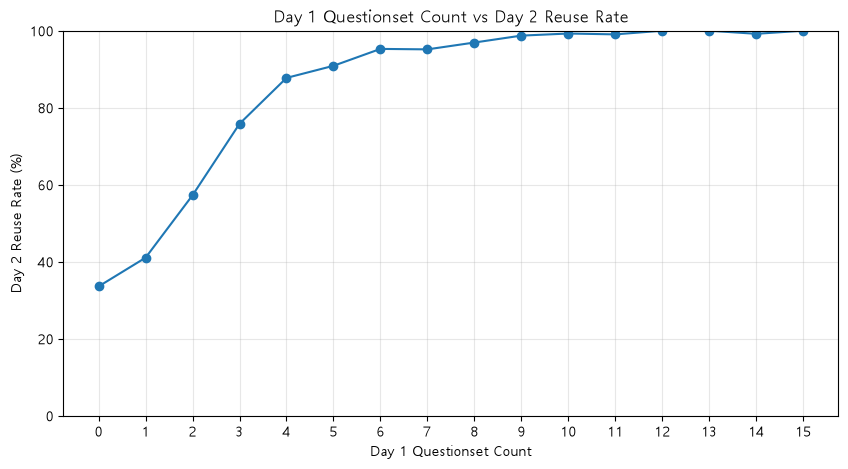

In [119]:
plot_day2 = day1_reuse[
    day1_reuse['day1'] <= 15
]

plt.figure(figsize=(10, 5))

plt.plot(
    plot_day2['day1'],
    plot_day2['day2_reuse_rate'],
    marker='o'
)

plt.xlabel('Day 1 Questionset Count')
plt.ylabel('Day 2 Reuse Rate (%)')
plt.title('Day 1 Questionset Count vs Day 2 Reuse Rate')

plt.xticks(plot_day2['day1'])
plt.ylim(0, 100)
plt.grid(alpha=0.3)

plt.show()

## 서비스 이용가능시점 이후 첫날 질문 세트 이용 수에 따른 2일차 전환율 확인 결과

- 0~6세트에서 2일차 재사용률이 33.6 → 41.0 → 57.3 → 75.8 → 87.7 → 90.9 → 95.3%로 점진적 상승.
- 6세트 이후부터는 거의 95~100%에서 유지

Day 1에 약 4~6세트 이상 경험한 구간부터 Day 2 재사용률의 추가 상승폭이 크게 둔화되는 형태로 보여지며, 6세트 이후 비교적 완만한 상승으로 진입하는 것으로 해석할 수 있다.

따라서, Day 1 질문세트 이용량과 Day 2 재사용 사이에 매우 강한 양의 관계가 관찰되지만 6세트를 경험했기 때문에 2일차에도 재이용했다고 보기에는 어렵다. 결과적으로 1차 아하모먼트 포인트는 첫날 4~6세트를 이용하는 지점으로 보류 후 3일차에서도 유사한 패턴이 보이는지를 추가확인하여 결정한다.

In [120]:
df_aha['day3_reused'] = df_aha['day3'] > 0

In [121]:
day1_day3_reuse = (
    df_aha
    .groupby('day1')
    .agg(
        users=('user_id', 'count'),
        day3_users=('day3_reused', 'sum'),
        day3_reuse_rate=('day3_reused', 'mean')
    )
    .reset_index()
)

day1_day3_reuse['day3_reuse_rate'] *= 100

day1_day3_reuse

,day1,users,day3_users,day3_reuse_rate
0,0,390,169,43.333333
1,1,324,138,42.592593
2,2,447,240,53.691275
3,3,393,272,69.211196
4,4,408,306,75.000000
5,5,428,366,85.514019
6,6,360,320,88.888889
7,7,413,359,86.924939
8,8,326,299,91.717791
9,9,315,283,89.841270


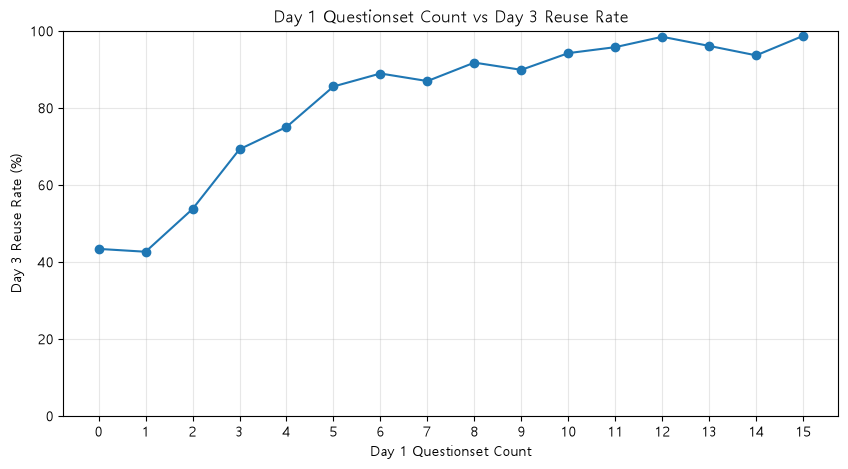

In [122]:
plot_day3 = day1_day3_reuse[
    day1_day3_reuse['day1'] <= 15
]

plt.figure(figsize=(10, 5))

plt.plot(
    plot_day3['day1'],
    plot_day3['day3_reuse_rate'],
    marker='o'
)

plt.xlabel('Day 1 Questionset Count')
plt.ylabel('Day 3 Reuse Rate (%)')
plt.title('Day 1 Questionset Count vs Day 3 Reuse Rate')

plt.xticks(plot_day3['day1'])
plt.ylim(0, 100)
plt.grid(alpha=0.3)

plt.show()

### 최종 판단
첫 이용 24시간 동안 더 많은 질문세트를 경험한 사용자일수록 Day 2·Day 3 질문 재사용률이 높게 관찰되며, 특히 약 3~6세트 구간에서 재사용률이 크게 상승한 뒤 높은 수준을 유지하는 패턴이 꾸준히 나타난다.

따라서, 현재 Aha Moment 1차 후보 범위 = 첫 24시간 질문세트 약 3~6회 정도로 잡아두고 이후 7일차 Retention을 확인해본다.

## 질문 콘텐츠 재사용기준 7일차 리텐션 확인
- 질문 콘텐츠 재사용 = 초기 경험 기간 이후 특정 기간에 최소 1회 이상 질문에 투표한 사용자

초기 경험량: 서비스 이용 가능 후 첫 24시간의 questionset 시작 횟수

단기 반복 사용: Day 2·Day 3의 questionset 재사용 여부

중기 재사용 검증: Day 7~13에 questionrecord가 1건 이상 존재하는지

In [123]:
# Day 7~13 questionrecord 재사용 만들기 준비

questionrecord_sql = f"""
SELECT
    user_id,
    created_at
FROM `{PROJECT_ID}.{DATA_SET}.accounts_userquestionrecord`
"""

questionrecord = client.query(
    questionrecord_sql
).to_dataframe()

questionrecord.info()

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


<class 'pandas.DataFrame'>
RangeIndex: 1217558 entries, 0 to 1217557
Data columns (total 2 columns):
 #   Column      Non-Null Count    Dtype              
---  ------      --------------    -----              
 0   user_id     1217558 non-null  Int64              
 1   created_at  1217558 non-null  datetime64[us, UTC]
dtypes: Int64(1), datetime64[us, UTC](1)
memory usage: 19.7 MB


In [124]:
# Day 7~13에 실제 투표 행동이 있었는지 데이터간 결합

qr_reuse = questionrecord.merge(
    df_aha[['user_id', 'question_start_at']],
    on='user_id',
    how='inner'
)

qr_reuse['hours_after_start'] = (
    qr_reuse['created_at']
    - qr_reuse['question_start_at']
).dt.total_seconds() / 3600

In [125]:
# Day 7~13 구간(168시간 이상 ~ 336시간 미만)에 실제 투표 기록이 하나라도 있는 유저를 추출

mid_reuse_users = (
    qr_reuse[
        (qr_reuse['hours_after_start'] >= 24 * 7)
        & (qr_reuse['hours_after_start'] < 24 * 14)
    ]['user_id']
    .unique()
)

df_aha['mid_reused'] = df_aha['user_id'].isin(mid_reuse_users)

print('분석 대상:', len(df_aha))
print('Day 7~13 질문 재사용 유저:', df_aha['mid_reused'].sum())
print(
    'Day 7~13 질문 재사용률:',
    round(df_aha['mid_reused'].mean() * 100, 2),
    '%'
)

분석 대상: 5032
Day 7~13 질문 재사용 유저: 3454
Day 7~13 질문 재사용률: 68.64 %


분석 대상 5,032명 중 3,454명(68.64%)이 서비스 이용 가능 시점으로부터 Day 7~13 사이에 최소 한 번 이상 실제 질문 투표 행동을 했다.

In [126]:
day1_mid_reuse = (
    df_aha
    .groupby('day1')
    .agg(
        users=('user_id', 'count'),
        mid_reuse_users=('mid_reused', 'sum'),
        mid_reuse_rate=('mid_reused', 'mean')
    )
    .reset_index()
)

day1_mid_reuse['mid_reuse_rate'] *= 100

day1_mid_reuse

,day1,users,mid_reuse_users,mid_reuse_rate
0,0,390,217,55.641026
1,1,324,152,46.91358
2,2,447,232,51.901566
3,3,393,263,66.92112
4,4,408,281,68.872549
5,5,428,298,69.626168
6,6,360,262,72.777778
7,7,413,308,74.576271
8,8,326,231,70.858896
9,9,315,229,72.698413


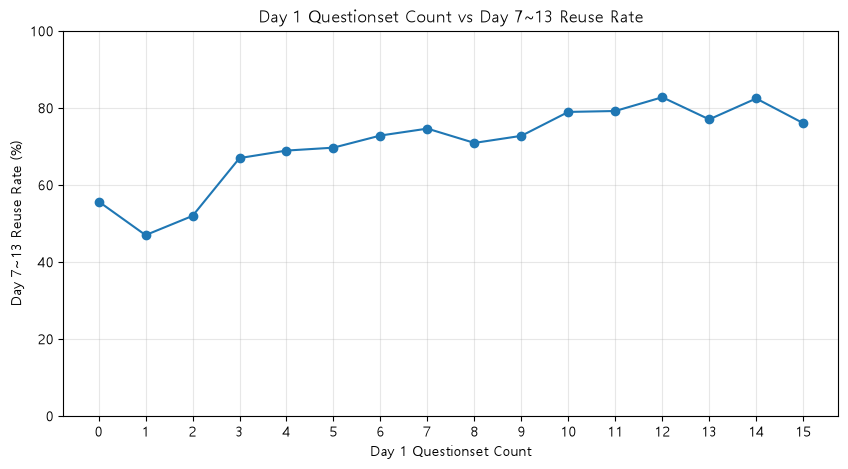

In [127]:
plot_mid = day1_mid_reuse[
    day1_mid_reuse['day1'] <= 15
]

plt.figure(figsize=(10, 5))

plt.plot(
    plot_mid['day1'],
    plot_mid['mid_reuse_rate'],
    marker='o'
)

plt.xlabel('Day 1 Questionset Count')
plt.ylabel('Day 7~13 Reuse Rate (%)')
plt.title('Day 1 Questionset Count vs Day 7~13 Reuse Rate')

plt.xticks(plot_mid['day1'])
plt.ylim(0, 100)
plt.grid(alpha=0.3)

plt.show()

## Aha Moment 탐색 방향 재정의

### 1. 기존 분석 방향

초기에는 서비스 이용 가능 시점을 기준으로 첫날 이용한 질문세트 수에 따라 이후 질문 기능 재사용률이 어떻게 달라지는지 확인하고, 재사용률이 뚜렷하게 상승하는 질문세트 이용 횟수를 Aha Moment 후보로 정의하고자 했다.

분석 결과 첫날 질문세트 이용량이 증가할수록 Day 2와 Day 3의 질문세트 재사용률은 전반적으로 상승했으며, 특히 약 3~6세트 구간 이후 높은 재사용률을 보였다.

이를 바탕으로 첫날 질문세트 이용 횟수의 특정 임계점을 Aha Moment 후보로 설정할 가능성을 검토하였다.


### 2. 방향을 재검토한 이유

단기 재사용에서는 첫날 질문세트 이용량과 비교적 뚜렷한 관계가 관찰되었지만, Day 7~13의 실제 질문 투표(questionrecord) 재사용률을 확인한 결과 이용 횟수 증가에 따른 전반적인 상승 경향은 존재하나 특정 질문세트 수를 명확한 임계점으로 판단하기에는 변동이 존재했다.

따라서 특정 N개의 질문세트를 이용한 것을 Aha Moment로 임의 정의하기보다는,

**"초기에 핵심 질문 기능을 어느 수준까지 경험했는가"**

를 기준으로 사용자를 구분하여 이후 행동 차이를 확인하는 방향이 더 적절하다고 판단하였다.


### 3. 변경된 분석 방향

서비스 이용 가능 후 첫 24시간의 질문세트 이용량을 기준으로 초기 핵심 기능 경험 수준을 구분한다.

- **미경험:** 질문세트 0회
- **단순 경험:** 질문세트 1~2회
- **반복 경험:** 질문세트 3회 이상

3회를 기준으로 구분하는 이유는 현재 분석에서 Day 1 질문세트 이용량이 2회에서 3회로 증가하는 구간부터 Day 2, Day 3 및 Day 7~13 재사용률이 비교적 크게 상승하는 패턴이 관찰되었기 때문이다.

단, 현재 단계에서는 3회를 Aha Moment로 확정하지 않고 **초기 반복 경험을 구분하기 위한 탐색적 기준**으로 사용한다.


### 4. 이후 분석 계획

각 초기 경험 집단별로 다음 행동 지표를 비교한다.

1. Day 2 질문세트 재사용률
2. Day 3 질문세트 재사용률
3. Day 7~13 실제 질문 투표(questionrecord) 재사용률
4. 이후 결제 경험률

이를 통해 다음을 확인한다.

- 단순히 핵심 기능에 한 번 진입하는 것이 중요한가?
- 초기 질문 기능을 반복적으로 경험하는 것이 중요한가?
- 초기 반복 경험과 이후 재사용 및 결제 행동 사이에 일관된 관계가 나타나는가?

여러 후속 지표에서 반복 경험 집단의 행동이 일관되게 높게 나타난다면, 이를 기반으로 서비스의 Aha Moment 후보를 정의한다.

## 변경된 탐색 방향에 따른 분석

In [128]:
# 경험 수준 변수

conditions = [
    df_aha['day1'] == 0,
    df_aha['day1'].between(1, 2),
    df_aha['day1'] >= 3
]

choices = [
    '미경험',
    '단순 경험',
    '반복 경험'
]

df_aha['initial_experience'] = np.select(
    conditions,
    choices,
    default='확인 필요'
)

df_aha['initial_experience'].value_counts()

initial_experience
반복 경험    3871
단순 경험     771
미경험       390
Name: count, dtype: int64

In [129]:
(
    df_aha['initial_experience']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

initial_experience
반복 경험    76.93
단순 경험    15.32
미경험       7.75
Name: proportion, dtype: float64

- 미경험: 390명, 7.75%
- 단순 경험: 771명, 15.32%
- 반복 경험: 3,871명, 76.93%

In [130]:
experience_reuse = (
    df_aha
    .groupby('initial_experience')
    .agg(
        users=('user_id', 'count'),
        day2_reuse_rate=('day2_reused', 'mean'),
        day3_reuse_rate=('day3_reused', 'mean'),
        mid_reuse_rate=('mid_reused', 'mean')
    )
    .reset_index()
)

rate_cols = [
    'day2_reuse_rate',
    'day3_reuse_rate',
    'mid_reuse_rate'
]

experience_reuse[rate_cols] = (
    experience_reuse[rate_cols] * 100
).round(2)

experience_reuse

,initial_experience,users,day2_reuse_rate,day3_reuse_rate,mid_reuse_rate
0,단순 경험,771,50.45,49.03,49.81
1,미경험,390,33.59,43.33,55.64
2,반복 경험,3871,93.77,87.39,73.7


### 미경험 유저의 역전현상 관찰
- 단순 경험 (1일차 1~2회 질문세트 시작)
 : 유저의 경우 지속적으로 전환율이 소폭 하락 후 7~13일차 유지율의 경우 약 49.81%

- 미경험 (1일차 0회 질문세트 시작)
 : 해당 유지율이 상승하는 경향이 관찰된 것으로 볼 때, 첫날 이용하지 않았지만 이후 지연되어 이용을 시작한 유저들이 있을 가능성을 시사한다.

- 반복 경험 (1일차 3회이상 질문세트 시작)
 : 지속적으로 유지율이 하락하지만 첫날 반복경험 3회 이상 진행하는 유저의 수가 많고, 이용일이 길어질수록 낮아지는 이상적인 추이로 관찰됨.

In [131]:
df_repeat = df_aha[
    df_aha['day1'] >= 3
].copy()

df_repeat['repeat_level'] = pd.cut(
    df_repeat['day1'],
    bins=[3, 6, 10, float('inf')],
    labels=['3~5회', '6~9회', '10회 이상'],
    right=False
)

df_repeat['repeat_level'].value_counts().sort_index()

repeat_level
3~5회      1229
6~9회      1414
10회 이상    1228
Name: count, dtype: int64

In [132]:
repeat_reuse = (
    df_repeat
    .groupby('repeat_level', observed=True)
    .agg(
        users=('user_id', 'count'),
        day2_reuse_rate=('day2_reused', 'mean'),
        day3_reuse_rate=('day3_reused', 'mean'),
        mid_reuse_rate=('mid_reused', 'mean')
    )
    .reset_index()
)

rate_cols = [
    'day2_reuse_rate',
    'day3_reuse_rate',
    'mid_reuse_rate'
]

repeat_reuse[rate_cols] = (
    repeat_reuse[rate_cols] * 100
).round(2)

repeat_reuse

,repeat_level,users,day2_reuse_rate,day3_reuse_rate,mid_reuse_rate
0,3~5회,1229,85.03,76.81,68.51
1,6~9회,1414,96.39,89.18,72.84
2,10회 이상,1228,99.51,95.93,79.89


### 최종 판단.

첫 24시간 내 3회 이상 질문세트를 반복 경험한 시점부터 이후 재사용이 뚜렷하게 높은 집단으로 구분되며, 이후 경험량이 많을수록 재사용률도 추가적으로 높아지는 경향이 관찰된다.

따라서, Aha Moment 1차 후보를 서비스 이용 가능 후 첫 24시간 내 질문세트 3회 이상 경험으로 고정하고 다음 검증으로 넘어간다.

### 유지에 해당 기준이 정말 유의미한가? (통계검정)

In [133]:
# 기준 적용시 그룹의 유저 수

df_aha['aha_reached'] = df_aha['day1'] >= 3

df_aha['aha_reached'].value_counts()

aha_reached
True     3871
False    1161
Name: count, dtype: int64

In [134]:
aha_group = df_aha[df_aha['aha_reached']]
non_aha_group = df_aha[~df_aha['aha_reached']]

print(
    'Aha 도달:',
    len(aha_group),
    '명 / Week2 재사용:',
    aha_group['mid_reused'].sum(),
    '명'
)

print(
    'Aha 미도달:',
    len(non_aha_group),
    '명 / Week2 재사용:',
    non_aha_group['mid_reused'].sum(),
    '명'
)

Aha 도달: 3871 명 / Week2 재사용: 2853 명
Aha 미도달: 1161 명 / Week2 재사용: 601 명


- 귀무가설 : 첫 24시간 질문세트 3회 이상 경험 집단과 0~2회 집단의 Week2 질문 재사용률은 같다.
- 대립가설 : 두 집단의 Week2 질문 재사용률은 다르다.

In [135]:
# 각 집단의 Week2 재사용자 수
count = [
    aha_group['mid_reused'].sum(),
    non_aha_group['mid_reused'].sum()
]

# 각 집단의 전체 사용자 수
nobs = [
    len(aha_group),
    len(non_aha_group)
]

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative='two-sided'
)

print(f'Z-statistic: {round(z_stat, 3)}')
print(f'p-value: {p_value:.3f}')

Z-statistic: 14.13
p-value: 0.000


첫 24시간 내 questionset을 3회 이상 경험한 집단은 0~2회 집단보다 Week2(7~13일차) 질문 재사용률이 약 21.9%p 높았으며, 모비율 Z검정 결과 이 차이는 통계적으로 유의했다(Z=14.13, p<0.001).

“3회 이상 경험 집단의 재사용률이 미도달 집단의 약 1.42배로 관찰됐다.”

# 서비스 이용시점에 따른 차이가 아하모먼트 도달과 관련이 있는가?

In [136]:
access_aha = pd.crosstab(
    df_aha['initial_experience'],
    df_aha['service_access_status'],
    margins=True
)

access_aha

service_access_status,available_at_signup,available_later,All
initial_experience,,,
단순 경험,645,126,771
미경험,195,195,390
반복 경험,3121,750,3871
All,3961,1071,5032


In [137]:
# 기존 교차표 복사
access_aha_summary = access_aha.copy()

# 각 경험 집단 내 비율 계산
access_aha_summary['signup_rate'] = (
    access_aha_summary['available_at_signup']
    / access_aha_summary['All'] * 100
).round(2)

access_aha_summary['later_rate'] = (
    access_aha_summary['available_later']
    / access_aha_summary['All'] * 100
).round(2)

# 보기 좋은 컬럼 순서
access_aha_summary = access_aha_summary[
    [
        'available_at_signup',
        'signup_rate',
        'available_later',
        'later_rate',
        'All'
    ]
]

access_aha_summary

service_access_status,available_at_signup,signup_rate,available_later,later_rate,All
initial_experience,,,,,
단순 경험,645,83.66,126,16.34,771
미경험,195,50.00,195,50.00,390
반복 경험,3121,80.63,750,19.37,3871
All,3961,78.72,1071,21.28,5032


## 각 그룹별 즉시 이용가능과 즉시 이용 불가능의 차이 확인 결과.

- 10개 학교 대상 전체에서 가입즉시 사용할 수 없었던 유저가 약 21%로 전체 5,032명 중 1,071명이 가입 즉시 이용할 수 없었던 인원으로 확인.
- 각 그룹 중 아하모먼트에 도달하지 못한 비율로 볼 때 '미경험' 그룹에서 약 50%는 가입 즉시 사용할 수 없었던 그룹으로 확인된다.

따라서, 서비스 이용 지연은 ‘3회까지 반복하지 못하는 문제’보다는, 애초에 첫 질문 경험 자체에 진입하지 못하는 문제와 더 관련이 있을 가능성이 있다.

In [138]:
# 유저별 최초 questionset 기록 시점
first_question = (
    questionset
    .groupby('user_id')['opening_time']
    .min()
    .reset_index(name='first_question_at')
)

# 첫 24시간 미경험 유저만 추출
no_initial = df_aha[
    df_aha['day1'] == 0
].copy()

# 최초 questionset 시점 연결
no_initial = no_initial.merge(
    first_question,
    on='user_id',
    how='left'
)

print('첫 24시간 미경험 유저:', len(no_initial))
print('이후 questionset 경험 유저:', no_initial['first_question_at'].notna().sum())
print('끝까지 questionset 기록 없는 유저:', no_initial['first_question_at'].isna().sum())

첫 24시간 미경험 유저: 390
이후 questionset 경험 유저: 285
끝까지 questionset 기록 없는 유저: 105


In [139]:
no_initial['later_experience'] = np.where(
    no_initial['first_question_at'].notna(),
    '이후 경험',
    '관측기간 내 미경험'
)

pd.crosstab(
    no_initial['service_access_status'],
    no_initial['later_experience'],
    margins=True
)

later_experience,관측기간 내 미경험,이후 경험,All
service_access_status,,,
available_at_signup,91,104,195
available_later,14,181,195
All,105,285,390


- 정상 이용 가능 시점부터 24시간 내 질문세트를 경험하지 않은 유저만을 대상으로 이후 경험을하는 비율은 어떠한지 그룹별 확인함.
- 가입당시 즉시 이용이 가능했던 유저 그룹 중 24시간 내 경험하지 않은 유저들은 195명 중 104명이 이후에 경험을 하였다.
- 가입당시 즉시 이용이 불가능했던 유저 그룹의 경우 24시간내 경험하지 않은 유저들은 195명 중 181명이 이후에 경험을 하였다.

이외 약 105명은 현재 가진 데이터의 기간동안 수집된 질문 세트 테이블에서는 경험기록이 없는 유저이다.

따라서, 가입 당시 이용 불가가 ‘첫 24시간 미경험’에는 관련되어 보이지만, 장기적인 미경험으로 이어진다고 보기는 어렵다

단, “서비스 이용 제한은 초기 핵심 기능 경험 시점을 지연시키며, 이에 따라 Aha Moment 도달 및 수익화 기회의 발생 시점 역시 지연될 가능성은 여전히 있다.”

## 관측기간이 부족하여 90명의 유저가 기록이 없는가?

In [140]:
# questionset에 학교 정보 연결
question_with_school = questionset.merge(
    df_aha[['user_id', 'school_id']],
    on='user_id',
    how='left'
)

# 학교별 questionset 마지막 관측 시점
school_question_end = (
    question_with_school
    .groupby('school_id')['opening_time']
    .max()
    .reset_index(name='question_data_end')
)

# 가입 즉시 이용 가능 + 첫 24시간 미경험 유저
immediate_no_initial = no_initial[
    no_initial['service_access_status'] == 'available_at_signup'
].copy()

# 학교별 데이터 종료 시점 연결
immediate_no_initial = immediate_no_initial.merge(
    school_question_end,
    on='school_id',
    how='left'
)

# 서비스 이용 가능 시점부터 데이터 종료까지 관측 가능한 기간
immediate_no_initial['followup_days'] = (
    immediate_no_initial['question_data_end']
    - immediate_no_initial['question_start_at']
).dt.total_seconds() / (60 * 60 * 24)

immediate_no_initial.groupby('later_experience')['followup_days'].describe()

,count,mean,std,min,25%,50%,75%,max
later_experience,,,,,,,,
관측기간 내 미경험,91.0,315.957112,79.275232,-35.825976,317.514815,334.958357,348.352125,369.210039
이후 경험,104.0,342.116068,20.493101,264.232158,329.911483,347.599863,358.572312,368.954857


즉시 이용 가능했음에도 첫 24시간 질문을 경험하지 않은 유저 중 91명은 이후에도 questionset 경험 기록이 확인되지 않았다. 이들의 서비스 이용 가능 시점부터 해당 학교의 마지막 questionset 활동까지 평균 약 316일의 간격이 존재해, 단순한 짧은 관측기간 때문에 미경험으로 분류되었을 가능성은 낮아 보인다. 따라서 이 집단은 질문 서비스에 장기간 진입하지 않았거나 서비스에서 이탈했을 가능성이 높은 집단으로 볼 수 있다.

이탈 유저로 볼 수 없는 이유는 해당 91명의 유저들이 다른 기능은 이용했을 가능성이 있기 때문이다.

# Acquisition 아이디어 흐름

In [141]:
group_signup = (
    df[['user_id', 'group_id', 'signup_at']]
    .dropna(subset=['group_id', 'signup_at'])
    .sort_values(['group_id', 'signup_at'])
    .copy()
)

# 그룹 내 가입 순서
group_signup['signup_order'] = (
    group_signup
    .groupby('group_id')
    .cumcount() + 1
)

group_signup[
    ['group_id', 'user_id', 'signup_at', 'signup_order']
].head(20)

,group_id,user_id,signup_at,signup_order
1,1,832151,2023-03-29 12:56:34.989468+00:00,1
2,1,832340,2023-03-29 12:56:35.020790+00:00,2
7,1,832894,2023-03-29 13:20:46.469788+00:00,3
8,1,832920,2023-03-29 13:20:46.476550+00:00,4
49,1,834358,2023-04-03 10:37:13.518521+00:00,5
50,1,834415,2023-04-03 13:46:26.975614+00:00,6
52,1,834486,2023-04-03 15:24:39.321432+00:00,7
53,1,834643,2023-04-03 17:56:20.517353+00:00,8
97,1,836496,2023-04-15 07:08:25.083431+00:00,9
98,1,836498,2023-04-15 07:13:58.409045+00:00,10


In [142]:
# 같은 그룹의 이전 가입자 가입 시점
group_signup['prev_signup_at'] = (
    group_signup
    .groupby('group_id')['signup_at']
    .shift(1)
)

# 이전 가입 이후 현재 가입까지 걸린 시간
group_signup['signup_gap_hours'] = (
    group_signup['signup_at']
    - group_signup['prev_signup_at']
).dt.total_seconds() / 3600

In [143]:
group_signup[
    ['group_id', 'signup_order', 'signup_at',
     'prev_signup_at', 'signup_gap_hours']
].head(20)

,group_id,signup_order,signup_at,prev_signup_at,signup_gap_hours
1,1,1,2023-03-29 12:56:34.989468+00:00,NaT,NaN
2,1,2,2023-03-29 12:56:35.020790+00:00,2023-03-29 12:56:34.989468+00:00,0.000009
7,1,3,2023-03-29 13:20:46.469788+00:00,2023-03-29 12:56:35.020790+00:00,0.403180
8,1,4,2023-03-29 13:20:46.476550+00:00,2023-03-29 13:20:46.469788+00:00,0.000002
49,1,5,2023-04-03 10:37:13.518521+00:00,2023-03-29 13:20:46.476550+00:00,117.274178
50,1,6,2023-04-03 13:46:26.975614+00:00,2023-04-03 10:37:13.518521+00:00,3.153738
52,1,7,2023-04-03 15:24:39.321432+00:00,2023-04-03 13:46:26.975614+00:00,1.636763
53,1,8,2023-04-03 17:56:20.517353+00:00,2023-04-03 15:24:39.321432+00:00,2.528110
97,1,9,2023-04-15 07:08:25.083431+00:00,2023-04-03 17:56:20.517353+00:00,277.201268
98,1,10,2023-04-15 07:13:58.409045+00:00,2023-04-15 07:08:25.083431+00:00,0.092590


In [144]:
signup_gap_summary = (
    group_signup[
        group_signup['signup_order'].between(2, 15)
    ]
    .groupby('signup_order')
    .agg(
        groups=('group_id', 'nunique'),
        median_gap_hours=('signup_gap_hours', 'median'),
        mean_gap_hours=('signup_gap_hours', 'mean')
    )
    .reset_index()
)

signup_gap_summary

,signup_order,groups,median_gap_hours,mean_gap_hours
0,2,68570,17.017961,77.160143
1,3,61885,6.148844,46.439360
2,4,56960,4.067068,37.022890
3,5,52814,3.531322,33.566104
4,6,48978,3.477592,32.985556
5,7,45282,3.694068,32.500824
6,8,41514,4.243479,38.541863
7,9,37557,4.635267,43.780819
8,10,33616,5.507282,47.536819
9,11,29477,6.664355,57.738376


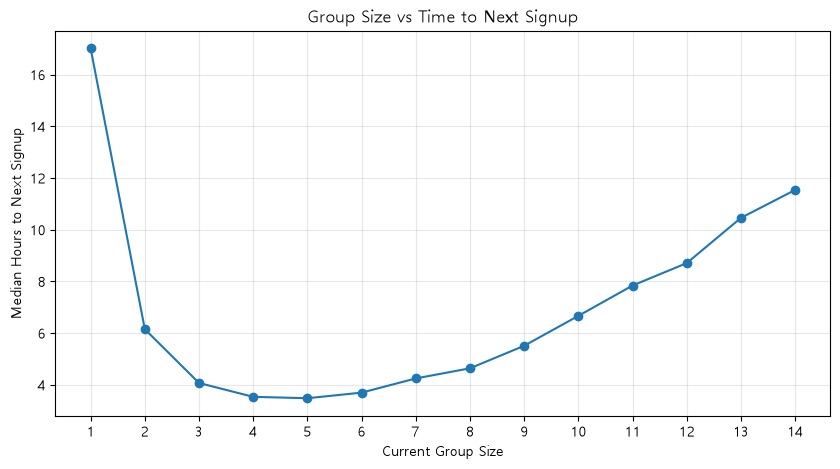

In [145]:
plot_gap = signup_gap_summary.copy()

plot_gap['current_group_size'] = plot_gap['signup_order'] - 1

plt.figure(figsize=(10, 5))

plt.plot(
    plot_gap['current_group_size'],
    plot_gap['median_gap_hours'],
    marker='o'
)

plt.xlabel('Current Group Size')
plt.ylabel('Median Hours to Next Signup')
plt.title('Group Size vs Time to Next Signup')

plt.xticks(plot_gap['current_group_size'])
plt.grid(alpha=0.3)

plt.show()

재 그룹 인원이 1명일 때 다음 유저 가입까지 중앙값 약 17시간이 걸리지만, 인원이 증가하면서 가입 간격이 빠르게 감소하여 현재 5명일 때 약 3.48시간으로 최저점을 기록한다. 이후 6명 이상부터는 가입 간격이 다시 증가하는 패턴이 관찰된다.

초기 그룹 형성 구간이 가장 큰 유입 마찰 구간이며, 충분한 인원이 확보되기 전까지 핵심 서비스 경험에도 제약이 발생한다.

첫 번째 친구 초대 성공 → 기본 보상
두 번째 친구 초대 성공 → 추가 보상
세 번째 친구 초대 성공 → 더 높은 보상
→ 핵심 기능 이용 가능 인원 달성 시 보너스

초기 그룹 형성 구간에서 가입 간격이 가장 크게 나타났으며, 핵심 기능 이용에도 최소 인원이 요구된다. 따라서 초기 그룹 형성을 가속하기 위해 목표 인원 달성에 가까워질수록 초대 보상을 차등 제공하는 프로모션을 제안할 수 있다. 효과는 A/B Test를 통해 검증할 필요가 있다.

추가적으로 해당 프로세스를 진행시 초대유저들은 보상받은 포인트를 사용하며 힌트, 채팅방 개설등의 경험을 통해 자연스럽게 해당 서비스에도 안착시킬 수 있을 것으로 보임

# 가입즉시 이용 가능 그룹의 미경험 원인 탐색

In [146]:
no_question_91 = immediate_no_initial[
    immediate_no_initial['later_experience'] == '관측기간 내 미경험'
].copy()

print('분석 대상:', len(no_question_91))

no_question_91[
    ['user_id', 'signup_at', 'school_id', 'group_id', 'payment_count']
].head()

분석 대상: 91


,user_id,signup_at,school_id,group_id,payment_count
4,861900,2023-04-30 16:38:03.655030+00:00,271,233,0
6,865922,2023-05-01 12:54:05.690671+00:00,271,5154,0
7,866576,2023-05-01 13:59:08.734822+00:00,271,4763,0
9,874556,2023-05-03 06:35:52.663311+00:00,4516,9395,0
11,875465,2023-05-03 10:17:16.017117+00:00,369,9902,0


In [147]:
no_question_91['payment_count'].value_counts()

payment_count
0    91
Name: count, dtype: Int64

In [148]:
friend_df.shape

(4333, 3)

In [149]:
target_ids = immediate_no_initial['user_id'].tolist()

len(target_ids)

195

In [150]:
friend_sql = f"""
SELECT
    id AS user_id,
    friend_id_list
FROM `{PROJECT_ID}.{DATA_SET}.accounts_user`
WHERE id IN ({','.join(map(str, target_ids))})
"""

friend_195 = client.query(friend_sql).to_dataframe()

print(len(friend_195))
friend_195.head()

195


c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,user_id,friend_id_list
0,1430554,"[1448337, 1453688, 1461877, 1468918, 1473020, ..."
1,1062907,"[1163745, 1079202, 1163115, 1070252, 1276332, ..."
2,955746,"[877228, 894723, 911652, 1026598, 841333, 8851..."
3,1240947,"[1256576, 1209858, 1234051, 1362180, 1220230, ..."
4,937936,"[1113857, 853379, 1140485, 1164422, 1166092, 9..."


In [151]:
# 친구 수 계산
friend_195['friend_count'] = friend_195['friend_id_list'].apply(len)

# 91명 / 104명 구분값 붙이기
friend_compare = immediate_no_initial[
    ['user_id', 'later_experience']
].merge(
    friend_195[['user_id', 'friend_count']],
    on='user_id',
    how='left'
)

friend_compare.groupby('later_experience')['friend_count'].describe()

,count,mean,std,min,25%,50%,75%,max
later_experience,,,,,,,,
관측기간 내 미경험,91.0,136.956044,139.316818,2.0,18.00,99.0,221.5,744.0
이후 경험,104.0,423.509615,323.666195,24.0,215.75,338.5,503.0,1694.0


## 원인 탐색 결과

가입 즉시 서비스 이용이 가능했지만 질문 기능을 지속적으로 경험하지 않은 유저는, 이후 질문을 경험한 유저보다 친구 관계망 규모가 작은 경향이 관찰되었다. 이는 핵심 기능 진입과 서비스 내 관계망 형성 수준이 연관될 가능성을 시사하지만, 친구 관계 형성과 질문 경험의 시간적 선후관계가 확인되지 않아 인과관계로 해석할 수는 없다.

# 질문 경험을 했지만 왜 3회이상까지 가지 못했을까?

In [152]:
df_aha[
    df_aha['day1'].between(1, 2)
]['day1'].value_counts().sort_index()

day1
1    324
2    447
Name: count, dtype: int64

In [153]:
questionset.columns

Index(['user_id', 'opening_time'], dtype='str')

In [154]:
first_q_time = (
    question_daily[
        (question_daily['hours_after_start'] >= 0) &
        (question_daily['hours_after_start'] < 24)
    ]
    .groupby('user_id')['opening_time']
    .min()
    .reset_index(name='first_question_time')
)

first_q_time['first_question_hour'] = (
    first_q_time['first_question_time'].dt.hour
)

first_q_time.head()

,user_id,first_question_time,first_question_hour
0,838023,2023-04-29 10:02:26+00:00,10
1,838466,2023-05-03 01:35:07+00:00,1
2,838642,2023-04-28 14:17:23+00:00,14
3,839357,2023-04-30 01:42:37+00:00,1
4,840293,2023-05-03 02:23:57+00:00,2


In [155]:
time_compare = df_aha[
    df_aha['day1'] >= 1
][['user_id', 'day1']].copy()

time_compare['experience_group'] = np.where(
    time_compare['day1'].between(1, 2),
    '1~2회',
    '3회 이상'
)

time_compare = time_compare.merge(
    first_q_time[['user_id', 'first_question_hour']],
    on='user_id',
    how='left'
)

time_compare.groupby('experience_group')['first_question_hour'].describe()

,count,mean,std,min,25%,50%,75%,max
experience_group,,,,,,,,
1~2회,771.0,11.102464,5.24106,0.0,8.0,12.0,14.0,23.0
3회 이상,3871.0,10.471971,5.06196,0.0,7.0,11.0,14.0,23.0


가설: 질문 이용 시간대가 반복 경험에 영향을 주는가?
첫 24시간 1~2회 경험 집단과 3회 이상 경험 집단의 최초 질문 이용 시간을 비교한 결과, 중앙값은 각각 12시와 11시로 큰 차이가 관찰되지 않았다. 따라서 최초 이용 시간대가 3회 이상 반복 경험 도달 여부를 설명하는 주요 요인이라는 근거는 확인되지 않았다.

In [156]:
questionrecord.columns

Index(['user_id', 'created_at'], dtype='str')

## 초기 질문 경험 과정에서 투표에 대한 답장을 받는 것이 이후 반복 질문 경험과 관련 있는가?

In [157]:
questionrecord_detail_sql = f"""
SELECT
    user_id,
    chosen_user_id,
    answer_status,
    answer_updated_at,
    created_at
FROM `{PROJECT_ID}.{DATA_SET}.accounts_userquestionrecord`
"""

questionrecord_detail = client.query(
    questionrecord_detail_sql
).to_dataframe()

questionrecord_detail.head()

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,user_id,chosen_user_id,answer_status,answer_updated_at,created_at
0,851717,849995,P,2023-05-06 10:31:30+00:00,2023-04-29 13:22:05+00:00
1,849450,849922,N,2023-04-29 14:49:06+00:00,2023-04-29 14:49:06+00:00
2,850229,850031,N,2023-04-30 03:29:48+00:00,2023-04-30 03:29:48+00:00
3,857422,856172,N,2023-04-30 07:43:10+00:00,2023-04-30 07:43:10+00:00
4,855117,855039,N,2023-04-30 07:58:36+00:00,2023-04-30 07:58:36+00:00


In [158]:
questionrecord_detail[
    ['answer_status', 'answer_updated_at']
].groupby('answer_status').agg(
    count=('answer_status', 'size'),
    answer_time_count=('answer_updated_at', 'count')
)

,count,answer_time_count
answer_status,,
A,111761,111761
N,1097932,1097932
P,7865,7865


In [159]:
answered = questionrecord_detail[
    questionrecord_detail['answer_status'].isin(['A', 'P'])
].copy()

answered['answer_delay_hours'] = (
    answered['answer_updated_at'] - answered['created_at']
).dt.total_seconds() / 3600

answered['answer_delay_hours'].describe()

count    119626.000000
mean          9.027282
std          27.163911
min           0.001667
25%           0.155556
50%           1.186111
75%           6.785208
max         794.428889
Name: answer_delay_hours, dtype: float64

In [160]:
answered['within_24h'] = answered['answer_delay_hours'] <= 24

answered['within_24h'].value_counts()

within_24h
True     109547
False     10079
Name: count, dtype: int64

In [161]:
answered['within_24h'].value_counts(normalize=True) * 100

within_24h
True     91.574574
False     8.425426
Name: proportion, dtype: float64

ping을 보낸 후 답장이 24시간 이내에 이루어지는 경우의 비율이 높다.

즉, 대부분의 유저들이 24시간이내에 답변을 받는다.

그렇다면 초기 질문 발송시 답변을 받는 행동이 반복경험에 영향이 있는가 추가 검증을 진행해본다.

In [162]:
questionset_detail_sql = f"""
SELECT
    user_id,
    opening_time,
    question_piece_id_list
FROM `{PROJECT_ID}.{DATA_SET}.polls_questionset`
"""

questionset_detail = client.query(
    questionset_detail_sql
).to_dataframe()

questionset_detail.head()

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,user_id,opening_time,question_piece_id_list
0,841333,2023-05-17 00:22:16+00:00,"[79931958, 79931960, 79931962, 79931966, 79931..."
1,845326,2023-05-17 09:54:57+00:00,"[82989582, 82989587, 82989592, 82989596, 82989..."
2,847375,2023-07-29 16:13:18+00:00,"[206172781, 206172782, 206172783, 206172784, 2..."
3,849438,2023-06-16 15:13:10+00:00,"[200176841, 200176842, 200176843, 200176844, 2..."
4,849451,2023-08-10 09:20:44+00:00,"[206737491, 206737492, 206737493, 206737494, 2..."


In [163]:
questionset_detail.info()

<class 'pandas.DataFrame'>
RangeIndex: 158384 entries, 0 to 158383
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   user_id                 158384 non-null  Int64              
 1   opening_time            158384 non-null  datetime64[us, UTC]
 2   question_piece_id_list  158384 non-null  str                
dtypes: Int64(1), datetime64[us, UTC](1), str(1)
memory usage: 19.1 MB


In [164]:
questionset_detail['question_piece_ids'] = (
    questionset_detail['question_piece_id_list']
    .apply(ast.literal_eval)
)

questionset_detail[
    ['question_piece_id_list', 'question_piece_ids']
].head()

,question_piece_id_list,question_piece_ids
0,"[79931958, 79931960, 79931962, 79931966, 79931...","[79931958, 79931960, 79931962, 79931966, 79931..."
1,"[82989582, 82989587, 82989592, 82989596, 82989...","[82989582, 82989587, 82989592, 82989596, 82989..."
2,"[206172781, 206172782, 206172783, 206172784, 2...","[206172781, 206172782, 206172783, 206172784, 2..."
3,"[200176841, 200176842, 200176843, 200176844, 2...","[200176841, 200176842, 200176843, 200176844, 2..."
4,"[206737491, 206737492, 206737493, 206737494, 2...","[206737491, 206737492, 206737493, 206737494, 2..."


In [165]:
questionset_exploded = (
    questionset_detail
    .explode('question_piece_ids')
    .rename(columns={'question_piece_ids': 'question_piece_id'})
)

questionset_exploded.head()

,user_id,opening_time,question_piece_id_list,question_piece_id
0,841333,2023-05-17 00:22:16+00:00,"[79931958, 79931960, 79931962, 79931966, 79931...",79931958
0,841333,2023-05-17 00:22:16+00:00,"[79931958, 79931960, 79931962, 79931966, 79931...",79931960
0,841333,2023-05-17 00:22:16+00:00,"[79931958, 79931960, 79931962, 79931966, 79931...",79931962
0,841333,2023-05-17 00:22:16+00:00,"[79931958, 79931960, 79931962, 79931966, 79931...",79931966
0,841333,2023-05-17 00:22:16+00:00,"[79931958, 79931960, 79931962, 79931966, 79931...",79931969


In [166]:
first_questionset = (
    questionset_detail
    .sort_values(['user_id', 'opening_time'])
    .groupby('user_id')
    .first()
    .reset_index()
)

first_questionset.head()

,user_id,opening_time,question_piece_id_list,question_piece_ids
0,838023,2023-04-29 10:02:26+00:00,"[1167328, 1167329, 1167330, 1167331, 1167332, ...","[1167328, 1167329, 1167330, 1167331, 1167332, ..."
1,838466,2023-05-02 22:41:59+00:00,"[3059298, 3059299, 3059300, 3059301, 3059302, ...","[3059298, 3059299, 3059300, 3059301, 3059302, ..."
2,838642,2023-04-28 14:17:23+00:00,"[1023128, 1023129, 1023130, 1023131, 1023132, ...","[1023128, 1023129, 1023130, 1023131, 1023132, ..."
3,839357,2023-04-29 16:50:47+00:00,"[1338618, 1338619, 1338620, 1338621, 1338622, ...","[1338618, 1338619, 1338620, 1338621, 1338622, ..."
4,840293,2023-05-03 02:23:57+00:00,"[3154458, 3154459, 3154460, 3154461, 3154462, ...","[3154458, 3154459, 3154460, 3154461, 3154462, ..."


In [167]:
first_questionset_exploded = (
    first_questionset
    .explode('question_piece_ids')
    .rename(columns={'question_piece_ids': 'question_piece_id'})
)

first_questionset_exploded.head()

,user_id,opening_time,question_piece_id_list,question_piece_id
0,838023,2023-04-29 10:02:26+00:00,"[1167328, 1167329, 1167330, 1167331, 1167332, ...",1167328
0,838023,2023-04-29 10:02:26+00:00,"[1167328, 1167329, 1167330, 1167331, 1167332, ...",1167329
0,838023,2023-04-29 10:02:26+00:00,"[1167328, 1167329, 1167330, 1167331, 1167332, ...",1167330
0,838023,2023-04-29 10:02:26+00:00,"[1167328, 1167329, 1167330, 1167331, 1167332, ...",1167331
0,838023,2023-04-29 10:02:26+00:00,"[1167328, 1167329, 1167330, 1167331, 1167332, ...",1167332


In [168]:
print('유저 수:', first_questionset_exploded['user_id'].nunique())
print('행 수:', len(first_questionset_exploded))

유저 수: 4972
행 수: 49720


In [169]:
questionrecord_detail_sql = f"""
SELECT
    user_id,
    chosen_user_id,
    question_piece_id,
    answer_status,
    answer_updated_at,
    created_at
FROM `{PROJECT_ID}.{DATA_SET}.accounts_userquestionrecord`
"""

questionrecord_detail = client.query(
    questionrecord_detail_sql
).to_dataframe()

questionrecord_detail.columns

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Index(['user_id', 'chosen_user_id', 'question_piece_id', 'answer_status',
       'answer_updated_at', 'created_at'],
      dtype='str')

In [170]:
first_q_reply = first_questionset_exploded.merge(
    questionrecord_detail[
        ['user_id', 'question_piece_id',
         'answer_status', 'answer_updated_at', 'created_at']
    ],
    on=['user_id', 'question_piece_id'],
    how='left',
    indicator=True
)

first_q_reply['_merge'].value_counts()

_merge
both          29225
left_only     20495
right_only        0
Name: count, dtype: int64

In [171]:
print(
    '매칭된 유저 수:',
    first_q_reply.loc[
        first_q_reply['_merge'] == 'both',
        'user_id'
    ].nunique()
)

매칭된 유저 수: 4532


In [172]:
# 경험 집단 붙이기
reply_check = first_q_reply.merge(
    df_aha[['user_id', 'day1']],
    on='user_id',
    how='inner'
)

reply_check['experience_group'] = np.where(
    reply_check['day1'].between(1, 2),
    '1~2회',
    '3회 이상'
)

# 유저별 첫 questionset에서 questionrecord 매칭 여부
user_match = (
    reply_check
    .groupby(['user_id', 'experience_group'])['_merge']
    .apply(lambda x: (x == 'both').any())
    .reset_index(name='has_questionrecord')
)

pd.crosstab(
    user_match['experience_group'],
    user_match['has_questionrecord'],
    normalize='index'
) * 100

has_questionrecord,False,True
experience_group,,
1~2회,20.622568,79.377432
3회 이상,6.544755,93.455245


3회 이상 반복 경험 집단은 1~2회 집단보다 첫 questionset에서 실제 투표 기록이 생성된 비율이 높았다(93.5% vs 79.4%). 즉, 단순히 questionset을 열어본 것뿐 아니라 첫 경험에서 실제 질문 행동까지 이어지는 정도가 이후 반복 경험과 연관되어 있을 가능성이 있다.

In [173]:
# 실제 questionrecord가 있는 행만
matched_reply = reply_check[
    reply_check['_merge'] == 'both'
].copy()

# A/P = 답장 받은 기록
matched_reply['received_reply'] = (
    matched_reply['answer_status'].isin(['A', 'P'])
)

# 유저별 첫 questionset에서 답장을 한 번이라도 받았는지
user_reply = (
    matched_reply
    .groupby(['user_id', 'experience_group'])['received_reply']
    .any()
    .reset_index()
)

pd.crosstab(
    user_reply['experience_group'],
    user_reply['received_reply'],
    normalize='index'
) * 100

received_reply,False,True
experience_group,,
1~2회,63.235294,36.764706
3회 이상,64.392379,35.607621


### 답장여부는 중요하지 않다.

- 1~2회: 답장 경험 36.76%
- 3회+: 답장 경험 35.61%
- 차이 약 -1.16%p

답장을 못 받아서 3회 이상 반복 경험으로 이어지지 않았다”는 가설은 지지되지 않는다!

### 중요 발견사항

위 내용을 분석하는 사이 발견한 내용
- 첫 questionset 에서 실제 questionrecord에 기록이 생성된 비율로 봤을 때,
1~2회: 79.38% vs 3회+: 93.46% → 약 +14.1%p로 상대가 답장을 해줬느냐보다, 첫 questionset에서 유저 본인이 실제 질문 행동까지 수행했느냐가 더 반복경험과 연결될 가능성이 있음을 확인했다.

# 단순경험과 반복경험의 차이는 첫 질문의 퀄리티로 인한 차이인가?

In [174]:
report_sql = f"""
SELECT
    question_piece_id,
    report_count
FROM `{PROJECT_ID}.{DATA_SET}.accounts_userquestionrecord`
"""

report_df = client.query(report_sql).to_dataframe()

report_df.groupby('question_piece_id')['report_count'].agg(
    ['count', 'min', 'max', 'sum']
).head(10)

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,count,min,max,sum
question_piece_id,,,,
998458,1,0,0,0
998459,1,0,0,0
998460,1,0,0,0
998461,1,0,0,0
998462,1,0,0,0
998463,1,0,0,0
998464,1,0,0,0
998465,1,0,0,0
998466,1,0,0,0


In [175]:
report_df['question_piece_id'].duplicated().sum()

np.int64(0)

In [176]:
first_q_quality = first_questionset_exploded.merge(
    report_df,
    on='question_piece_id',
    how='left'
)

# 신고 이력이 있는 질문인지
first_q_quality['reported_question'] = (
    first_q_quality['report_count'].fillna(0) > 0
)

# 경험 그룹 붙이기
first_q_quality = first_q_quality.merge(
    df_aha[['user_id', 'day1']],
    on='user_id',
    how='inner'
)

first_q_quality['experience_group'] = np.where(
    first_q_quality['day1'].between(1, 2),
    '1~2회',
    '3회 이상'
)

# 유저별 첫 질문세트 10개 중 신고 이력 질문 개수
user_quality = (
    first_q_quality
    .groupby(['user_id', 'experience_group'])['reported_question']
    .sum()
    .reset_index(name='reported_question_count')
)

user_quality.groupby('experience_group')['reported_question_count'].describe()

,count,mean,std,min,25%,50%,75%,max
experience_group,,,,,,,,
1~2회,771.0,0.002594,0.050899,0.0,0.0,0.0,0.0,1.0
3회 이상,4156.0,0.002647,0.055873,0.0,0.0,0.0,0.0,2.0


In [177]:
# day1이 1회 이상인 유저만 남기기
first_q_quality_check = first_q_quality[
    first_q_quality['day1'] >= 1
].copy()

# 경험 그룹 다시 정확하게 분류
first_q_quality_check['experience_group'] = np.where(
    first_q_quality_check['day1'].between(1, 2),
    '1~2회',
    '3회 이상'
)

# 유저별 첫 질문세트 10개 중 신고 이력이 있는 질문 개수
user_quality_valid = (
    first_q_quality_check
    .groupby(['user_id', 'experience_group'])['reported_question']
    .sum()
    .reset_index(name='reported_question_count')
)

# 집단별 분포 확인
user_quality_valid.groupby(
    'experience_group'
)['reported_question_count'].describe()

,count,mean,std,min,25%,50%,75%,max
experience_group,,,,,,,,
1~2회,771.0,0.002594,0.050899,0.0,0.0,0.0,0.0,1.0
3회 이상,3871.0,0.002583,0.055625,0.0,0.0,0.0,0.0,2.0


## 가설에 대한 결과

가설: 초기 질문 품질이 낮아 반복 경험으로 이어지지 않았는가?
질문 신고 이력을 품질의 부정적 신호로 활용해 첫 questionset을 비교했으나, 두 집단 모두 신고 이력 질문에 대한 노출이 극히 드물었으며 뚜렷한 차이가 관찰되지 않았다. 따라서 현재 신고 데이터만으로는 초기 질문 품질이 반복 경험 미도달을 설명한다고 보기 어렵다.

# 단순 경험과 반복 경험의 차이 딥다이브

In [178]:
# 첫 questionset의 각 질문과 실제 투표 기록 연결
reply_check_valid = first_questionset_exploded.merge(
    questionrecord_detail[
        ['user_id', 'question_piece_id']
    ],
    on=['user_id', 'question_piece_id'],
    how='left',
    indicator=True
)

# Aha 분석 정보 붙이기
reply_check_valid = reply_check_valid.merge(
    df_aha[['user_id', 'day1']],
    on='user_id',
    how='inner'
)

# 0회 제외 → 1~2회 vs 3회 이상만 비교
reply_check_valid = reply_check_valid[
    reply_check_valid['day1'] >= 1
].copy()

reply_check_valid['experience_group'] = np.where(
    reply_check_valid['day1'].between(1, 2),
    '1~2회',
    '3회 이상'
)

In [179]:
# 유저별 첫 questionset에서 실제 투표 기록 개수 계산
first_vote_depth = (
    reply_check_valid
    .assign(
        has_vote=reply_check_valid['_merge'].eq('both')
    )
    .groupby(['user_id', 'experience_group'])['has_vote']
    .sum()
    .reset_index(name='first_set_vote_count')
)

# 집단별 분포 확인
first_vote_depth.groupby(
    'experience_group'
)['first_set_vote_count'].describe()

,count,mean,std,min,25%,50%,75%,max
experience_group,,,,,,,,
1~2회,771.0,4.662776,3.505528,0.0,1.0,5.0,8.0,10.0
3회 이상,3871.0,6.141824,3.109340,0.0,4.0,7.0,9.0,10.0


## 확인 결과
실제 투표 기록 수 중앙값은 각각 5개와 7개로 반복 경험 집단에서 더 높게 나타났다. 
또한 첫 질문세트에서 투표 기록이 전혀 확인되지 않은 비율도 단순 경험 집단에서 상대적으로 높았다. 

이를 통해 반복 경험으로 이어지는 유저는 첫 질문세트부터 더 깊게 참여하는 경향이 관찰되었으며, 초기 질문세트에서 실제 투표 행동을 충분히 유도하는 것이 반복 경험 전환을 위한 주요 개선 지점이 될 수 있다.

# 다른 유저로부터 선택받은 경험이 중요하지 않을까?

In [180]:
# 선택받은 유저 기준으로 Aha 코호트 연결
early_selected = questionrecord_detail.merge(
    df_aha[['user_id', 'question_start_at']],
    left_on='chosen_user_id',
    right_on='user_id',
    how='inner',
    suffixes=('_voter', '_selected')
)

# 서비스 이용 가능 시점 이후 몇 시간 뒤 선택받았는지
early_selected['hours_after_start'] = (
    early_selected['created_at'] - early_selected['question_start_at']
).dt.total_seconds() / 3600

# 첫 24시간 내 선택받은 유저
selected_24h_users = early_selected[
    (early_selected['hours_after_start'] >= 0) &
    (early_selected['hours_after_start'] < 24)
]['chosen_user_id'].unique()

len(selected_24h_users)

4722

In [181]:
selected_compare = df_aha[
    df_aha['day1'] >= 1
][['user_id', 'day1']].copy()

selected_compare['experience_group'] = np.where(
    selected_compare['day1'].between(1, 2),
    '1~2회',
    '3회 이상'
)

selected_compare['selected_24h'] = (
    selected_compare['user_id'].isin(selected_24h_users)
)

pd.crosstab(
    selected_compare['experience_group'],
    selected_compare['selected_24h'],
    normalize='index'
) * 100

selected_24h,False,True
experience_group,,
1~2회,10.894942,89.105058
3회 이상,0.749160,99.250840


In [182]:
# 첫 24시간 내 선택 기록만 추출
selected_24h = early_selected[
    (early_selected['hours_after_start'] >= 0) &
    (early_selected['hours_after_start'] < 24)
].copy()

# 유저별 선택받은 횟수
selected_count = (
    selected_24h
    .groupby('chosen_user_id')
    .size()
    .reset_index(name='selected_count_24h')
)

# 1~2회 / 3회+ 집단에 붙이기
selected_count_compare = selected_compare.merge(
    selected_count,
    left_on='user_id',
    right_on='chosen_user_id',
    how='left'
)

# 선택받은 적 없는 유저 = 0회
selected_count_compare['selected_count_24h'] = (
    selected_count_compare['selected_count_24h']
    .fillna(0)
)

# 집단별 분포
selected_count_compare.groupby(
    'experience_group'
)['selected_count_24h'].describe()

,count,mean,std,min,25%,50%,75%,max
experience_group,,,,,,,,
1~2회,771.0,14.953307,16.521467,0.0,3.0,10.0,20.0,110.0
3회 이상,3871.0,40.258331,32.710956,0.0,17.0,32.0,55.0,304.0


## 확인결과

서비스 이용 가능시점부터 24시간 이내에 다른 유저를 통해 투표에 선택을 받은 경우를 단순 경험 유저그룹과 반복 경험 유저그룹을 비교한 결과.

- 단순 경험 : 평균 14회, 중앙값 10회로 볼 때 약 10회 내외 정도 선택 받음.
- 반복 경험 : 평균 40회, 중앙값 32회로 볼 때 약 30회 정도 내외 선택 받음.

> 반복 경험으로 이어진 유저는 초기부터 질문에 더 깊게 참여했으며, 동시에 다른 유저로부터 선택되는 사회적 상호작용을 더 많이 경험하는 경향이 관찰되었다.


# 기준 B(서비스 제약 중 그룹 인원 충족 제외) 비교

In [183]:
df_b = df.copy()

# 기준 B: 학교 40명만 이용 가능 조건으로 사용
df_b['question_start_at_b'] = df_b[['signup_at', 'school_unlock_at']].max(axis=1)

# 학교가 40명에 도달하지 않은 경우
df_b.loc[
    df_b['school_unlock_at'].isna(),
    'question_start_at_b'
] = pd.NaT

In [184]:
print('전체 유저:', len(df_b))
print(
    '기준 B 이용 가능:',
    df_b['question_start_at_b'].notna().sum()
)
print(
    '기준 B 이용 불가:',
    df_b['question_start_at_b'].isna().sum()
)

전체 유저: 677080
기준 B 이용 가능: 655500
기준 B 이용 불가: 21580


In [185]:
print(
    '기존 기준 이용 불가:',
    (df['service_access_status'] == 'unavailable').sum()
)

print(
    '기준 B 이용 불가:',
    df_b['question_start_at_b'].isna().sum()
)

기존 기준 이용 불가: 50724
기준 B 이용 불가: 21580


In [186]:
df_10school_b = df_10school.drop(
    columns=['question_start_at_b'],
    errors='ignore'
).merge(
    df_b[['user_id', 'question_start_at_b']],
    on='user_id',
    how='left'
)

print('10개 학교 전체:', len(df_10school_b))
print(
    '기준 B 이용 가능:',
    df_10school_b['question_start_at_b'].notna().sum()
)
print(
    '기준 B 이용 불가:',
    df_10school_b['question_start_at_b'].isna().sum()
)

10개 학교 전체: 5090
기준 B 이용 가능: 5090
기준 B 이용 불가: 0


In [187]:
question_daily_b = questionset.merge(
    df_10school_b[['user_id', 'question_start_at_b']],
    on='user_id',
    how='inner'
)

question_daily_b['hours_after_start_b'] = (
    question_daily_b['opening_time']
    - question_daily_b['question_start_at_b']
).dt.total_seconds() / 3600

In [188]:
day1_b = (
    question_daily_b[
        (question_daily_b['hours_after_start_b'] >= 0) &
        (question_daily_b['hours_after_start_b'] < 24)
    ]
    .groupby('user_id')
    .size()
    .reset_index(name='day1_b')
)

df_aha_b = df_10school_b.merge(
    day1_b,
    on='user_id',
    how='left'
)

df_aha_b['day1_b'] = df_aha_b['day1_b'].fillna(0).astype(int)

In [189]:
conditions = [
    df_aha_b['day1_b'] == 0,
    df_aha_b['day1_b'].between(1, 2),
    df_aha_b['day1_b'] >= 3
]

choices = ['미경험', '단순 경험', '반복 경험']

df_aha_b['initial_experience_b'] = np.select(
    conditions,
    choices,
    default='확인 필요'
)

df_aha_b['initial_experience_b'].value_counts()

initial_experience_b
반복 경험    3848
단순 경험     787
미경험       455
Name: count, dtype: int64

### 전체 기준도 재정립

In [190]:
# 기준 B: 학교 40명 충족 여부만 사용

# 가입 시점에 이미 학교 40명 조건이 충족되어 있었는지
df_b['service_access_status_b'] = np.select(
    [
        df_b['school_unlock_at'].isna(),

        df_b['signup_at'] >= df_b['school_unlock_at'],

        df_b['signup_at'] < df_b['school_unlock_at']
    ],
    [
        'unavailable',
        'available_at_signup',
        'available_later'
    ],
    default='check'
)

# 인원 + 비율 확인
access_summary_b = (
    df_b['service_access_status_b']
    .value_counts()
    .to_frame('count')
)

access_summary_b['rate'] = (
    access_summary_b['count'] / len(df_b) * 100
).round(2)

access_summary_b

,count,rate
service_access_status_b,,
available_at_signup,503517,74.37
available_later,151983,22.45
unavailable,21580,3.19


### 기준 b 조건으로 세부분석 재진행

In [191]:
qr_reuse_b = questionrecord.merge(
    df_aha_b[['user_id', 'question_start_at_b']],
    on='user_id',
    how='inner'
)

qr_reuse_b['hours_after_start_b'] = (
    qr_reuse_b['created_at']
    - qr_reuse_b['question_start_at_b']
).dt.total_seconds() / 3600

In [192]:
mid_reuse_users_b = qr_reuse_b[
    (qr_reuse_b['hours_after_start_b'] >= 24 * 7) &
    (qr_reuse_b['hours_after_start_b'] < 24 * 14)
]['user_id'].unique()

df_aha_b['mid_reused_b'] = (
    df_aha_b['user_id'].isin(mid_reuse_users_b)
)

# Aha 후보
df_aha_b['aha_reached_b'] = df_aha_b['day1_b'] >= 3

In [193]:
reuse_compare_b = (
    df_aha_b
    .groupby('aha_reached_b')['mid_reused_b']
    .agg(['count', 'sum', 'mean'])
)

reuse_compare_b['reuse_rate'] = (
    reuse_compare_b['mean'] * 100
).round(2)

reuse_compare_b

,count,sum,mean,reuse_rate
aha_reached_b,,,,
False,1242,677,0.545089,54.51
True,3848,2821,0.733108,73.31


In [194]:
aha_group_b = df_aha_b[
    df_aha_b['aha_reached_b']
].copy()

non_aha_group_b = df_aha_b[
    ~df_aha_b['aha_reached_b']
].copy()

print(
    'Aha 도달:',
    len(aha_group_b),
    '명 / Week2 재사용:',
    aha_group_b['mid_reused_b'].sum(),
    '명'
)

print(
    'Aha 미도달:',
    len(non_aha_group_b),
    '명 / Week2 재사용:',
    non_aha_group_b['mid_reused_b'].sum(),
    '명'
)

Aha 도달: 3848 명 / Week2 재사용: 2821 명
Aha 미도달: 1242 명 / Week2 재사용: 677 명


### 기준 B Aha Moment 후보 통계검정

- 귀무가설(H0): 첫 24시간 질문세트 3회 이상 경험 집단과 0~2회 경험 집단의 Week2 질문 재사용률은 같다.
- 대립가설(H1): 두 집단의 Week2 질문 재사용률은 다르다.
- 유의수준: 0.05
- 검정 방법: 독립된 두 집단의 모비율 Z검정

In [195]:
count_b = [
    int(aha_group_b['mid_reused_b'].sum()),
    int(non_aha_group_b['mid_reused_b'].sum())
]

nobs_b = [
    len(aha_group_b),
    len(non_aha_group_b)
]

z_stat_b, p_value_b = proportions_ztest(
    count=count_b,
    nobs=nobs_b,
    alternative='two-sided'
)

print(f'Z-statistic: {z_stat_b:.3f}')
print(f'p-value: {p_value_b:.3f}')

Z-statistic: 12.427
p-value: 0.000


In [196]:
aha_reuse_rate_b = (
    aha_group_b['mid_reused_b'].mean()
)

non_aha_reuse_rate_b = (
    non_aha_group_b['mid_reused_b'].mean()
)

rate_diff_b = (
    aha_reuse_rate_b - non_aha_reuse_rate_b
)

relative_ratio_b = (
    aha_reuse_rate_b / non_aha_reuse_rate_b
)

print(f'3회 이상 재사용률: {aha_reuse_rate_b * 100:.2f}%')
print(f'0~2회 재사용률: {non_aha_reuse_rate_b * 100:.2f}%')
print(f'재사용률 차이: {rate_diff_b * 100:.2f}%p')
print(f'재사용률 비율: {relative_ratio_b:.2f}배')

3회 이상 재사용률: 73.31%
0~2회 재사용률: 54.51%
재사용률 차이: 18.80%p
재사용률 비율: 1.34배


In [197]:
aha_validation_ab = pd.DataFrame({
    '기준': [
        'A: 학교40+그룹4',
        'B: 학교40 proxy'
    ],
    '분석대상': [
        5032,
        len(df_aha_b)
    ],
    '0~2회 인원': [
        1161,
        len(non_aha_group_b)
    ],
    '0~2회 Week2 재사용률': [
        51.77,
        non_aha_reuse_rate_b * 100
    ],
    '3회 이상 인원': [
        3871,
        len(aha_group_b)
    ],
    '3회 이상 Week2 재사용률': [
        73.70,
        aha_reuse_rate_b * 100
    ],
    '차이(%p)': [
        21.93,
        rate_diff_b * 100
    ],
    'Z-statistic': [
        14.13,
        z_stat_b
    ],
    'p-value': [
        '<0.001',
        '<0.001'
    ]
})

aha_validation_ab.round(2)

,기준,분석대상,0~2회 인원,0~2회 Week2 재사용률,3회 이상 인원,3회 이상 Week2 재사용률,차이(%p),Z-statistic,p-value
0,A: 학교40+그룹4,5032,1161,51.77,3871,73.70,21.93,14.13,<0.001
1,B: 학교40 proxy,5090,1242,54.51,3848,73.31,18.80,12.43,<0.001


### 검정 결과

기준 B에서 서비스 이용 가능 후 첫 24시간 내 질문세트를 3회 이상 경험한 집단의 Week2 질문 재사용률은 73.31%로, 0~2회 경험 집단의 54.51%보다 18.80%p 높게 나타났다.

두 집단의 재사용률에 대해 모비율 Z검정을 실시한 결과, 차이는 통계적으로 유의했다(Z=12.43, p<0.001). 3회 이상 경험 집단의 재사용률은 0~2회 집단의 약 1.34배였다.

기준 A에서도 재사용률 차이는 21.93%p로 유의했으며, 기준 B에서도 방향과 통계적 유의성이 동일하게 유지되었다. 따라서 이용 가능 시점의 추정 기준을 변경하더라도, 첫 24시간 내 3회 이상 반복 경험과 이후 질문 재사용 사이의 관계는 안정적으로 관찰된다.

단, 본 결과는 초기 반복 경험과 이후 재사용 간의 연관성을 보여주는 것으로, 3회 이상 경험이 재사용을 직접 유발했다는 인과관계를 의미하지는 않는다.

In [198]:
def assign_day_b(hours):
    if 0 <= hours < 24:
        return 'day1_b'
    elif 24 <= hours < 48:
        return 'day2_b'
    elif 48 <= hours < 72:
        return 'day3_b'
    else:
        return None


question_daily_b['day_group_b'] = (
    question_daily_b['hours_after_start_b']
    .apply(assign_day_b)
)

question_3day_b = question_daily_b[
    question_daily_b['day_group_b'].notna()
].copy()

daily_count_b = (
    question_3day_b
    .groupby(['user_id', 'day_group_b'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

daily_count_b.head()

day_group_b,user_id,day1_b,day2_b,day3_b
0,838023,0,2,1
1,838466,6,5,5
2,838642,2,0,0
3,839357,0,4,9
4,840293,6,7,2


In [199]:
# 특정 날짜 컬럼이 없는 경우에도 안전하게 생성
for col in ['day2_b', 'day3_b']:
    if col not in daily_count_b.columns:
        daily_count_b[col] = 0

# 재실행 시 중복 컬럼 방지
df_aha_b = df_aha_b.drop(
    columns=['day2_b', 'day3_b'],
    errors='ignore'
)

df_aha_b = df_aha_b.merge(
    daily_count_b[
        ['user_id', 'day2_b', 'day3_b']
    ],
    on='user_id',
    how='left'
)

for col in ['day2_b', 'day3_b']:
    df_aha_b[col] = (
        df_aha_b[col]
        .fillna(0)
        .astype(int)
    )

df_aha_b[
    ['user_id', 'day1_b', 'day2_b', 'day3_b']
].head()

,user_id,day1_b,day2_b,day3_b
0,838023,0,2,1
1,838466,6,5,5
2,838642,2,0,0
3,839357,0,4,9
4,839670,0,0,0


In [200]:
conditions_b = [
    df_aha_b['day1_b'] == 0,
    df_aha_b['day1_b'].between(1, 2),
    df_aha_b['day1_b'] >= 3
]

choices_b = [
    '미경험',
    '단순 경험',
    '반복 경험'
]

df_aha_b['initial_experience_b'] = np.select(
    conditions_b,
    choices_b,
    default='확인 필요'
)

In [201]:
# 기준 B: Day2·Day3에 questionset을 1회 이상 시작한 유저 추출
day2_users_b = question_daily_b.loc[
    question_daily_b['hours_after_start_b'].between(
        24, 48, inclusive='left'
    ),
    'user_id'
].unique()

day3_users_b = question_daily_b.loc[
    question_daily_b['hours_after_start_b'].between(
        48, 72, inclusive='left'
    ),
    'user_id'
].unique()

# 재사용 여부 생성
df_aha_b['day2_reused_b'] = (
    df_aha_b['user_id'].isin(day2_users_b)
)

df_aha_b['day3_reused_b'] = (
    df_aha_b['user_id'].isin(day3_users_b)
)

# 컬럼 생성 확인
df_aha_b[
    ['day2_reused_b', 'day3_reused_b', 'mid_reused_b']
].sum()

day2_reused_b    4118
day3_reused_b    3922
mid_reused_b     3498
dtype: Int64

In [202]:
experience_reuse_b = (
    df_aha_b
    .groupby('initial_experience_b')
    .agg(
        users=('user_id', 'count'),
        day2_reuse_rate=('day2_reused_b', 'mean'),
        day3_reuse_rate=('day3_reused_b', 'mean'),
        mid_reuse_rate=('mid_reused_b', 'mean')
    )
    .reset_index()
    .rename(
        columns={
            'initial_experience_b': 'initial_experience'
        }
    )
)

rate_cols_b = [
    'day2_reuse_rate',
    'day3_reuse_rate',
    'mid_reuse_rate'
]

experience_reuse_b[rate_cols_b] = (
    experience_reuse_b[rate_cols_b]
    .mul(100)
    .round(2)
)

# 기준 A 표와 같은 순서
experience_order = [
    '단순 경험',
    '미경험',
    '반복 경험'
]

experience_reuse_b['initial_experience'] = pd.Categorical(
    experience_reuse_b['initial_experience'],
    categories=experience_order,
    ordered=True
)

experience_reuse_b = (
    experience_reuse_b
    .sort_values('initial_experience')
    .reset_index(drop=True)
)

experience_reuse_b

,initial_experience,users,day2_reuse_rate,day3_reuse_rate,mid_reuse_rate
0,단순 경험,787,48.79,47.4,49.81
1,미경험,455,30.77,42.2,62.64
2,반복 경험,3848,93.4,87.24,73.31


## 가입 당시 이용 불가가 ‘첫 24시간 미경험’에는 관련되는가?' 재검증

In [203]:
analysis_b = df_aha_b.copy()
analysis_b.columns

Index(['user_id', 'signup_at', 'group_id', 'school_id', 'questionset_count',
       'first_questionset_at', 'last_questionset_at', 'vote_count',
       'first_vote_at', 'last_vote_at', 'selected_count',
       'read_selected_count', 'first_selected_at', 'payment_count',
       'first_payment_at', 'last_payment_at', 'school_signup_order',
       'group_signup_order', 'school_unlock_at', 'group_unlock_at',
       'service_available_at', 'service_access_status', 'has_questionset',
       'signup_month', 'question_start_at_b', 'day1_b', 'initial_experience_b',
       'mid_reused_b', 'aha_reached_b', 'day2_b', 'day3_b', 'day2_reused_b',
       'day3_reused_b'],
      dtype='str')

In [204]:
# 기준 B 분석 데이터 정리
analysis_b = df_aha_b.copy()

# merge 과정에서 _x, _y가 생긴 경우 값이 같은지 확인
if (
    'service_access_status_b_x' in analysis_b.columns
    and 'service_access_status_b_y' in analysis_b.columns
):
    both = (
        analysis_b['service_access_status_b_x'].notna()
        & analysis_b['service_access_status_b_y'].notna()
    )

    print(
        'x/y 값 동일:',
        (
            analysis_b.loc[both, 'service_access_status_b_x']
            == analysis_b.loc[both, 'service_access_status_b_y']
        ).all()
    )

    analysis_b['service_access_status_b'] = (
        analysis_b['service_access_status_b_x']
        .combine_first(analysis_b['service_access_status_b_y'])
    )

    analysis_b.drop(
        columns=[
            'service_access_status_b_x',
            'service_access_status_b_y'
        ],
        inplace=True
    )

elif 'service_access_status_b' not in analysis_b.columns:
    analysis_b = analysis_b.merge(
        df_b[['user_id', 'service_access_status_b']],
        on='user_id',
        how='left'
    )

print(analysis_b['service_access_status_b'].value_counts())

service_access_status_b
available_at_signup    4700
available_later         390
Name: count, dtype: int64


In [205]:
# =========================================================
# 기준 B 재검증
# 1) 가입 시 이용 가능 여부 × 첫 24시간 경험
# 2) 첫 24시간 미경험 유저의 이후 질문 경험
# =========================================================

# 기준 B 이용상태 붙이기
analysis_b = df_aha_b.merge(
    df_b[['user_id', 'service_access_status_b']],
    on='user_id',
    how='left'
)

# ---------------------------------------------------------
# 1. 가입 시 이용 가능 여부 × 초기 경험
# ---------------------------------------------------------
access_count_b = pd.crosstab(
    analysis_b['initial_experience_b'],
    analysis_b['service_access_status_b'],
    margins=True
)

access_rate_b = pd.crosstab(
    analysis_b['initial_experience_b'],
    analysis_b['service_access_status_b'],
    normalize='index'
).mul(100).round(2)

print('=== 기준 B : 초기 경험 × 이용 가능 상태 [인원] ===')
display(access_count_b)

print('=== 기준 B : 초기 경험 × 이용 가능 상태 [행 비율 %] ===')
display(access_rate_b)


# ---------------------------------------------------------
# 2. 첫 24시간 미경험 유저 → 이후 질문 경험 여부
# ---------------------------------------------------------

# 미경험 유저
no_initial_b = analysis_b[
    analysis_b['day1_b'] == 0
][
    ['user_id', 'question_start_at_b',
     'service_access_status_b']
].copy()

# 각 유저의 '첫 24시간 이후' questionset 기록
later_question_b = questionset.merge(
    no_initial_b[['user_id', 'question_start_at_b']],
    on='user_id',
    how='inner'
)

later_question_b = later_question_b[
    later_question_b['opening_time'] >=
    later_question_b['question_start_at_b'] + pd.Timedelta(hours=24)
]

later_users_b = later_question_b['user_id'].unique()

no_initial_b['later_experience_b'] = np.where(
    no_initial_b['user_id'].isin(later_users_b),
    '이후 경험',
    '관측기간 내 이후 경험 없음'
)

later_summary_b = pd.crosstab(
    no_initial_b['service_access_status_b'],
    no_initial_b['later_experience_b'],
    margins=True
)

later_rate_b = pd.crosstab(
    no_initial_b['service_access_status_b'],
    no_initial_b['later_experience_b'],
    normalize='index'
).mul(100).round(2)

print('=== 기준 B : 첫 24시간 미경험 → 이후 경험 [인원] ===')
display(later_summary_b)

print('=== 기준 B : 첫 24시간 미경험 → 이후 경험 [행 비율 %] ===')
display(later_rate_b)

=== 기준 B : 초기 경험 × 이용 가능 상태 [인원] ===


service_access_status_b,available_at_signup,available_later,All
initial_experience_b,,,
단순 경험,754,33,787
미경험,321,134,455
반복 경험,3625,223,3848
All,4700,390,5090


=== 기준 B : 초기 경험 × 이용 가능 상태 [행 비율 %] ===


service_access_status_b,available_at_signup,available_later
initial_experience_b,,
단순 경험,95.81,4.19
미경험,70.55,29.45
반복 경험,94.20,5.80


=== 기준 B : 첫 24시간 미경험 → 이후 경험 [인원] ===


later_experience_b,관측기간 내 이후 경험 없음,이후 경험,All
service_access_status_b,,,
available_at_signup,116,205,321
available_later,2,132,134
All,118,337,455


=== 기준 B : 첫 24시간 미경험 → 이후 경험 [행 비율 %] ===


later_experience_b,관측기간 내 이후 경험 없음,이후 경험
service_access_status_b,,
available_at_signup,36.14,63.86
available_later,1.49,98.51


## 단순경험 vs 반복경험의 첫질문 세트의 응답 질문 차이

In [206]:
# =========================================================
# 기준 B : 단순 경험 vs 반복 경험
# 첫 질문세트 실제 투표 참여 깊이 비교
# =========================================================

# 기준 B 경험 그룹
experience_b = analysis_b[
    analysis_b['day1_b'] >= 1
][['user_id', 'day1_b']].copy()

experience_b['experience_group_b'] = np.where(
    experience_b['day1_b'].between(1, 2),
    '1~2회',
    '3회 이상'
)

# 첫 질문세트의 각 질문에 투표기록이 존재하는지
first_vote_b = first_q_reply.merge(
    experience_b[['user_id', 'experience_group_b']],
    on='user_id',
    how='inner'
)

first_vote_b['has_vote'] = (
    first_vote_b['_merge'] == 'both'
).astype(int)

# 유저별 첫 질문세트 실제 투표 개수
user_first_vote_b = (
    first_vote_b
    .groupby(['user_id', 'experience_group_b'])['has_vote']
    .sum()
    .reset_index(name='first_vote_count')
)

# 그룹별 비교
first_vote_summary_b = (
    user_first_vote_b
    .groupby('experience_group_b')['first_vote_count']
    .describe()
)

display(first_vote_summary_b)

,count,mean,std,min,25%,50%,75%,max
experience_group_b,,,,,,,,
1~2회,787.0,4.636595,3.476578,0.0,1.0,5.0,8.0,10.0
3회 이상,3848.0,6.145790,3.119374,0.0,4.0,7.0,9.0,10.0


In [207]:
# 첫 questionset에서 최소 1개 이상 투표기록을 남긴 비율
vote_participation_b = (
    user_first_vote_b
    .assign(has_any_vote=lambda x: x['first_vote_count'] >= 1)
    .groupby('experience_group_b')['has_any_vote']
    .agg(
        users='count',
        voted_users='sum',
        vote_rate='mean'
    )
)

vote_participation_b['vote_rate'] = (
    vote_participation_b['vote_rate'] * 100
).round(2)

display(vote_participation_b)

,users,voted_users,vote_rate
experience_group_b,,,
1~2회,787,627,79.67
3회 이상,3848,3601,93.58


## 선택받은 경험이 반복 경험으로 이어지는가?

In [208]:
# =========================================================
# 기준 B : 첫 24시간 선택받은 경험 비교
# 단순 경험(1~2회) vs 반복 경험(3회+)
# =========================================================

# 분석 대상
selected_b = analysis_b[
    analysis_b['day1_b'] >= 1
][
    ['user_id', 'question_start_at_b', 'day1_b']
].copy()

selected_b['experience_group_b'] = np.where(
    selected_b['day1_b'].between(1, 2),
    '1~2회',
    '3회 이상'
)

# questionrecord에서 '선택받은 유저' 기준으로 연결
selected_record_b = questionrecord_detail[
    ['chosen_user_id', 'created_at']
].merge(
    selected_b[['user_id', 'question_start_at_b']],
    left_on='chosen_user_id',
    right_on='user_id',
    how='inner'
)

# 서비스 이용 가능 시점으로부터 경과시간
selected_record_b['hours_after_start_b'] = (
    selected_record_b['created_at']
    - selected_record_b['question_start_at_b']
).dt.total_seconds() / 3600

# 첫 24시간 내 선택 기록만
selected_24h_b = selected_record_b[
    (selected_record_b['hours_after_start_b'] >= 0) &
    (selected_record_b['hours_after_start_b'] < 24)
]

# 유저별 첫 24시간 선택받은 횟수
selected_count_b = (
    selected_24h_b
    .groupby('user_id')
    .size()
    .reset_index(name='selected_count_24h_b')
)

# 선택 기록이 없는 유저도 0으로 포함
selected_b = selected_b.merge(
    selected_count_b,
    on='user_id',
    how='left'
)

selected_b['selected_count_24h_b'] = (
    selected_b['selected_count_24h_b']
    .fillna(0)
    .astype(int)
)

selected_b['selected_24h_b'] = (
    selected_b['selected_count_24h_b'] >= 1
)

# ① 선택받은 경험 유무 비율
selected_rate_b = pd.crosstab(
    selected_b['experience_group_b'],
    selected_b['selected_24h_b'],
    normalize='index'
).mul(100).round(2)

# ② 선택받은 횟수 분포
selected_summary_b = (
    selected_b
    .groupby('experience_group_b')['selected_count_24h_b']
    .describe()
)

print('=== 첫 24시간 선택받은 경험 비율 (%) ===')
display(selected_rate_b)

print('=== 첫 24시간 선택받은 횟수 ===')
display(selected_summary_b)

=== 첫 24시간 선택받은 경험 비율 (%) ===


selected_24h_b,False,True
experience_group_b,,
1~2회,11.82,88.18
3회 이상,0.96,99.04


=== 첫 24시간 선택받은 횟수 ===


,count,mean,std,min,25%,50%,75%,max
experience_group_b,,,,,,,,
1~2회,787.0,13.373571,14.941879,0.0,3.0,8.0,18.0,99.0
3회 이상,3848.0,39.336019,32.281935,0.0,16.0,31.0,54.0,304.0


In [209]:
# 첫 24시간 동안 한 번도 선택받지 않은 유저 수
no_selected_b = (
    selected_b[~selected_b['selected_24h_b']]
    .groupby('experience_group_b')
    .size()
)

print(no_selected_b)
print('전체:', no_selected_b.sum())

experience_group_b
1~2회     93
3회 이상    37
dtype: int64
전체: 130


In [210]:
# =========================================================
# 기준 B : 미경험 / 단순 경험 / 반복 경험
# 첫 24시간 선택받은 경험 비교
# =========================================================

selected_all_b = analysis_b[
    ['user_id', 'question_start_at_b', 'initial_experience_b']
].copy()

# 기존 selected_record_b와 같은 방식으로 선택 기록 연결
selected_all_record_b = questionrecord_detail[
    ['chosen_user_id', 'created_at']
].merge(
    selected_all_b[['user_id', 'question_start_at_b']],
    left_on='chosen_user_id',
    right_on='user_id',
    how='inner'
)

selected_all_record_b['hours_after_start_b'] = (
    selected_all_record_b['created_at']
    - selected_all_record_b['question_start_at_b']
).dt.total_seconds() / 3600

# 첫 24시간 선택받은 횟수
selected_all_count_b = (
    selected_all_record_b[
        (selected_all_record_b['hours_after_start_b'] >= 0) &
        (selected_all_record_b['hours_after_start_b'] < 24)
    ]
    .groupby('user_id')
    .size()
    .reset_index(name='selected_count_24h_b')
)

# 선택 기록 없는 유저 = 0
selected_all_b = selected_all_b.merge(
    selected_all_count_b,
    on='user_id',
    how='left'
)

selected_all_b['selected_count_24h_b'] = (
    selected_all_b['selected_count_24h_b']
    .fillna(0)
    .astype(int)
)

selected_all_b['selected_24h_b'] = (
    selected_all_b['selected_count_24h_b'] >= 1
)

# 결과
selected_all_summary_b = (
    selected_all_b
    .groupby('initial_experience_b')
    .agg(
        users=('user_id', 'size'),
        selected_users=('selected_24h_b', 'sum'),
        selected_rate=('selected_24h_b', 'mean'),
        mean_selected=('selected_count_24h_b', 'mean'),
        median_selected=('selected_count_24h_b', 'median')
    )
)

selected_all_summary_b['selected_rate'] = (
    selected_all_summary_b['selected_rate'] * 100
).round(2)

selected_all_summary_b[['mean_selected', 'median_selected']] = (
    selected_all_summary_b[['mean_selected', 'median_selected']]
    .round(2)
)

display(selected_all_summary_b)

,users,selected_users,selected_rate,mean_selected,median_selected
initial_experience_b,,,,,
단순 경험,787,694,88.18,13.37,8.0
미경험,455,161,35.38,3.43,0.0
반복 경험,3848,3811,99.04,39.34,31.0


# 친구 체크

In [211]:
print(df_10school_b.columns.tolist())

['user_id', 'signup_at', 'group_id', 'school_id', 'questionset_count', 'first_questionset_at', 'last_questionset_at', 'vote_count', 'first_vote_at', 'last_vote_at', 'selected_count', 'read_selected_count', 'first_selected_at', 'payment_count', 'first_payment_at', 'last_payment_at', 'school_signup_order', 'group_signup_order', 'school_unlock_at', 'group_unlock_at', 'service_available_at', 'service_access_status', 'has_questionset', 'signup_month', 'question_start_at_b']


In [212]:
# 10개 학교 유저 + 현재 친구 정보
friend_check_b = (
    df_10school_b[['user_id']]
    .drop_duplicates()
    .merge(
        friend_df[['voter_id', 'friend_list']],
        left_on='user_id',
        right_on='voter_id',
        how='left'
    )
)

# 친구 정보가 존재하는 유저의 현재 친구 수 계산
friend_check_b['friend_count'] = friend_check_b['friend_list'].apply(
    lambda x: len(x) if isinstance(x, list) else pd.NA
)

# 결과 확인
print('10개 학교 전체 유저:', len(friend_check_b))
print('친구 정보가 있는 유저:', friend_check_b['friend_count'].notna().sum())
print('친구 정보가 없는 유저:', friend_check_b['friend_count'].isna().sum())
print('현재 친구 4명 미만:', (friend_check_b['friend_count'] < 4).sum())

display(
    friend_check_b.loc[
        friend_check_b['friend_count'] < 4,
        ['user_id', 'friend_count', 'friend_list']
    ].sort_values('friend_count')
)

10개 학교 전체 유저: 5090
친구 정보가 있는 유저: 4333
친구 정보가 없는 유저: 757
현재 친구 4명 미만: 3


,user_id,friend_count,friend_list
1603,894697,3,"[887600, 885050, 970171]"
3375,1214232,3,"[1132932, 911210, 975150]"
5054,1574312,3,"[1574323, 1128556, 1164077]"


In [213]:
# 현재 친구 4명 미만인 3명의 투표 기록 확인
under4_vote_check = (
    friend_check_b.loc[
        friend_check_b['friend_count'] < 4,
        ['user_id', 'friend_count', 'friend_list']
    ]
    .merge(
        df_10school_b[['user_id', 'vote_count', 'questionset_count']],
        on='user_id',
        how='left'
    )
)

display(under4_vote_check)

,user_id,friend_count,friend_list,vote_count,questionset_count
0,894697,3,"[887600, 885050, 970171]",20,5
1,1214232,3,"[1132932, 911210, 975150]",888,98
2,1574312,3,"[1574323, 1128556, 1164077]",50,10


In [214]:
print(relation_df.columns.tolist())
display(relation_df.head())

['question_piece_id', 'voter_id', 'candidate_id', 'voter_group_id', 'voter_school_id', 'candidate_group_id', 'candidate_school_id', 'candidate_relation']


,question_piece_id,voter_id,candidate_id,voter_group_id,voter_school_id,candidate_group_id,candidate_school_id,candidate_relation
0,1654103,859241,850190,4144,271,4144,271,same_group
1,1654103,859241,851144,4144,271,4144,271,same_group
2,1654103,859241,858841,4144,271,6110,283,different_school
3,1654103,859241,858431,4144,271,5559,283,different_school
4,1746533,850229,850031,757,271,757,271,same_group


In [215]:
# friend_df에 친구 정보가 없었던 757명
no_friend_info = friend_check_b.loc[
    friend_check_b['friend_count'].isna(),
    ['user_id']
].copy()

# 이들이 원본 relation_df의 voter_id에는 존재하는지 확인
no_friend_info['in_relation_df'] = (
    no_friend_info['user_id']
    .isin(relation_df['voter_id'])
)

print('친구 정보 없는 유저:', len(no_friend_info))
print('relation_df에는 존재:', no_friend_info['in_relation_df'].sum())
print('relation_df에도 없음:', (~no_friend_info['in_relation_df']).sum())

display(
    no_friend_info['in_relation_df']
    .value_counts()
)

친구 정보 없는 유저: 757
relation_df에는 존재: 516
relation_df에도 없음: 241


in_relation_df
True     516
False    241
Name: count, dtype: Int64

In [216]:
# relation_df에는 있지만 friend_df에는 없는 516명
missing_516_ids = no_friend_info.loc[
    no_friend_info['in_relation_df'],
    'user_id'
]

missing_516 = relation_df[
    relation_df['voter_id'].isin(missing_516_ids)
]

print('유저 수:', missing_516['voter_id'].nunique())
print('행 수:', len(missing_516))

# 관계 관련 컬럼 확인
print(relation_df.columns.tolist())

유저 수: 516
행 수: 265157
['question_piece_id', 'voter_id', 'candidate_id', 'voter_group_id', 'voter_school_id', 'candidate_group_id', 'candidate_school_id', 'candidate_relation']


In [217]:
# friend_df에는 없지만 relation_df에는 존재하는 516명의 관계 유형 확인
relation_check_516 = (
    missing_516
    .groupby('candidate_relation')
    .agg(
        row_count=('voter_id', 'size'),
        user_count=('voter_id', 'nunique')
    )
    .sort_values('user_count', ascending=False)
)

display(relation_check_516)

,row_count,user_count
candidate_relation,,
same_group,109768,507
same_school_other_group,155389,472


In [218]:
# 기준 B - 10개 학교 전체 유저 ID
user_ids_10school = (
    df_10school_b['user_id']
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

# accounts_user에서 현재 친구 리스트 조회
friend_10school_sql = f"""
SELECT
    id AS user_id,
    friend_id_list
FROM `{PROJECT_ID}.{DATA_SET}.accounts_user`
WHERE id IN ({','.join(map(str, user_ids_10school))})
"""

friend_10school = client.query(friend_10school_sql).to_dataframe()

print('조회된 유저 수:', len(friend_10school))

c:\workspace\final_project\sns_service_analysis\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


조회된 유저 수: 5090


In [219]:
def count_friends(x):
    if pd.isna(x):
        return 0

    if isinstance(x, str):
        x = ast.literal_eval(x)

    return len(x)

friend_10school['friend_count'] = (
    friend_10school['friend_id_list']
    .apply(count_friends)
)

# 친구 수 4명 미만
under4 = friend_10school[
    friend_10school['friend_count'] < 4
]

print('전체 유저:', len(friend_10school))
print('현재 친구 4명 미만:', len(under4))
print(
    '비율:',
    round(len(under4) / len(friend_10school) * 100, 2),
    '%'
)

display(
    friend_10school['friend_count']
    .value_counts()
    .sort_index()
    .head(10)
)

전체 유저: 5090
현재 친구 4명 미만: 42
비율: 0.83 %


friend_count
0    11
1    11
2     9
3    11
4    11
5     5
6     4
7    14
8    12
9    11
Name: count, dtype: int64

In [220]:
# 친구 4명 미만 유저의 질문/투표 기록 확인
under4_check = (
    under4[['user_id', 'friend_count']]
    .merge(
        df_10school_b[
            ['user_id', 'questionset_count', 'vote_count']
        ],
        on='user_id',
        how='left'
    )
)

# 요약
print('친구 4명 미만 유저:', len(under4_check))
print('questionset 기록 있음:', (under4_check['questionset_count'] > 0).sum())
print('투표 기록 있음:', (under4_check['vote_count'] > 0).sum())

display(
    under4_check.sort_values(
        ['friend_count', 'vote_count']
    )
)


친구 4명 미만 유저: 42
questionset 기록 있음: 4
투표 기록 있음: 3


,user_id,friend_count,questionset_count,vote_count
4,1583458,0,0,0
5,1580433,0,0,0
8,1583152,0,0,0
11,1418792,0,0,0
13,1539137,0,0,0
16,1583629,0,0,0
18,1560507,0,0,0
27,1582865,0,0,0
30,1580240,0,0,0
37,1513593,0,0,0


# 문제정의 부분 시각화

In [221]:
# 날짜형 변환
df['signup_at'] = pd.to_datetime(df['signup_at'])

# 월별 신규 가입자 수
monthly_signup = (
    df
    .assign(month=df['signup_at'].dt.to_period('M').astype(str))
    .groupby('month')['user_id']
    .nunique()
    .reset_index(name='signup_users')
)

display(monthly_signup)

C:\Users\kkw53\AppData\Local\Temp\ipykernel_17512\1619316738.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=df['signup_at'].dt.to_period('M').astype(str))


,month,signup_users
0,2023-03,32
1,2023-04,19060
2,2023-05,635504
3,2023-06,16737
4,2023-07,1849
5,2023-08,524
6,2023-09,602
7,2023-10,409
8,2023-11,731
9,2023-12,231


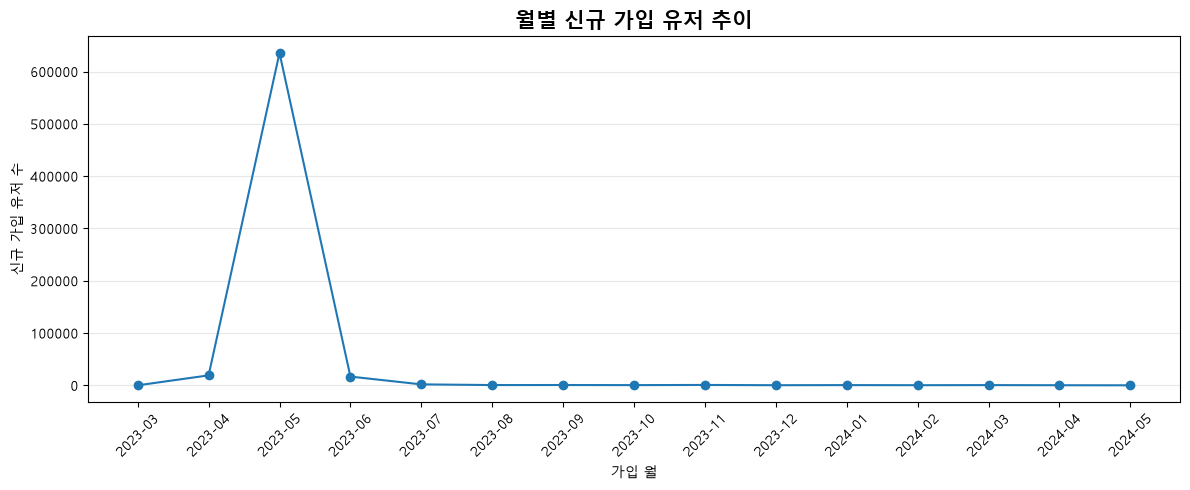

In [222]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_signup['month'],
    monthly_signup['signup_users'],
    marker='o'
)

plt.title('월별 신규 가입 유저 추이', fontsize=15, fontweight='bold')
plt.xlabel('가입 월')
plt.ylabel('신규 가입 유저 수')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [223]:
print(questionset_detail.columns.tolist())
display(questionset_detail.head())

['user_id', 'opening_time', 'question_piece_id_list', 'question_piece_ids']


,user_id,opening_time,question_piece_id_list,question_piece_ids
0,841333,2023-05-17 00:22:16+00:00,"[79931958, 79931960, 79931962, 79931966, 79931...","[79931958, 79931960, 79931962, 79931966, 79931..."
1,845326,2023-05-17 09:54:57+00:00,"[82989582, 82989587, 82989592, 82989596, 82989...","[82989582, 82989587, 82989592, 82989596, 82989..."
2,847375,2023-07-29 16:13:18+00:00,"[206172781, 206172782, 206172783, 206172784, 2...","[206172781, 206172782, 206172783, 206172784, 2..."
3,849438,2023-06-16 15:13:10+00:00,"[200176841, 200176842, 200176843, 200176844, 2...","[200176841, 200176842, 200176843, 200176844, 2..."
4,849451,2023-08-10 09:20:44+00:00,"[206737491, 206737492, 206737493, 206737494, 2...","[206737491, 206737492, 206737493, 206737494, 2..."


In [224]:
# 날짜형 변환
questionset_detail['opening_time'] = pd.to_datetime(
    questionset_detail['opening_time']
)

# 월별 질문 기능 이용 고유 유저 수
monthly_question_users = (
    questionset_detail
    .assign(
        month=questionset_detail['opening_time']
        .dt.to_period('M')
        .astype(str)
    )
    .groupby('month')['user_id']
    .nunique()
    .reset_index(name='question_users')
)

display(monthly_question_users)

C:\Users\kkw53\AppData\Local\Temp\ipykernel_17512\2107044846.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period('M')


,month,question_users
0,2023-04,356
1,2023-05,4909
2,2023-06,1807
3,2023-07,360
4,2023-08,154
5,2023-09,163
6,2023-10,41
7,2023-11,20
8,2023-12,25
9,2024-01,19


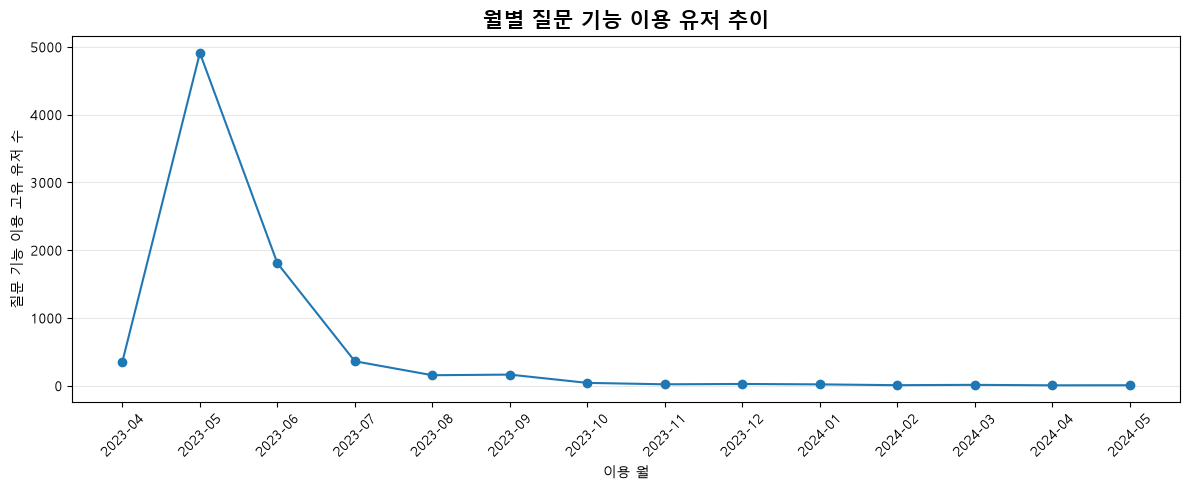

In [225]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_question_users['month'],
    monthly_question_users['question_users'],
    marker='o'
)

plt.title('월별 질문 기능 이용 유저 추이',
          fontsize=15, fontweight='bold')
plt.xlabel('이용 월')
plt.ylabel('질문 기능 이용 고유 유저 수')

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Activation 개선안 준비

## 각 경험의 최소 기준점 탐색
- 초기 행동(질문 완료 경험, 선택받는 경험 등)을 최소 몇 번 정도로 유도해야할지 탐색

In [226]:
print(analysis_b.columns.tolist())

['user_id', 'signup_at', 'group_id', 'school_id', 'questionset_count', 'first_questionset_at', 'last_questionset_at', 'vote_count', 'first_vote_at', 'last_vote_at', 'selected_count', 'read_selected_count', 'first_selected_at', 'payment_count', 'first_payment_at', 'last_payment_at', 'school_signup_order', 'group_signup_order', 'school_unlock_at', 'group_unlock_at', 'service_available_at', 'service_access_status', 'has_questionset', 'signup_month', 'question_start_at_b', 'day1_b', 'initial_experience_b', 'mid_reused_b', 'aha_reached_b', 'day2_b', 'day3_b', 'day2_reused_b', 'day3_reused_b', 'service_access_status_b']


In [227]:
print(selected_all_b.columns.tolist())
display(selected_all_b.head())

['user_id', 'question_start_at_b', 'initial_experience_b', 'selected_count_24h_b', 'selected_24h_b']


,user_id,question_start_at_b,initial_experience_b,selected_count_24h_b,selected_24h_b
0,838023,2023-04-28 03:43:18.503902+00:00,미경험,0,False
1,838466,2023-05-02 22:44:27.267798+00:00,반복 경험,43,True
2,838642,2023-04-28 03:43:18.503902+00:00,단순 경험,4,True
3,839357,2023-04-28 03:43:18.503902+00:00,미경험,0,False
4,839670,2023-04-28 03:43:18.503902+00:00,미경험,12,True


In [228]:
# 분석용 데이터 프레임

activation_combo = (
    analysis_b[
        ['user_id', 'day1_b', 'mid_reused_b']
    ]
    .merge(
        selected_all_b[
            ['user_id', 'selected_count_24h_b']
        ],
        on='user_id',
        how='left'
    )
)

# 혹시 결측이 있다면 0으로 처리
activation_combo['selected_count_24h_b'] = (
    activation_combo['selected_count_24h_b']
    .fillna(0)
    .astype(int)
)

display(activation_combo.head())
print('전체 유저:', len(activation_combo))

,user_id,day1_b,mid_reused_b,selected_count_24h_b
0,838023,0,False,0
1,838466,6,False,43
2,838642,2,False,4
3,839357,0,True,0
4,839670,0,False,12


전체 유저: 5090


In [229]:
# 첫 24시간 선택받은 횟수별로 유저 수와 Week2 재사용 여부 집계
selected_reuse = (
    activation_combo
    .groupby('selected_count_24h_b')
    .agg(
        # 해당 선택 횟수를 경험한 유저 수
        users=('user_id', 'nunique'),

        # 해당 유저 중 Week2에 질문을 재사용한 유저 수
        reused=('mid_reused_b', 'sum'),

        # 해당 선택 횟수별 Week2 질문 재사용률
        reuse_rate=('mid_reused_b', 'mean')
    )
    .reset_index()
)

# 재사용률을 0~1 → % 단위로 변환
selected_reuse['reuse_rate'] = (
    selected_reuse['reuse_rate'] * 100
).round(2)

# 우선 선택 횟수 0~29회 구간 확인
display(selected_reuse.head(30))

,selected_count_24h_b,users,reused,reuse_rate
0,0,424,247,58.25
1,1,105,61,58.1
2,2,97,56,57.73
3,3,99,64,64.65
4,4,88,53,60.23
5,5,111,71,63.96
6,6,108,74,68.52
7,7,87,58,66.67
8,8,108,82,75.93
9,9,92,72,78.26


In [230]:
# 첫 24시간 질문 경험 횟수를 구간으로 분류
activation_combo['question_group'] = pd.cut(
    activation_combo['day1_b'],
    bins=[-1, 0, 2, 5, float('inf')],
    labels=['0회', '1~2회', '3~5회', '6회 이상']
)

# 첫 24시간 선택받은 횟수를 임시 구간으로 분류
activation_combo['selected_group'] = pd.cut(
    activation_combo['selected_count_24h_b'],
    bins=[-1, 2, 7, float('inf')],
    labels=['0~2회', '3~7회', '8회 이상']
)

# 질문 경험 × 선택 경험별 유저 수와 Week2 재사용률 계산
combo_summary = (
    activation_combo
    .groupby(
        ['question_group', 'selected_group'],
        observed=True
    )
    .agg(
        # 각 조합에 해당하는 유저 수
        users=('user_id', 'nunique'),

        # Week2 질문 재사용 유저 수
        reused=('mid_reused_b', 'sum'),

        # Week2 질문 재사용률
        reuse_rate=('mid_reused_b', 'mean')
    )
    .reset_index()
)

# 재사용률을 % 단위로 변환
combo_summary['reuse_rate'] = (
    combo_summary['reuse_rate'] * 100
).round(2)

display(combo_summary)

,question_group,selected_group,users,reused,reuse_rate
0,0회,0~2회,339,224,66.08
1,0회,3~7회,49,23,46.94
2,0회,8회 이상,67,38,56.72
3,1~2회,0~2회,187,66,35.29
4,1~2회,3~7회,180,99,55.0
5,1~2회,8회 이상,420,227,54.05
6,3~5회,0~2회,67,51,76.12
7,3~5회,3~7회,164,116,70.73
8,3~5회,8회 이상,993,661,66.57
9,6회 이상,0~2회,33,23,69.7


In [231]:
import statsmodels.api as sm

# 로지스틱 회귀에 사용할 데이터만 선택
logit_df = activation_combo[
    ['day1_b', 'selected_count_24h_b', 'mid_reused_b']
].copy()

# 종속변수: Week2 질문 재사용 여부를 0/1로 변환
logit_df['mid_reused_b'] = (
    logit_df['mid_reused_b']
    .astype(int)
)

# 독립변수: 첫 24시간 질문 횟수 + 선택받은 횟수
X = logit_df[
    ['day1_b', 'selected_count_24h_b']
]

# 절편(constant) 추가
X = sm.add_constant(X)

# 종속변수: Week2 질문 재사용 여부
y = logit_df['mid_reused_b']

# 로지스틱 회귀 실행
model = sm.Logit(y, X).fit()

# 결과 확인
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.603046
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           mid_reused_b   No. Observations:                 5090
Model:                          Logit   Df Residuals:                     5087
Method:                           MLE   Df Model:                            2
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                 0.02938
Time:                        13:25:40   Log-Likelihood:                -3069.5
converged:                       True   LL-Null:                       -3162.4
Covariance Type:            nonrobust   LLR p-value:                 4.468e-41
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.2844      0.052      5.502      0.000       0.183       0.386

In [232]:
# 선택받은 횟수를 3개 구간으로 분류
logit_group_df = activation_combo[
    ['day1_b', 'selected_count_24h_b', 'mid_reused_b']
].copy()

logit_group_df['selected_group'] = pd.cut(
    logit_group_df['selected_count_24h_b'],
    bins=[-1, 2, 7, float('inf')],
    labels=['0~2회', '3~7회', '8회 이상']
)

# 선택 구간을 더미변수로 변환
# drop_first=True → '0~2회'가 비교 기준이 됨
selected_dummy = pd.get_dummies(
    logit_group_df['selected_group'],
    drop_first=True,
    dtype=int
)

# 질문 횟수와 선택 구간을 독립변수로 구성
X = pd.concat(
    [
        logit_group_df[['day1_b']].reset_index(drop=True),
        selected_dummy.reset_index(drop=True)
    ],
    axis=1
)

# 절편 추가
X = sm.add_constant(X)

# Week2 질문 재사용 여부를 0/1로 변환
y = (
    logit_group_df['mid_reused_b']
    .astype(int)
    .reset_index(drop=True)
)

# 로지스틱 회귀 실행
model_group = sm.Logit(y, X).fit()

# 결과 확인
print(model_group.summary())

Optimization terminated successfully.
         Current function value: 0.604817
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           mid_reused_b   No. Observations:                 5090
Model:                          Logit   Df Residuals:                     5086
Method:                           MLE   Df Model:                            3
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                 0.02653
Time:                        13:25:40   Log-Likelihood:                -3078.5
converged:                       True   LL-Null:                       -3162.4
Covariance Type:            nonrobust   LLR p-value:                 3.821e-36
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2137      0.082      2.606      0.009       0.053       0.374
day1_b         0.0899      0.

### 추가 분석: 초기 질문 반복 경험과 사회적 피드백의 관계

초기 분석에서는 첫 24시간 내 질문 반복 경험이 높은 유저일수록 다른 유저에게 선택받는 경험 역시 강하게 관찰되었다. 이에 **질문 반복 경험과 선택받는 경험 중 어떤 요소가 이후 질문 재사용과 더 직접적으로 연관되는지** 추가 검증하였다.

먼저 선택받은 횟수만 비교했을 때는 선택 경험이 증가함에 따라 Week2 질문 재사용률이 높아지는 구간이 관찰되었다. 그러나 질문 경험 횟수와 선택 경험을 함께 고려한 결과, **첫 24시간 질문 횟수는 Week2 질문 재사용과 유의한 양(+)의 관계를 유지하였다(p<0.001).**

반면 선택 경험을 `0~2회 / 3~7회 / 8회 이상`으로 구분하여 질문 횟수를 함께 고려했을 때, **3~7회(p=0.457)와 8회 이상(p=0.715) 모두 0~2회 집단과 유의한 차이가 확인되지 않았다.**

따라서 현재 데이터에서는 **선택받는 경험의 특정 최소 횟수를 Activation 목표로 설정할 근거는 부족하며, 첫 24시간 내 질문을 반복적으로 경험하도록 만드는 것이 이후 질문 재사용과 더 일관되게 연결되는 핵심 행동으로 판단된다.**

다만 사회적 피드백이 중요하지 않다는 의미는 아니다. **선택 경험은 초기 활성화 수준과 강하게 함께 나타나는 특징**이 확인되었으므로, 초기 사회적 상호작용의 역할 자체는 별도의 관점에서 추가 검증할 필요가 있다.

> 따라서, 첫 24시간 내 질문 반복 경험을 만드는 것을 우선적인 Activation 목표로 설정하고, 사회적 피드백은 특정 횟수를 KPI로 설정하기보다 초기 질문 참여를 강화하는 경험 요소로 활용할 가능성을 검토할 필요가 있다.
>

## “선택을 많이 받는 것”이 아니라 “질문 경험 직후 빠르게 사회적 피드백을 받는 것”이 중요할 가능성

In [233]:
# 선택받은 시점을 계산할 수 있는 questionrecord 원본 구조 확인
print(questionrecord_detail.columns.tolist())

# 실제 데이터 형태 확인
display(questionrecord_detail.head())

['user_id', 'chosen_user_id', 'question_piece_id', 'answer_status', 'answer_updated_at', 'created_at']


,user_id,chosen_user_id,question_piece_id,answer_status,answer_updated_at,created_at
0,859241,851144,1654103,N,2023-04-30 13:36:57+00:00,2023-04-30 13:36:57+00:00
1,850229,850031,1746533,N,2023-04-30 15:33:03+00:00,2023-04-30 15:33:03+00:00
2,850736,850031,1959508,N,2023-05-01 07:22:18+00:00,2023-05-01 07:22:18+00:00
3,857101,858253,2130014,N,2023-05-01 11:59:48+00:00,2023-05-01 11:59:48+00:00
4,850736,850031,2157601,N,2023-05-01 14:31:02+00:00,2023-05-01 14:31:02+00:00


In [234]:
# 선택받은 유저와 선택 시점만 추출
selected_timing = questionrecord_detail[
    ['chosen_user_id', 'created_at']
].copy()

# chosen_user_id를 분석 기준인 user_id로 변경
selected_timing = selected_timing.rename(
    columns={'chosen_user_id': 'user_id'}
)

# 선택 시점을 datetime 형식으로 변환
selected_timing['created_at'] = pd.to_datetime(
    selected_timing['created_at'],
    utc=True
)

# 유저별 첫 questionset 경험 시점 계산
first_question_time = (
    questionset_detail
    .groupby('user_id', as_index=False)['opening_time']
    .min()
    .rename(columns={'opening_time': 'first_question_at'})
)

# 첫 질문 시점과 선택 기록 연결
after_first_question = first_question_time.merge(
    selected_timing,
    on='user_id',
    how='left'
)

# 첫 질문 이후 발생한 선택 기록 중 가장 빠른 시점 계산
first_selected_after = (
    after_first_question[
        after_first_question['created_at']
        >= after_first_question['first_question_at']
    ]
    .groupby('user_id', as_index=False)['created_at']
    .min()
    .rename(columns={'created_at': 'first_selected_at'})
)

# 전체 질문 경험 유저를 기준으로 다시 연결
# → 첫 질문 이후 선택받지 않은 유저도 유지
first_feedback = first_question_time.merge(
    first_selected_after,
    on='user_id',
    how='left'
)

# 첫 질문 → 첫 선택까지 걸린 시간(시간 단위)
first_feedback['hours_to_first_selected'] = (
    first_feedback['first_selected_at']
    - first_feedback['first_question_at']
).dt.total_seconds() / 3600

# 결과 확인
print('첫 질문 경험 유저:', len(first_feedback))
print(
    '첫 질문 이후 선택 경험 있음:',
    first_feedback['first_selected_at'].notna().sum()
)
print(
    '첫 질문 이후 선택 경험 없음:',
    first_feedback['first_selected_at'].isna().sum()
)

display(first_feedback.head())

첫 질문 경험 유저: 4972
첫 질문 이후 선택 경험 있음: 4924
첫 질문 이후 선택 경험 없음: 48


,user_id,first_question_at,first_selected_at,hours_to_first_selected
0,838023,2023-04-29 10:02:26+00:00,2023-04-29 14:51:05+00:00,4.810833
1,838466,2023-05-02 22:41:59+00:00,2023-05-02 22:56:07+00:00,0.235556
2,838642,2023-04-28 14:17:23+00:00,2023-04-28 15:33:50+00:00,1.274167
3,839357,2023-04-29 16:50:47+00:00,2023-04-29 17:04:48+00:00,0.233611
4,840293,2023-05-03 02:23:57+00:00,2023-05-03 02:30:58+00:00,0.116944


In [235]:
# 첫 질문 이후 선택받은 4,924명만 추출
feedback_received = first_feedback[
    first_feedback['hours_to_first_selected'].notna()
].copy()

# 첫 질문 → 첫 선택까지 걸린 시간의 분포 확인
feedback_time_summary = (
    feedback_received['hours_to_first_selected']
    .describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

display(feedback_time_summary)

count    4924.000000
mean        7.561977
std       150.239038
min         0.000000
10%         0.040083
25%         0.138333
50%         0.488889
75%         1.414028
90%         5.988417
95%        11.406014
max      7382.143889
Name: hours_to_first_selected, dtype: float64

In [236]:
# 유저별 questionset 발생 시점만 추출
question_times = questionset_detail[
    ['user_id', 'opening_time']
].copy()

# 첫 선택 시점을 questionset 기록과 연결
after_feedback = (
    first_feedback[
        first_feedback['first_selected_at'].notna()
    ][['user_id', 'first_selected_at', 'hours_to_first_selected']]
    .merge(
        question_times,
        on='user_id',
        how='left'
    )
)

# 첫 선택 '이후'에 발생한 questionset인지 확인
after_feedback['question_after_feedback'] = (
    after_feedback['opening_time']
    > after_feedback['first_selected_at']
)

# 유저별로 첫 선택 이후 questionset을 한 번이라도 이용했는지 계산
feedback_repeat = (
    after_feedback
    .groupby('user_id', as_index=False)
    .agg(
        hours_to_first_selected=('hours_to_first_selected', 'first'),
        repeated_after_feedback=('question_after_feedback', 'max')
    )
)

display(feedback_repeat.head())
print('분석 유저:', len(feedback_repeat))

,user_id,hours_to_first_selected,repeated_after_feedback
0,838023,4.810833,True
1,838466,0.235556,True
2,838642,1.274167,False
3,839357,0.233611,True
4,840293,0.116944,True


분석 유저: 4924


In [237]:
# 첫 선택 이후 questionset까지 걸린 시간 계산
after_feedback['hours_after_feedback'] = (
    after_feedback['opening_time']
    - after_feedback['first_selected_at']
).dt.total_seconds() / 3600

# 첫 선택 이후 24시간 안에 발생한 questionset인지 확인
after_feedback['repeat_within_24h'] = (
    (after_feedback['hours_after_feedback'] > 0)
    & (after_feedback['hours_after_feedback'] <= 24)
)

# 유저별 첫 선택 후 24시간 내 추가 질문 경험 여부 계산
feedback_repeat_24h = (
    after_feedback
    .groupby('user_id', as_index=False)
    .agg(
        # 첫 질문 → 첫 선택까지 걸린 시간
        hours_to_first_selected=('hours_to_first_selected', 'first'),

        # 첫 선택 후 24시간 내 questionset을 한 번이라도 다시 이용했는지
        repeated_24h=('repeat_within_24h', 'max')
    )
)

print('분석 유저:', len(feedback_repeat_24h))
display(feedback_repeat_24h.head())

분석 유저: 4924


,user_id,hours_to_first_selected,repeated_24h
0,838023,4.810833,True
1,838466,0.235556,True
2,838642,1.274167,False
3,839357,0.233611,True
4,840293,0.116944,True


In [238]:
# 첫 질문 → 첫 선택까지 걸린 시간을 구간으로 분류
feedback_repeat_24h['feedback_speed'] = pd.cut(
    feedback_repeat_24h['hours_to_first_selected'],
    bins=[-1, 0.5, 1.5, 6, float('inf')],
    labels=[
        '30분 이내',
        '30분~1.5시간',
        '1.5~6시간',
        '6시간 초과'
    ]
)

# 피드백 속도별 유저 수와 선택 이후 24시간 내 질문 재이용률 계산
feedback_speed_summary = (
    feedback_repeat_24h
    .groupby('feedback_speed', observed=True)
    .agg(
        # 각 피드백 속도 구간의 유저 수
        users=('user_id', 'nunique'),

        # 선택 이후 24시간 내 질문을 다시 이용한 유저 수
        repeated_users=('repeated_24h', 'sum'),

        # 선택 이후 24시간 내 질문 재이용률
        repeat_rate=('repeated_24h', 'mean')
    )
    .reset_index()
)

# 재이용률을 %로 변환
feedback_speed_summary['repeat_rate'] = (
    feedback_speed_summary['repeat_rate'] * 100
).round(2)

display(feedback_speed_summary)

,feedback_speed,users,repeated_users,repeat_rate
0,30분 이내,2485,2423,97.51
1,30분~1.5시간,1252,1147,91.61
2,1.5~6시간,694,584,84.15
3,6시간 초과,493,337,68.36


In [239]:
from scipy.stats import chi2_contingency

# 피드백 속도 × 이후 24시간 질문 재이용 여부 교차표 생성
contingency_table = pd.crosstab(
    feedback_repeat_24h['feedback_speed'],
    feedback_repeat_24h['repeated_24h']
)

# 카이제곱 독립성 검정
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# 결과 확인
display(contingency_table)

print(f'Chi-square: {chi2:.3f}')
print(f'p-value: {p_value:.6f}')
print(f'dof: {dof}')

repeated_24h,False,True
feedback_speed,,
30분 이내,62,2423
30분~1.5시간,105,1147
1.5~6시간,110,584
6시간 초과,156,337


Chi-square: 487.190
p-value: 0.000000
dof: 3


### 확인 결과

- `users` - 첫 questionset을 경험한 뒤 **처음 선택받은  전체 유저**
- `repeated_users` - 처음 선택받은 시점 이후 24시간 안에 questionset을 다시 이용한 유저 수

**분석 결과**, 첫 선택받기까지 걸리는 시간이 길어질수록 이후 24시간 내 질문 재이용률이 `97.5% → 91.6% → 84.2% → 68.4%`로 단계적으로 감소하는 패턴이 관찰되었다.

> “첫 질문 이후 처음 선택받는 시점이 빠른 집단일수록, 그 선택 경험 이후 24시간 내 질문을 다시 이용한 유저의 비율이 높았다.”
> 

따라서 현재 데이터에서는 **선택받는 횟수 자체보다 첫 질문 이후 사회적 피드백을 빠르게 경험하는 것이 초기 질문 반복과 더 밀접하게 연관되어 있을 가능성**이 있다.

다만 유저의 기존 활동성, 친구 수 및 친구의 활동성 등 다른 요인의 영향을 받을 수 있으므로 **빠른 피드백이 질문 반복을 유발한다고 해석할 수는 없다.**

In [240]:
# 그룹별 가장 빠른 가입일을 그룹의 '최초 관측 시점'으로 계산
group_first_seen = (
    df.dropna(subset=['group_id', 'signup_at'])
      .groupby('group_id', as_index=False)
      .agg(
          group_first_seen=('signup_at', 'min'),
          user_count=('user_id', 'nunique')
      )
)

# 월 단위로 변환
group_first_seen['first_seen_month'] = (
    group_first_seen['group_first_seen']
    .dt.to_period('M')
    .astype(str)
)

# 월별 처음 관측된 그룹 수
group_monthly = (
    group_first_seen
    .groupby('first_seen_month')
    .agg(
        groups=('group_id', 'nunique'),
        users=('user_count', 'sum')
    )
    .reset_index()
)

display(group_monthly)

C:\Users\kkw53\AppData\Local\Temp\ipykernel_17512\3969334815.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period('M')


,first_seen_month,groups,users
0,2023-03,19,288
1,2023-04,5437,52130
2,2023-05,73520,621058
3,2023-06,1288,2773
4,2023-07,158,202
5,2023-08,61,71
6,2023-09,115,209
7,2023-10,65,77
8,2023-11,77,81
9,2023-12,25,26


In [241]:
df.columns.tolist()

['user_id',
 'signup_at',
 'group_id',
 'school_id',
 'questionset_count',
 'first_questionset_at',
 'last_questionset_at',
 'vote_count',
 'first_vote_at',
 'last_vote_at',
 'selected_count',
 'read_selected_count',
 'first_selected_at',
 'payment_count',
 'first_payment_at',
 'last_payment_at',
 'school_signup_order',
 'group_signup_order',
 'school_unlock_at',
 'group_unlock_at',
 'service_available_at',
 'service_access_status',
 'has_questionset',
 'signup_month']

In [242]:
# 가입 연도 생성
df['signup_year'] = df['signup_at'].dt.year

# 그룹별 가입 연도 수 확인
group_year_mix = (
    df.groupby('group_id')
      .agg(
          user_count=('user_id', 'nunique'),
          signup_year_count=('signup_year', 'nunique'),
          first_signup=('signup_at', 'min'),
          last_signup=('signup_at', 'max')
      )
      .reset_index()
)

# 2023년과 2024년 가입자가 함께 존재하는 그룹
mixed_groups = group_year_mix[
    group_year_mix['signup_year_count'] >= 2
]

print('전체 그룹 수:', len(group_year_mix))
print('가입연도가 섞인 그룹 수:', len(mixed_groups))
print('비율:', round(len(mixed_groups) / len(group_year_mix) * 100, 2), '%')

전체 그룹 수: 80912
가입연도가 섞인 그룹 수: 1136
비율: 1.4 %


In [243]:
# 2024년 가입자가 속한 그룹
groups_2024 = df.loc[
    df['signup_year'] == 2024,
    'group_id'
].dropna().unique()

# 해당 그룹에 속한 전체 유저
df_2024_groups = df[
    df['group_id'].isin(groups_2024)
]

# 그룹별 2023 / 2024 가입자 수
group_2024_detail = (
    df_2024_groups
    .groupby('group_id')
    .agg(
        total_users=('user_id', 'nunique'),
        users_2023=('signup_year', lambda x: (x == 2023).sum()),
        users_2024=('signup_year', lambda x: (x == 2024).sum())
    )
    .reset_index()
)

# 2024 가입자와 2023 가입자가 함께 있는지
group_2024_detail['has_2023_users'] = (
    group_2024_detail['users_2023'] > 0
)

print('2024년 가입자가 존재하는 그룹:', len(group_2024_detail))
print(
    '그중 2023년 가입자도 존재:',
    group_2024_detail['has_2023_users'].sum()
)
print(
    '비율:',
    round(group_2024_detail['has_2023_users'].mean() * 100, 2),
    '%'
)

2024년 가입자가 존재하는 그룹: 1283
그중 2023년 가입자도 존재: 1136
비율: 88.54 %


In [244]:
# 2024년 3월 가입자
march_2024_users = df[
    df['signup_at'].dt.to_period('M') == '2024-03'
]

# 이들이 현재 속한 그룹
march_groups = march_2024_users['group_id'].dropna().unique()

# 해당 그룹의 모든 유저
march_group_users = df[df['group_id'].isin(march_groups)]

march_group_detail = (
    march_group_users
    .groupby('group_id')
    .agg(
        total_users=('user_id', 'nunique'),
        users_2023=('signup_year', lambda x: (x == 2023).sum()),
        users_2024=('signup_year', lambda x: (x == 2024).sum())
    )
    .reset_index()
)

march_group_detail['has_2023_users'] = (
    march_group_detail['users_2023'] > 0
)

print('2024년 3월 신규가입자 수:', march_2024_users['user_id'].nunique())
print('이들이 속한 그룹 수:', len(march_group_detail))
print('2023 가입자가 함께 있는 그룹:',
      march_group_detail['has_2023_users'].sum())

print(
    '비율:',
    round(march_group_detail['has_2023_users'].mean() * 100, 2),
    '%'
)

2024년 3월 신규가입자 수: 446
이들이 속한 그룹 수: 398
2023 가입자가 함께 있는 그룹: 358
비율: 89.95 %


C:\Users\kkw53\AppData\Local\Temp\ipykernel_17512\2445128571.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['signup_at'].dt.to_period('M') == '2024-03'


# <>

In [245]:
df_b.columns.tolist()

['user_id',
 'signup_at',
 'group_id',
 'school_id',
 'questionset_count',
 'first_questionset_at',
 'last_questionset_at',
 'vote_count',
 'first_vote_at',
 'last_vote_at',
 'selected_count',
 'read_selected_count',
 'first_selected_at',
 'payment_count',
 'first_payment_at',
 'last_payment_at',
 'school_signup_order',
 'group_signup_order',
 'school_unlock_at',
 'group_unlock_at',
 'service_available_at',
 'service_access_status',
 'has_questionset',
 'signup_month',
 'question_start_at_b',
 'service_access_status_b']

In [246]:
df_b['question_start_month_b'] = (
    df_b['question_start_at_b'].dt.to_period('M')
)

C:\Users\kkw53\AppData\Local\Temp\ipykernel_17512\1877029315.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_b['question_start_at_b'].dt.to_period('M')


In [247]:
[name for name in globals() if any(
    keyword in name.lower()
    for keyword in ['aha', 'day1', '24h', 'early', 'question']
)]

['questionset_rate',
 'wait_questionset_rate',
 'monthly_questionset',
 'questionset_df',
 'question_school_ids',
 'question_school_users',
 'question_school_info',
 'question_school_df',
 'school_question_period',
 'hackle_question_sql',
 'hackle_question_users',
 'hackle_question_unique',
 'questionrecord_period_sql',
 'questionrecord_period',
 'questionset_period_sql',
 'questionset_period',
 'wait_question_summary',
 'df_aha',
 'questionset_sql',
 'questionset',
 'question_daily',
 'question_3day',
 'day1_reuse',
 'day1_day3_reuse',
 'questionrecord_sql',
 'questionrecord',
 'day1_mid_reuse',
 'aha_group',
 'non_aha_group',
 'access_aha',
 'access_aha_summary',
 'first_question',
 'question_with_school',
 'school_question_end',
 'no_question_91',
 'questionrecord_detail_sql',
 'questionrecord_detail',
 'questionset_detail_sql',
 'questionset_detail',
 'questionset_exploded',
 'first_questionset',
 'first_questionset_exploded',
 'early_selected',
 'selected_24h_users',
 'selected_24

In [248]:
for name in ['question_daily_b', 'day1_b', 'df_aha_b']:
    obj = globals()[name]
    print(f'\n{name}: {obj.shape}')
    print(obj.columns.tolist())


question_daily_b: (158384, 5)
['user_id', 'opening_time', 'question_start_at_b', 'hours_after_start_b', 'day_group_b']

day1_b: (4635, 2)
['user_id', 'day1_b']

df_aha_b: (5090, 33)
['user_id', 'signup_at', 'group_id', 'school_id', 'questionset_count', 'first_questionset_at', 'last_questionset_at', 'vote_count', 'first_vote_at', 'last_vote_at', 'selected_count', 'read_selected_count', 'first_selected_at', 'payment_count', 'first_payment_at', 'last_payment_at', 'school_signup_order', 'group_signup_order', 'school_unlock_at', 'group_unlock_at', 'service_available_at', 'service_access_status', 'has_questionset', 'signup_month', 'question_start_at_b', 'day1_b', 'initial_experience_b', 'mid_reused_b', 'aha_reached_b', 'day2_b', 'day3_b', 'day2_reused_b', 'day3_reused_b']


In [249]:
monthly_activation_b = (
    df_aha_b
    .dropna(subset=['question_start_at_b'])
    .assign(
        start_month=lambda x: x['question_start_at_b'].dt.to_period('M')
    )
    .groupby('start_month')
    .agg(
        users=('user_id', 'nunique'),
        aha_users=('aha_reached_b', 'sum'),
        avg_day1_questions=('day1_b', 'mean')
    )
    .assign(
        activation_rate=lambda x: (
            x['aha_users'] / x['users'] * 100
        ).round(2)
    )
    .reset_index()
)

monthly_activation_b

C:\Users\kkw53\AppData\Local\Temp\ipykernel_17512\1033648953.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  start_month=lambda x: x['question_start_at_b'].dt.to_period('M')


,start_month,users,aha_users,avg_day1_questions,activation_rate
0,2023-04,366,311,7.374317,84.97
1,2023-05,4669,3522,6.294281,75.43
2,2023-06,35,14,2.942857,40.00
3,2023-07,4,1,1.750000,25.00
4,2023-08,2,0,0.500000,0.00
5,2023-09,3,0,0.666667,0.00
6,2023-10,1,0,0.000000,0.00
7,2023-11,1,0,1.000000,0.00
8,2023-12,2,0,0.500000,0.00
9,2024-01,2,0,0.500000,0.00


In [250]:
questionset.columns.tolist()

['user_id', 'opening_time']

In [251]:
monthly_question_usage = (
    questionset
    .assign(
        usage_month=lambda x: x['opening_time'].dt.to_period('M')
    )
    .groupby('usage_month')
    .agg(
        questionset_count=('user_id', 'size'),
        active_users=('user_id', 'nunique')
    )
    .assign(
        questionsets_per_user=lambda x: (
            x['questionset_count'] / x['active_users']
        ).round(2)
    )
    .reset_index()
)

monthly_question_usage


C:\Users\kkw53\AppData\Local\Temp\ipykernel_17512\3139796884.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  usage_month=lambda x: x['opening_time'].dt.to_period('M')


,usage_month,questionset_count,active_users,questionsets_per_user
0,2023-04,4164,356,11.7
1,2023-05,143158,4909,29.16
2,2023-06,9579,1807,5.3
3,2023-07,720,360,2.0
4,2023-08,273,154,1.77
5,2023-09,240,163,1.47
6,2023-10,48,41,1.17
7,2023-11,36,20,1.8
8,2023-12,75,25,3.0
9,2024-01,46,19,2.42


In [252]:
# 1. 유저별 질문 이용 월 (같은 달 중복 제거)
user_month = (
    questionset[['user_id', 'opening_time']]
    .dropna(subset=['opening_time'])
    .assign(
        usage_month=lambda x: x['opening_time'].dt.to_period('M')
    )
    [['user_id', 'usage_month']]
    .drop_duplicates()
)

# 2. 유저별 최초 질문 이용 월
first_month = (
    user_month.groupby('user_id')['usage_month']
    .min()
    .rename('cohort_month')
    .reset_index()
)

# 3. 최초 이용 월을 각 이용 기록에 연결
cohort = user_month.merge(first_month, on='user_id')

# 4. 최초 이용 후 경과 개월 수
cohort['month_offset'] = (
    (cohort['usage_month'].dt.year - cohort['cohort_month'].dt.year) * 12
    + cohort['usage_month'].dt.month - cohort['cohort_month'].dt.month
)

# 5. 코호트별 월간 질문 재사용률
cohort_counts = (
    cohort.groupby(['cohort_month', 'month_offset'])['user_id']
    .nunique()
    .unstack()
)

question_first_retention = (
    cohort_counts
    .div(cohort_counts[0], axis=0)
    .mul(100)
    .round(2)
)

question_first_retention

C:\Users\kkw53\AppData\Local\Temp\ipykernel_17512\998190119.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  usage_month=lambda x: x['opening_time'].dt.to_period('M')


month_offset,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2023-04,100.0,95.79,22.47,10.67,1.69,3.37,NaN,0.84,0.28,0.28,0.28,0.28,NaN
2023-05,100.0,37.02,6.85,3.15,3.17,0.85,0.35,0.48,0.37,0.13,0.22,0.11,0.13
2023-06,100.0,11.11,5.56,8.33,2.78,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-07,100.0,20.00,20.00,20.00,NaN,20.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [253]:
cohort_counts

month_offset,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2023-04,356.0,341.0,80.0,38.0,6.0,12.0,NaN,3.0,1.0,1.0,1.0,1.0,NaN
2023-05,4568.0,1691.0,313.0,144.0,145.0,39.0,16.0,22.0,17.0,6.0,10.0,5.0,6.0
2023-06,36.0,4.0,2.0,3.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-07,5.0,1.0,1.0,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-08,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [254]:
monthly_first_question_b = (
    df_aha_b
    .dropna(subset=['question_start_at_b'])
    .assign(
        start_month=lambda x: x['question_start_at_b'].dt.to_period('M'),
        first_question_user=lambda x: x['day1_b'].fillna(0) >= 1
    )
    .groupby('start_month')
    .agg(
        users=('user_id', 'nunique'),
        first_question_users=('first_question_user', 'sum'),
        avg_day1_questions=('day1_b', 'mean')
    )
    .assign(
        first_question_rate=lambda x: (
            x['first_question_users'] / x['users'] * 100
        ).round(2)
    )
    .reset_index()
)

monthly_first_question_b

C:\Users\kkw53\AppData\Local\Temp\ipykernel_17512\2158292141.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  start_month=lambda x: x['question_start_at_b'].dt.to_period('M'),


,start_month,users,first_question_users,avg_day1_questions,first_question_rate
0,2023-04,366,349,7.374317,95.36
1,2023-05,4669,4243,6.294281,90.88
2,2023-06,35,32,2.942857,91.43
3,2023-07,4,4,1.750000,100.00
4,2023-08,2,1,0.500000,50.00
5,2023-09,3,2,0.666667,66.67
6,2023-10,1,0,0.000000,0.00
7,2023-11,1,1,1.000000,100.00
8,2023-12,2,1,0.500000,50.00
9,2024-01,2,1,0.500000,50.00
